# Developed CNN Architecture (No Improving CNN Architecture + Bicubic Grayscale PNG + 5-Fold))

### 1.1 Libraries

In [4]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

CPU times: user 1.71 ms, sys: 0 ns, total: 1.71 ms
Wall time: 1.73 ms


In [5]:
!nvidia-smi

Mon Jun  9 11:37:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1D:00.0 Off |                  Off |
| 30%   33C    P8             22W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2. Sound and Source

In [7]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [8]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [9]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")

CPU times: user 28 µs, sys: 0 ns, total: 28 µs
Wall time: 60.3 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [10]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 412 µs, sys: 155 µs, total: 567 µs
Wall time: 478 µs


### 2.2. Image generator (Training, validation, and testing)

In [11]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 17 µs, sys: 7 µs, total: 24 µs
Wall time: 35 µs


### 2.3. Creation of the Model Based on the Architecture
Descongelamos 5 capas de MobileNet para esta versión, pero para más adelante, version optimizada,podemos desconger 10 capas.

In [12]:
%%time

def new_model(num_classes):
    # Use MobileNet architecture with imagenet weights by transfer Learning 
    base_model = MobileNet(weights='imagenet',
                           include_top=False,
                           input_shape=(img_width, img_height, 3))

    # Freeze the convolutional layers of the pretrained model
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze the last 10 layers of the MobileNet base model
    for layer in base_model.layers[-5:]:
        layer.trainable = True

    # Malware classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x) # Probar con 0.5 si no mejora los resultados
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)  # Nueva capa adicional
    x = Dropout(0.3)(x) # Nueva capa adicional
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    # Combining the pretrained model with the malware classification layer
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with an optimizer and learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    
    # Calculate the total # parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    # Print request info paramers
    print("Total params: {}".format(total_params))
    print("Trainable params: {}".format(trainable_params))
    print("Non-trainable params: {}".format(non_trainable_params))

    
    return model

CPU times: user 31 µs, sys: 0 ns, total: 31 µs
Wall time: 37 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [13]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 3 µs, sys: 2 µs, total: 5 µs
Wall time: 6.91 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [14]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 0 ns, sys: 6 µs, total: 6 µs
Wall time: 9.3 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families

### 3.1. Settings (Configurar)

In [15]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Model names to use for save'
nombre_modelo = 'MobileNet_tf_1500'
save_model = source + 'layer_contribution/MobileNet_tf_optimized/'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()


CPU times: user 18.4 ms, sys: 9.89 ms, total: 28.3 ms
Wall time: 1.22 s


In [16]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []
    
    # Variables to track the best fold
    best_val_accuracy = 0
    best_fold_idx = 0

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Try to load pre-trained model or stop the execution
        model_path = os.path.join(save_model, f'{name_save_model}_best.h5')
        print(f'model_path: {model_path}')
        if os.path.exists(model_path):
            print(f"Loading pre-trained model from {model_path}")
            try:
                model = load_model(model_path, compile=False)
                print("Model loaded successfully.")
                #print("Model loaded successfully. Summary:")
                #model.summary()
                
                # Recompile the model with the same optimizer settings
                model.compile(optimizer=Adam(learning_rate=learning_rate),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
                
                # Verificar si las capas están correctamente configuradas
                print("\nTrainable layers after loading:")
                for layer in model.layers[-5:]:
                    layer.trainable = True
                    print(f"{layer.name} - Trainable: {layer.trainable}")
                
            except Exception as e:
                print(f"Error loading model: {e}. Stoping the execution...")
                break
        else:
            print("No pre-trained model found. Stoping execution...")
            break

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)

        # Training the pre-trained model
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            callbacks=[early_stopping],
        )

        sound()

        # Check if this fold is the best one
        current_val_accuracy = max(history_model.history['val_accuracy'])
        if current_val_accuracy > best_val_accuracy:
            best_val_accuracy = current_val_accuracy
            best_fold_idx = fold_idx + 1

        ##### SAVE HISTORY #####
        history_filename = f'c6_base_pickle_plus_50_epochs_{name_save_model}_{fold_idx + 1}.pkl'
        with open(os.path.join(save_model, history_filename), 'wb') as file:
            pickle.dump(history_model.history, file)
        print(f"History for fold {fold_idx + 1} saved as {history_filename}")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

    print(f"\nBest fold was {best_fold_idx} with val_accuracy: {best_val_accuracy:.4f}")

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("\nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all

CPU times: user 4 µs, sys: 2 µs, total: 6 µs
Wall time: 9.06 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: MobileNet_tf_15002
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 22s 195ms/step - loss: 0.0782 - accuracy: 1.0000 - val_loss: 0.0599 - val_accuracy: 1.0000
Epoch 2/50
65/65 [==============================] - 10s 157ms/step - loss: 0.0515 - accuracy: 1.0000 - v

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15002_1.pkl
66/66 [==============================] - 10s 132ms/step - loss: 6.9525e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0006952511030249298
15/15 [==============================] - 3s 131ms/step - loss: 7.6594e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0007659418042749166
15/15 [==============================] - 2s 138ms/step - loss: 6.9674e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0006967443623580039
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg    

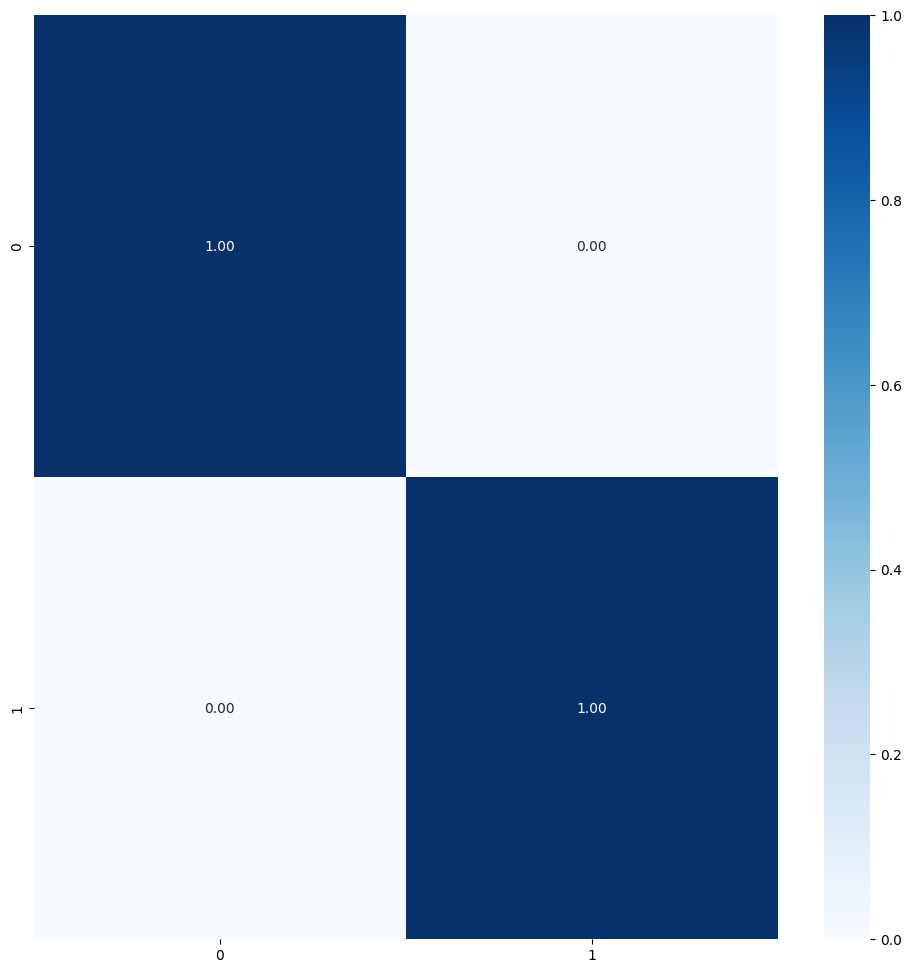


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 26s 220ms/step - loss: 0.0763 - accuracy: 1.0000 - val_loss: 0.0560 - val_accuracy: 1.0000
Epoch 2/50
65/65 [==============================] - 12s 157ms/step - loss: 0.0518 - accuracy: 0.9985 - val_loss: 0.0444 - val_accuracy: 1.0000
Epoch 3/50
65/65 [==============================] - 11s 173ms/step - loss: 0.0419 - accuracy: 1.0000 - val_loss: 0.0392 - val_accuracy: 1.0000
Epoch 4/50
65/65 [==============================] - 11s 168ms/step - loss: 0.0376 - accuracy: 1.0000 - val_loss:

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15002_2.pkl
66/66 [==============================] - 9s 114ms/step - loss: 0.0013 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0013097742339596152
15/15 [==============================] - 2s 110ms/step - loss: 0.0013 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.001321329502388835
15/15 [==============================] - 2s 114ms/step - loss: 0.0013 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0013111525913700461
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1

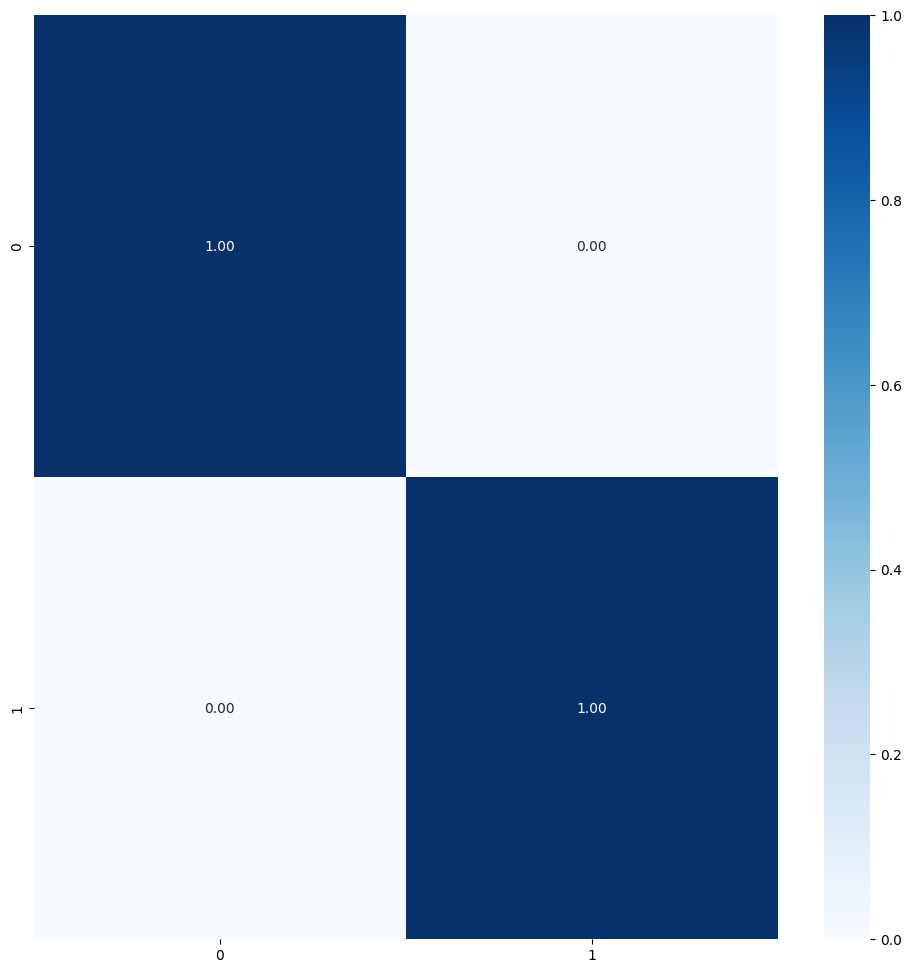


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 20s 179ms/step - loss: 0.0761 - accuracy: 1.0000 - val_loss: 0.0553 - val_accuracy: 1.0000
Epoch 2/50
65/65 [==============================] - 10s 151ms/step - loss: 0.0430 - accuracy: 1.0000 - val_loss: 0.0325 - val_accuracy: 1.0000
Epoch 3/50
65/65 [==============================] - 10s 157ms/step - loss: 0.0256 - accuracy: 1.0000 - val_loss: 0.0199 - val_accuracy: 1.0000
Epoch 4/50
65/65 [==============================] - 11s 153ms/step - loss: 0.0177 - accuracy: 0.9995 - val_loss:

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15002_3.pkl
66/66 [==============================] - 9s 125ms/step - loss: 5.7224e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0005722434143535793
15/15 [==============================] - 3s 123ms/step - loss: 5.7620e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0005762038053944707
15/15 [==============================] - 3s 127ms/step - loss: 5.8209e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0005820916267111897
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg     

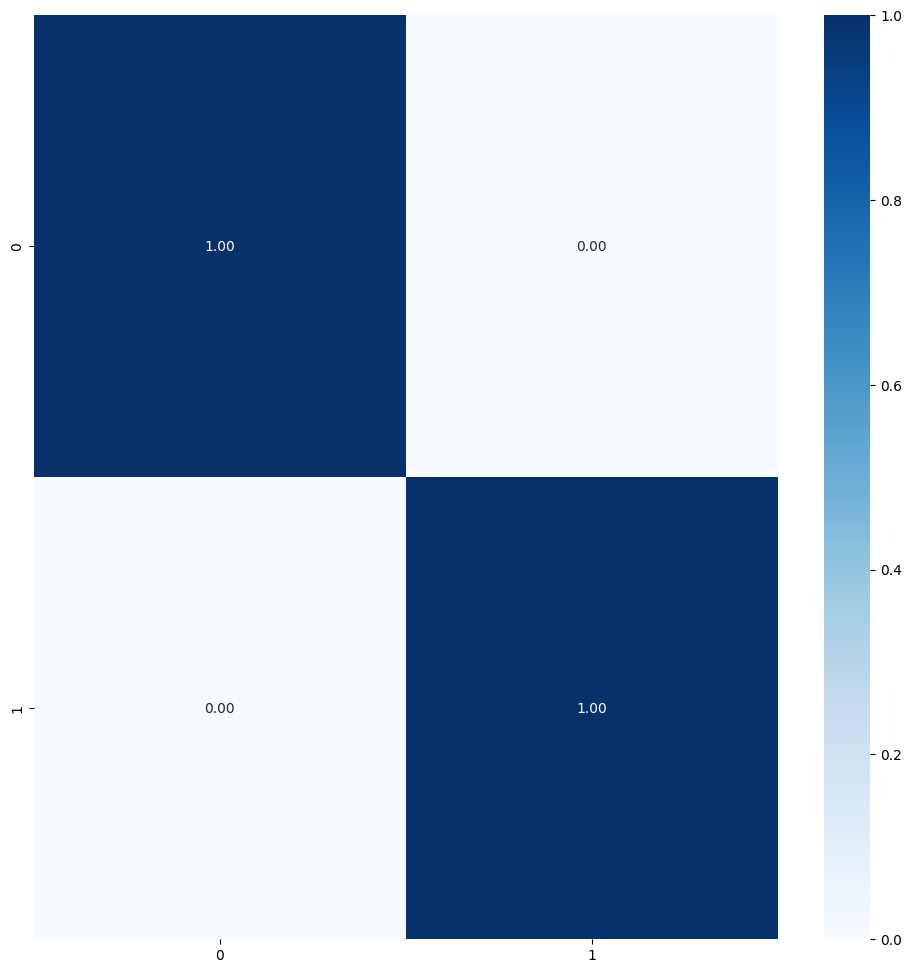


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 22s 202ms/step - loss: 0.0762 - accuracy: 1.0000 - val_loss: 0.0562 - val_accuracy: 1.0000
Epoch 2/50
65/65 [==============================] - 11s 161ms/step - loss: 0.0468 - accuracy: 1.0000 - val_loss: 0.0388 - val_accuracy: 1.0000
Epoch 3/50
65/65 [==============================] - 10s 155ms/step - loss: 0.0332 - accuracy: 1.0000 - val_loss: 0.0278 - val_accuracy: 1.0000
Epoch 4/50
65/65 [==============================] - 9s 139ms/step - loss: 0.0248 - accuracy: 0.9995 - val_loss: 

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15002_4.pkl
66/66 [==============================] - 9s 122ms/step - loss: 3.2663e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00032663089223206043
15/15 [==============================] - 2s 128ms/step - loss: 3.3477e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.000334773154463619
15/15 [==============================] - 2s 117ms/step - loss: 3.2860e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.00032859802013263106
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg    

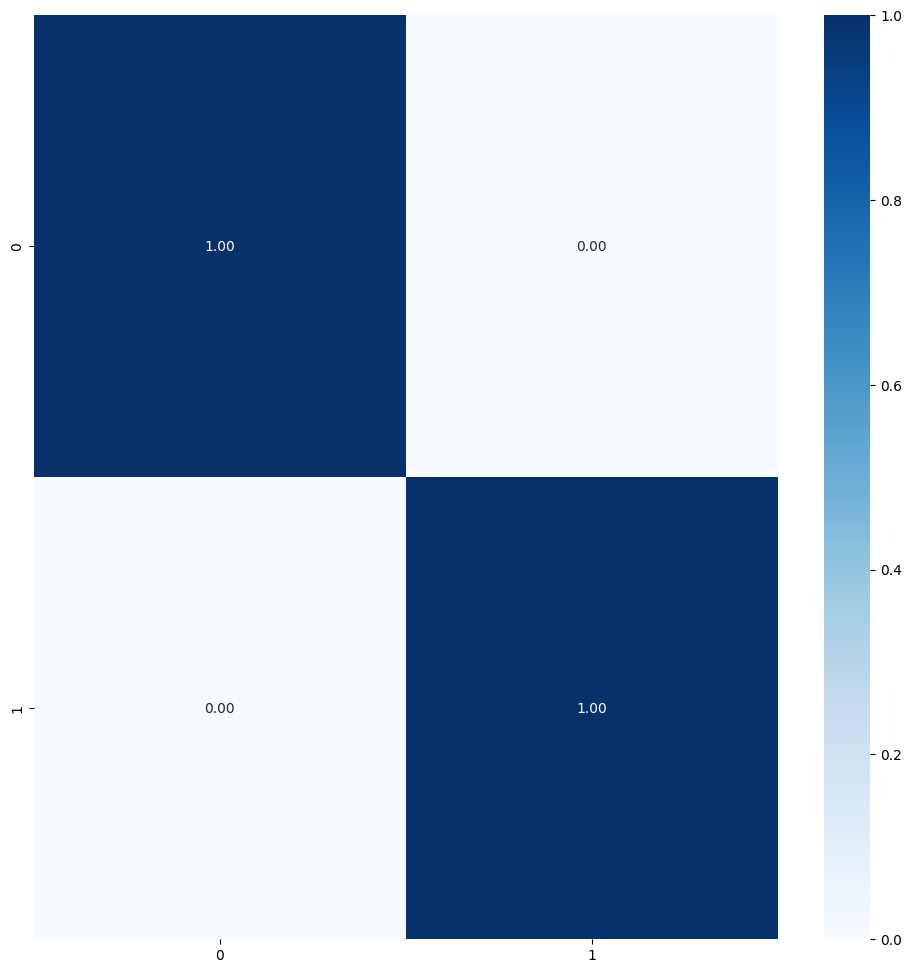


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15002_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
65/65 [==============================] - 27s 215ms/step - loss: 0.0779 - accuracy: 1.0000 - val_loss: 0.0603 - val_accuracy: 1.0000
Epoch 2/50
65/65 [==============================] - 11s 171ms/step - loss: 0.0524 - accuracy: 0.9990 - val_loss: 0.0453 - val_accuracy: 1.0000
Epoch 3/50
65/65 [==============================] - 12s 186ms/step - loss: 0.0413 - accuracy: 1.0000 - val_loss: 0.0385 - val_accuracy: 1.0000
Epoch 4/50
65/65 [==============================] - 12s 173ms/step - loss: 0.0345 - accuracy: 1.0000 - val_loss:

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15002_5.pkl
66/66 [==============================] - 9s 123ms/step - loss: 7.4761e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0007476111641153693
15/15 [==============================] - 2s 108ms/step - loss: 7.5266e-04 - accuracy: 1.0000
Validation Accuracy: 1.0
Validation Log Loss: 0.0007526584668084979
15/15 [==============================] - 2s 106ms/step - loss: 7.4753e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0007475255988538265
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg     

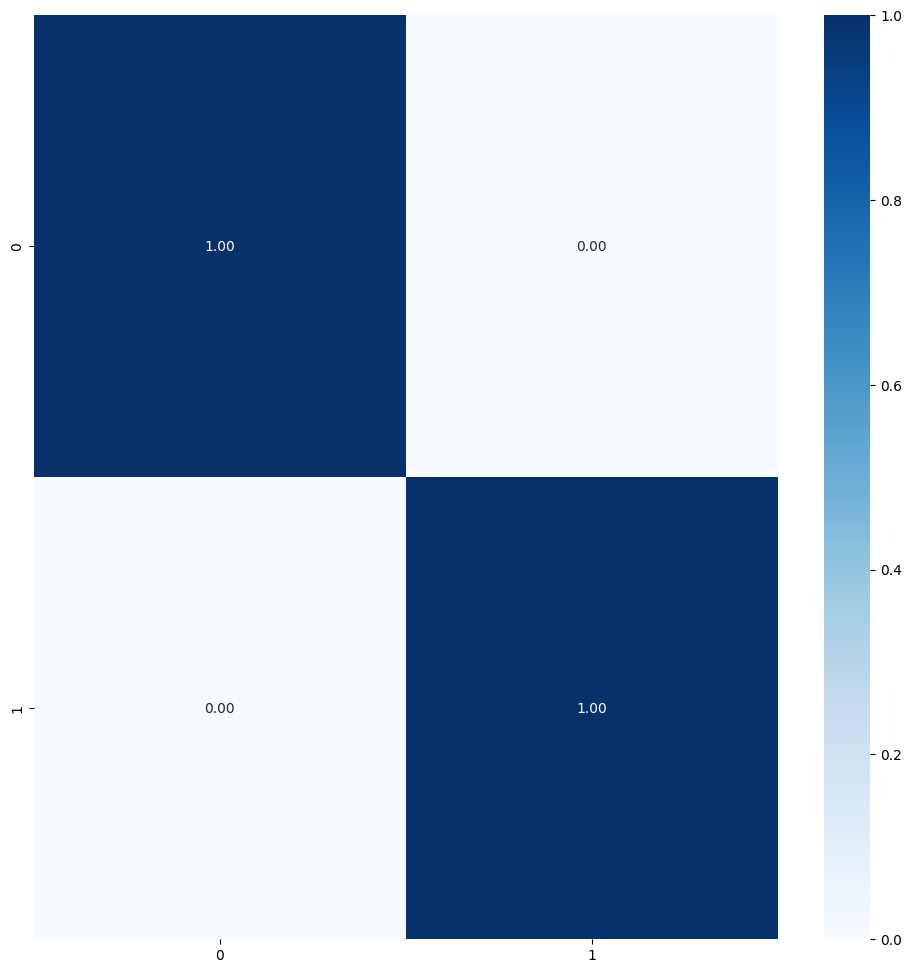


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.0006967443623580039, 0.0013111525913700461, 0.0005820916267111897, 0.00032859802013263106, 0.0007475255988538265]
Average Test Log Loss with 5-fold: 0.0007332224398851394

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0]
test_loss_list_all = [0.0007332224398851394]
precision_list_all = [1.0]
recall_list_all = [1.0]
f1_score_list_all = [1.0]
La carpeta 2 fue eliminada.
CPU times: user 52min 16s, sys: 6min 22s, total: 58min 38s
Wall time: 55min 24s


In [33]:
%%time
###################################### Probar Dropout 0.4
num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: MobileNet_tf_15003
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 33s 232ms/step - loss: 0.0187 - accuracy: 1.0000 - val_loss: 0.0152 - val_accuracy: 0.9985
Epoch 2/50
98/98 [==============================] - 17s 173ms/step - loss: 0.0100 - 

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15003_1.pkl
99/99 [==============================] - 14s 137ms/step - loss: 4.8456e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00048456303193233907
22/22 [==============================] - 3s 121ms/step - loss: 0.0034 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.003373868064954877
22/22 [==============================] - 3s 123ms/step - loss: 4.8775e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0004877548199146986
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy        

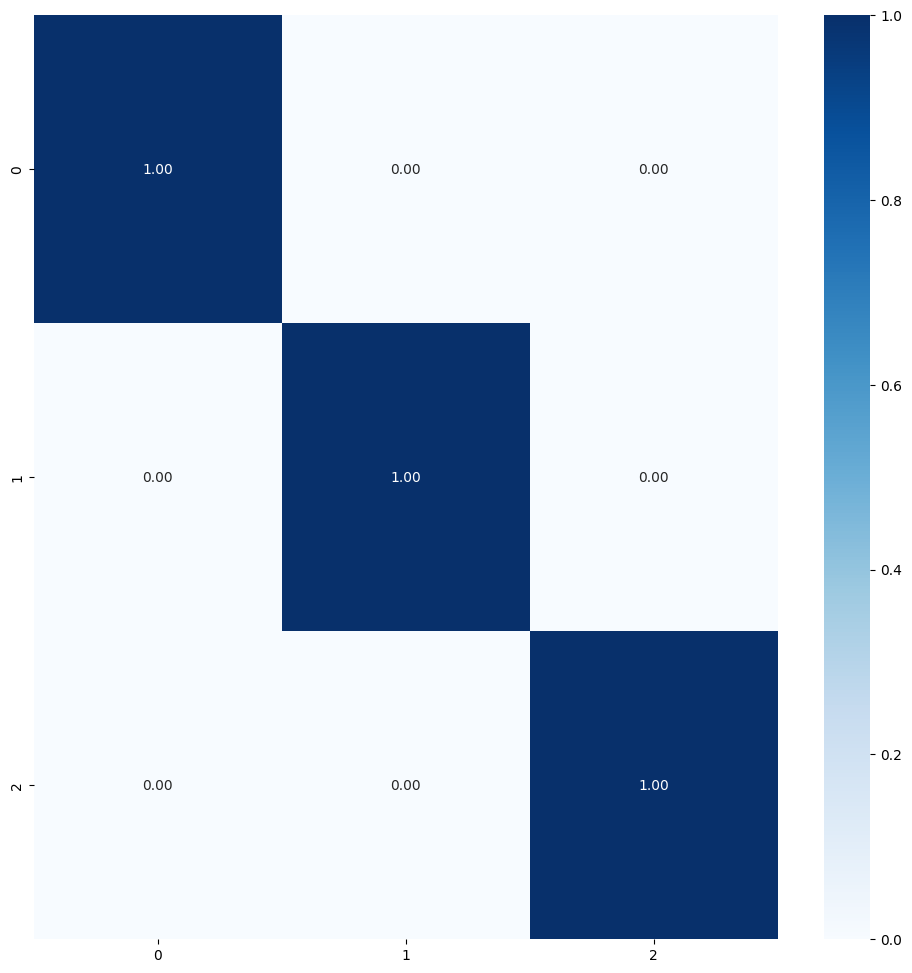


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 28s 188ms/step - loss: 0.0194 - accuracy: 1.0000 - val_loss: 0.0191 - val_accuracy: 0.9985
Epoch 2/50
98/98 [==============================] - 18s 178ms/step - loss: 0.0102 - accuracy: 1.0000 - val_loss: 0.0144 - val_accuracy: 0.9985
Epoch 3/50
98/98 [==============================] - 16s 160ms/step - loss: 0.0073 - accuracy: 1.0000 - val_loss: 0.0100 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 17s 164ms/step - loss: 0.0092 - accuracy: 0.9994 - v

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15003_2.pkl
99/99 [==============================] - 12s 122ms/step - loss: 0.0038 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.003843700746074319
22/22 [==============================] - 3s 115ms/step - loss: 0.0115 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.011494764126837254
22/22 [==============================] - 4s 129ms/step - loss: 0.0038 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0038438853807747364
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                  

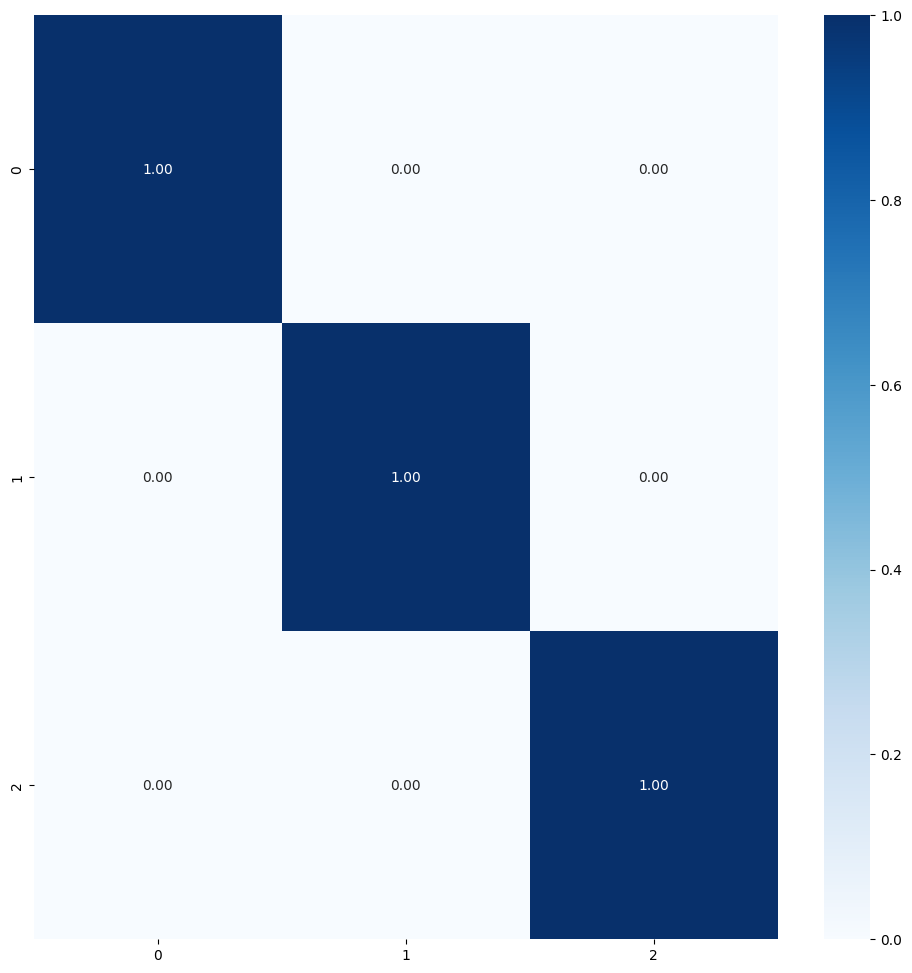


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 28s 189ms/step - loss: 0.0211 - accuracy: 1.0000 - val_loss: 0.0160 - val_accuracy: 1.0000
Epoch 2/50
98/98 [==============================] - 16s 158ms/step - loss: 0.0126 - accuracy: 1.0000 - val_loss: 0.0111 - val_accuracy: 0.9985
Epoch 3/50
98/98 [==============================] - 18s 179ms/step - loss: 0.0086 - accuracy: 1.0000 - val_loss: 0.0090 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 19s 192ms/step - loss: 0.0061 - accuracy: 1.0000 - v

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15003_3.pkl
99/99 [==============================] - 13s 118ms/step - loss: 0.0014 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0013514978345483541
22/22 [==============================] - 3s 116ms/step - loss: 0.0039 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.003931261133402586
22/22 [==============================] - 3s 116ms/step - loss: 0.0014 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.001352270832285285
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                  

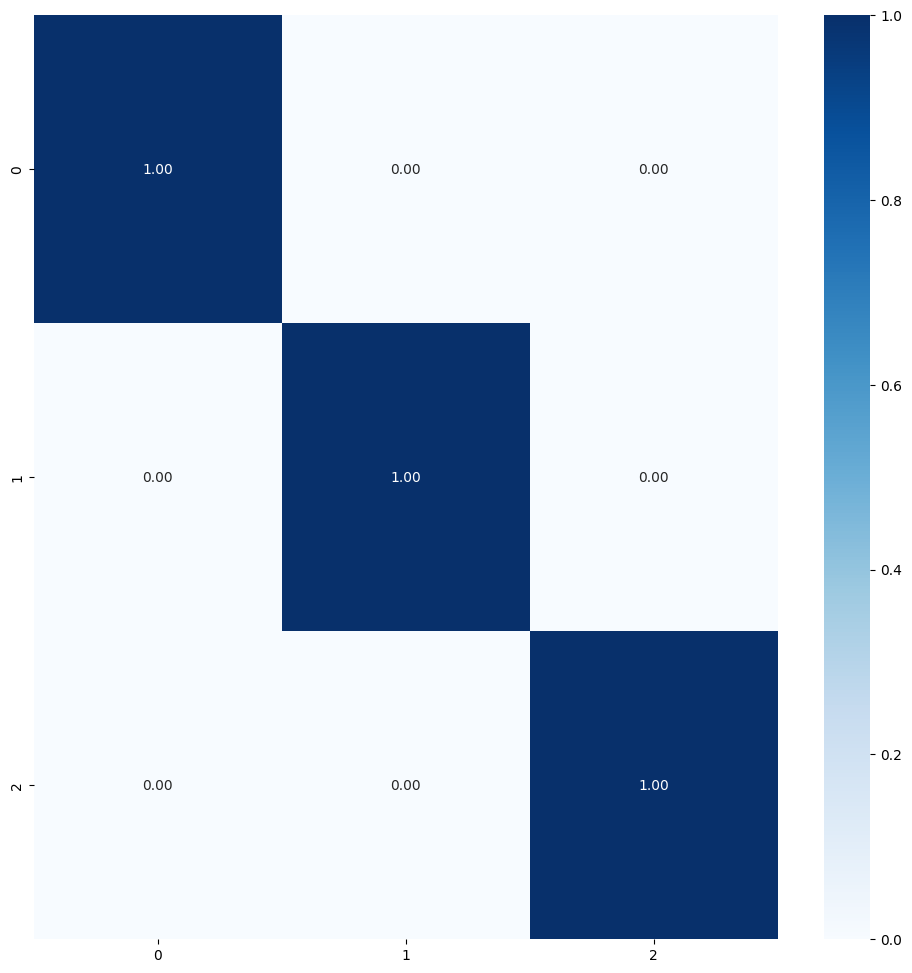


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 32s 212ms/step - loss: 0.0194 - accuracy: 1.0000 - val_loss: 0.0114 - val_accuracy: 1.0000
Epoch 2/50
98/98 [==============================] - 16s 156ms/step - loss: 0.0083 - accuracy: 1.0000 - val_loss: 0.0072 - val_accuracy: 0.9985
Epoch 3/50
98/98 [==============================] - 15s 152ms/step - loss: 0.0078 - accuracy: 0.9994 - val_loss: 0.0072 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 15s 156ms/step - loss: 0.0075 - accuracy: 0.9997 - v

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15003_4.pkl
99/99 [==============================] - 14s 136ms/step - loss: 0.0013 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0012951699318364263
22/22 [==============================] - 3s 122ms/step - loss: 0.0149 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.014894995838403702
22/22 [==============================] - 3s 126ms/step - loss: 0.0013 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.0012890622019767761
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy                 

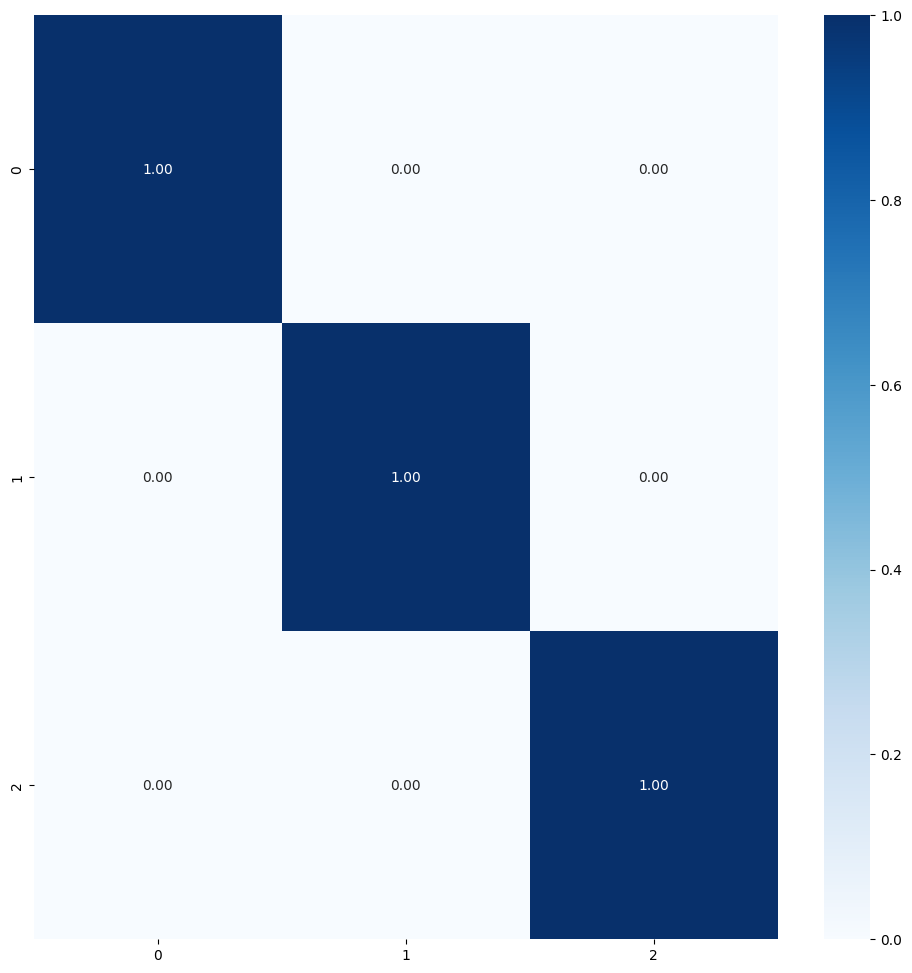


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15003_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_5 - Trainable: True
dropout_10 - Trainable: True
dense_16 - Trainable: True
dropout_11 - Trainable: True
dense_17 - Trainable: True
Epoch 1/50
98/98 [==============================] - 27s 179ms/step - loss: 0.0190 - accuracy: 1.0000 - val_loss: 0.0166 - val_accuracy: 0.9985
Epoch 2/50
98/98 [==============================] - 16s 156ms/step - loss: 0.0089 - accuracy: 0.9997 - val_loss: 0.0483 - val_accuracy: 0.9926
Epoch 3/50
98/98 [==============================] - 15s 156ms/step - loss: 0.0065 - accuracy: 1.0000 - val_loss: 0.0097 - val_accuracy: 0.9985
Epoch 4/50
98/98 [==============================] - 15s 150ms/step - loss: 0.0061 - accuracy: 0.9994 - v

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15003_5.pkl
99/99 [==============================] - 15s 143ms/step - loss: 3.3654e-04 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0003365410375408828
22/22 [==============================] - 4s 137ms/step - loss: 0.0046 - accuracy: 0.9985
Validation Accuracy: 0.9985185265541077
Validation Log Loss: 0.00462311040610075
22/22 [==============================] - 3s 137ms/step - loss: 3.3675e-04 - accuracy: 1.0000
Test Accuracy: 1.0
Test Log Loss: 0.00033674511360004544
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[225   0   0]
 [  0 225   0]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       225

    accuracy         

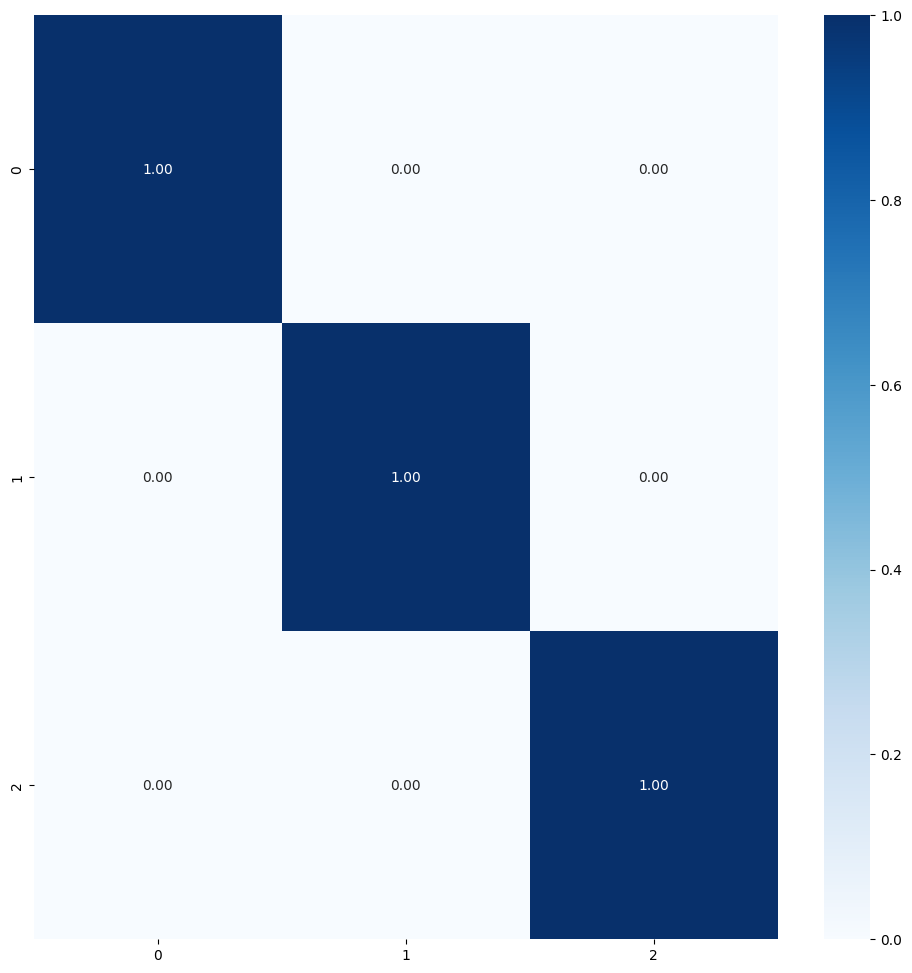


Best fold was 1 with val_accuracy: 1.0000
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 1.0

Test Metrics
test_acc_list: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Test Accuracy with 5-fold: 1.0
test_loss_list: [0.0004877548199146986, 0.0038438853807747364, 0.001352270832285285, 0.0012890622019767761, 0.00033674511360004544]
Average Test Log Loss with 5-fold: 0.0014619436697103083

Precision List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Precision List with 5-fold: 1.0
Recall List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average Recall List with 5-fold: 1.0
F1 Score List: [1.0, 1.0, 1.0, 1.0, 1.0]
Average F1 Score List with 5-fold: 1.0

Metrics List Store

test_acc_list_all = [1.0, 1.0]
test_loss_list_all = [0.0007332224398851394, 0.0014619436697103083]
precision_list_all = [1.0, 1.0]
recall_list_all = [1.0, 1.0]
f1_score_list_all = [1.0, 1.0]
La carpeta 3 fue eliminada.
CPU times: user 1h 17min 57s, sys: 8min 25s, total: 1h 26min 23s
Wall time: 1h 18min 33s


In [34]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

In [17]:
test_acc_list_all = [1.0, 1.0]
test_loss_list_all = [0.0007332224398851394, 0.0014619436697103083]
precision_list_all = [1.0, 1.0]
recall_list_all = [1.0, 1.0]
f1_score_list_all = [1.0, 1.0]

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: MobileNet_tf_15004
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5


2025-06-09 11:38:30.378328: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6


Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50


2025-06-09 11:38:42.804657: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-06-09 11:38:46.849715: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f4d7a70fdc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-09 11:38:46.849884: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-06-09 11:38:46.862956: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749469127.093876     405 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 [==============================] - 40s 184ms/step - loss: 0.0120 - accuracy: 0.9998 - val_loss: 0.0299 - val_accuracy: 0.9967
Epoch 2/50
131/131 [==============================] - 21s 162ms/step - loss: 0.0076 - accuracy: 1.0000 - val_loss: 0.0290 - val_accuracy: 0.9967
Epoch 3/50
131/131 [==============================] - 22s 164ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.0279 - val_accuracy: 0.9955
Epoch 4/50
131/131 [==============================] - 20s 154ms/step - loss: 0.0079 - accuracy: 0.9990 - val_loss: 0.0292 - val_accuracy: 0.9967
Epoch 5/50
131/131 [==============================] - 21s 159ms/step - loss: 0.0117 - accuracy: 0.9990 - val_loss: 0.0277 - val_accuracy: 0.9955
Epoch 6/50
131/131 [==============================] - 15s 115ms/step - loss: 0.0074 - accuracy: 1.0000 - val_loss: 0.0299 - val_accuracy: 0.9955
Epoch 7/50
131/131 [==============================] - 20s 156ms/step - loss: 0.0066 - accuracy: 1.0000 - val_loss: 0.0297 - val_accuracy: 0.9

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15004_1.pkl
132/132 [==============================] - 17s 131ms/step - loss: 0.0021 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.002079368568956852
29/29 [==============================] - 5s 128ms/step - loss: 0.0253 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.025260334834456444
29/29 [==============================] - 4s 134ms/step - loss: 0.0226 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.022618651390075684
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00   

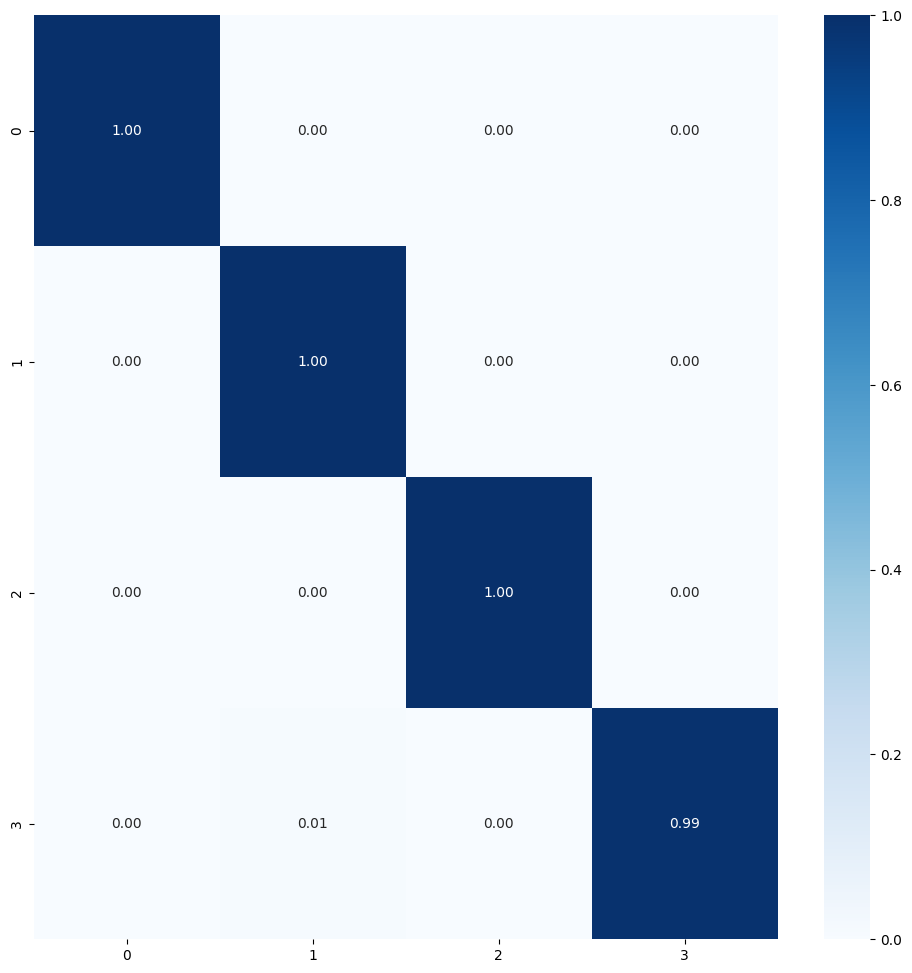


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 33s 172ms/step - loss: 0.0127 - accuracy: 0.9995 - val_loss: 0.0285 - val_accuracy: 0.9967
Epoch 2/50
131/131 [==============================] - 21s 158ms/step - loss: 0.0091 - accuracy: 0.9995 - val_loss: 0.0370 - val_accuracy: 0.9955
Epoch 3/50
131/131 [==============================] - 22s 165ms/step - loss: 0.0107 - accuracy: 0.9990 - val_loss: 0.0386 - val_accuracy: 0.9967
Epoch 4/50
131/131 [==============================] - 23s 172ms/step - loss: 0.0082 - accuracy: 1

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15004_2.pkl
132/132 [==============================] - 19s 139ms/step - loss: 0.0018 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.001822186284698546
29/29 [==============================] - 5s 150ms/step - loss: 0.0274 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.027442021295428276
29/29 [==============================] - 5s 129ms/step - loss: 0.0226 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.022578736767172813
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00   

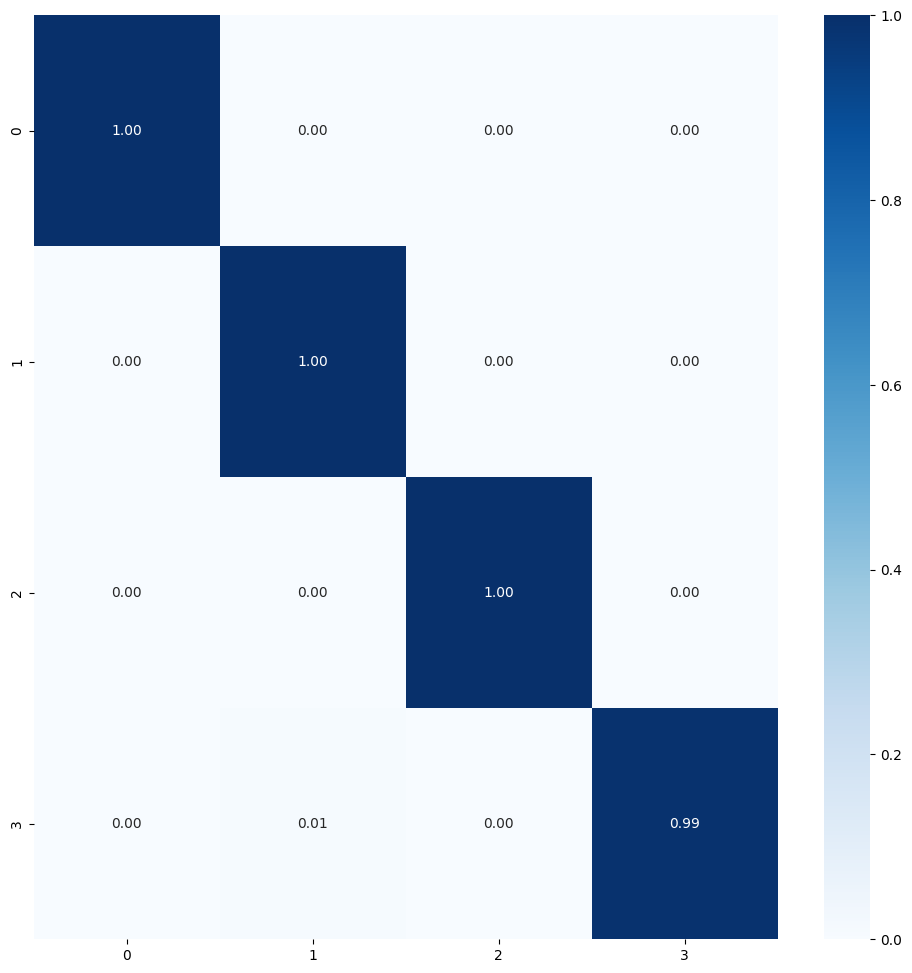


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 37s 197ms/step - loss: 0.0103 - accuracy: 0.9998 - val_loss: 0.0400 - val_accuracy: 0.9944
Epoch 2/50
131/131 [==============================] - 24s 180ms/step - loss: 0.0056 - accuracy: 1.0000 - val_loss: 0.0269 - val_accuracy: 0.9955
Epoch 3/50
131/131 [==============================] - 22s 168ms/step - loss: 0.0050 - accuracy: 1.0000 - val_loss: 0.0259 - val_accuracy: 0.9955
Epoch 4/50
131/131 [==============================] - 23s 175ms/step - loss: 0.0050 - accuracy: 0

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15004_3.pkl
132/132 [==============================] - 19s 137ms/step - loss: 0.0051 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005105075892060995
29/29 [==============================] - 5s 137ms/step - loss: 0.0364 - accuracy: 0.9967
Validation Accuracy: 0.996666669845581
Validation Log Loss: 0.03643464297056198
29/29 [==============================] - 4s 135ms/step - loss: 0.0289 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.028910500928759575
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00    

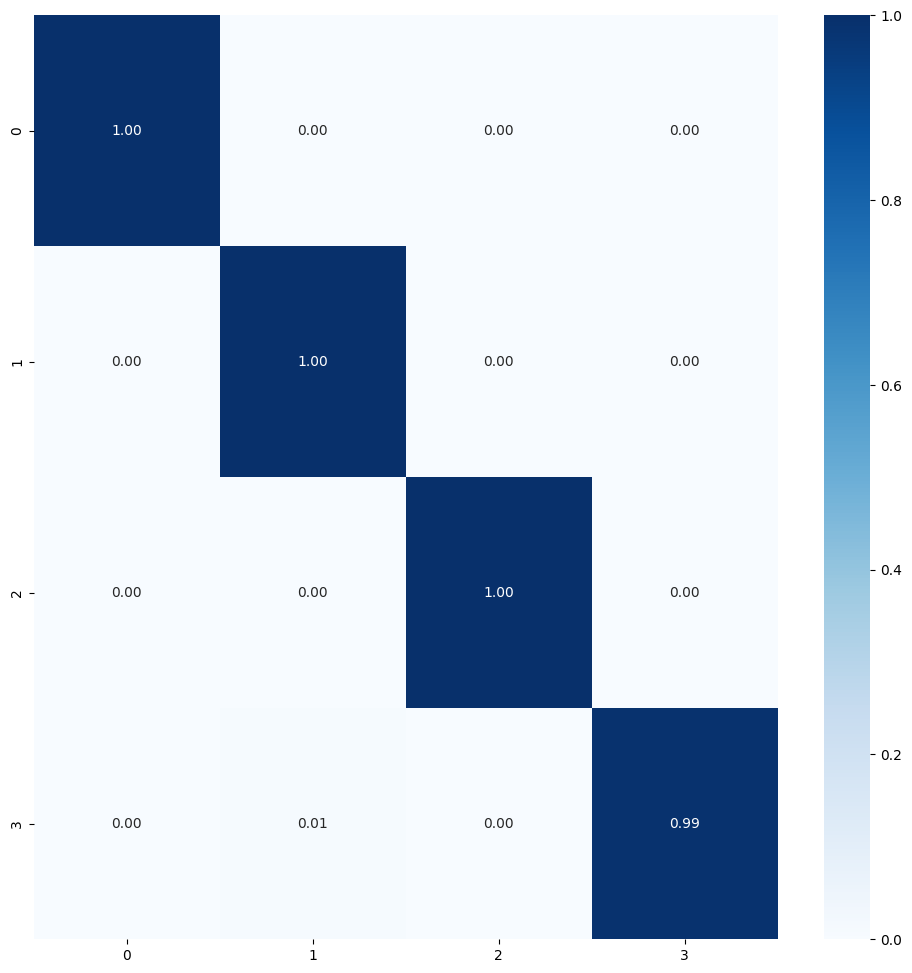


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 37s 192ms/step - loss: 0.0119 - accuracy: 1.0000 - val_loss: 0.0263 - val_accuracy: 0.9967
Epoch 2/50
131/131 [==============================] - 21s 157ms/step - loss: 0.0068 - accuracy: 1.0000 - val_loss: 0.0290 - val_accuracy: 0.9967
Epoch 3/50
131/131 [==============================] - 20s 155ms/step - loss: 0.0044 - accuracy: 1.0000 - val_loss: 0.0249 - val_accuracy: 0.9967
Epoch 4/50
131/131 [==============================] - 22s 166ms/step - loss: 0.0036 - accuracy: 1

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15004_4.pkl
132/132 [==============================] - 21s 158ms/step - loss: 0.0058 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005753256846219301
29/29 [==============================] - 5s 144ms/step - loss: 0.0394 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.03937934711575508
29/29 [==============================] - 5s 142ms/step - loss: 0.0252 - accuracy: 0.9978
Test Accuracy: 0.9977777600288391
Test Log Loss: 0.025243418291211128
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 225   0   0]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      1.00       225
           2       1.00    

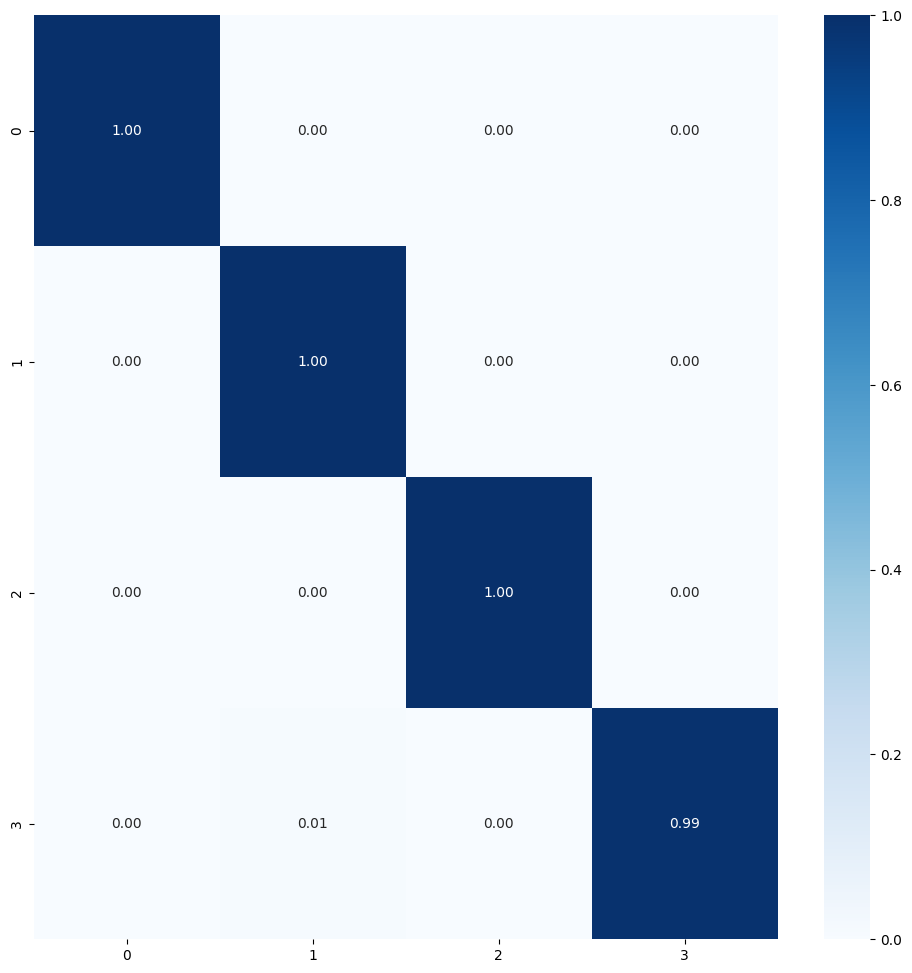


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15004_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_10 - Trainable: True
dropout_20 - Trainable: True
dense_31 - Trainable: True
dropout_21 - Trainable: True
dense_32 - Trainable: True
Epoch 1/50
131/131 [==============================] - 41s 211ms/step - loss: 0.0115 - accuracy: 0.9995 - val_loss: 0.0306 - val_accuracy: 0.9944
Epoch 2/50
131/131 [==============================] - 26s 197ms/step - loss: 0.0065 - accuracy: 1.0000 - val_loss: 0.0299 - val_accuracy: 0.9967
Epoch 3/50
131/131 [==============================] - 25s 181ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0288 - val_accuracy: 0.9967
Epoch 4/50
131/131 [==============================] - 21s 163ms/step - loss: 0.0047 - accuracy: 1

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15004_5.pkl
132/132 [==============================] - 18s 132ms/step - loss: 0.0017 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.001730697345919907
29/29 [==============================] - 4s 129ms/step - loss: 0.0247 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.024665677919983864
29/29 [==============================] - 4s 129ms/step - loss: 0.0260 - accuracy: 0.9967
Test Accuracy: 0.996666669845581
Test Log Loss: 0.026034649461507797
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [  0 224   0   1]
 [  0   0 225   0]
 [  0   2   0 223]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00      0.99       225
           2       1.00    

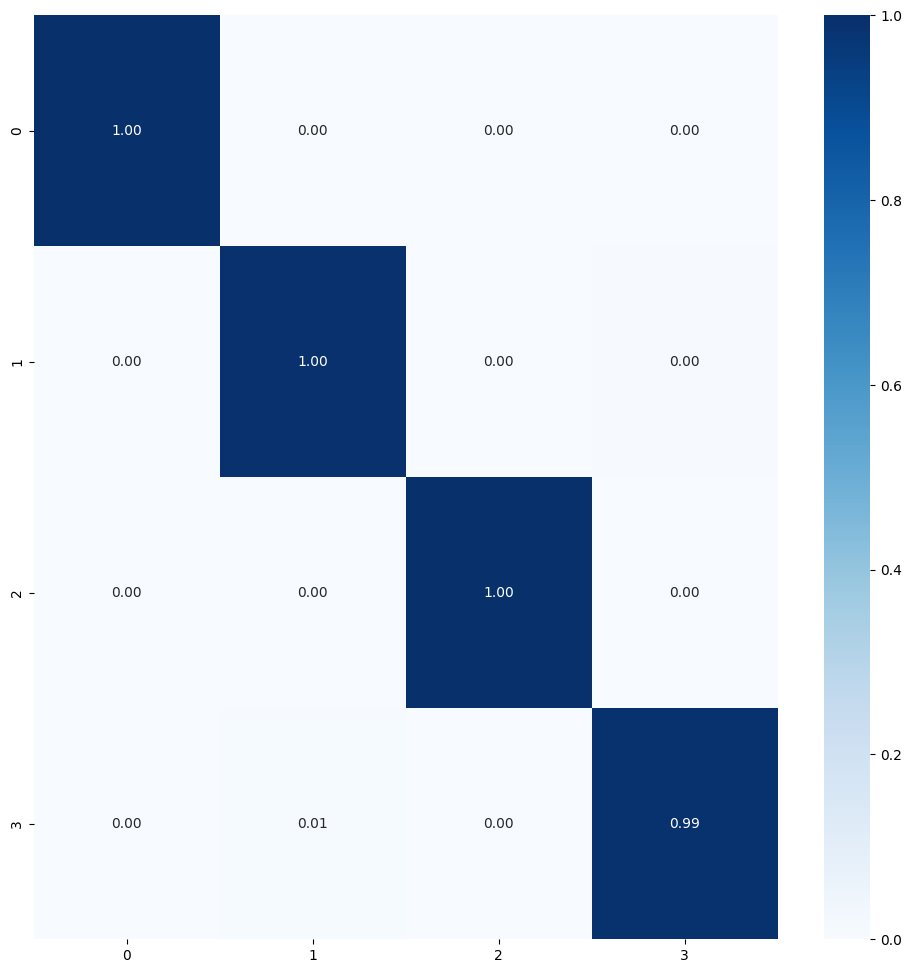


Best fold was 1 with val_accuracy: 0.9978
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9973214268684387

Test Metrics
test_acc_list: [0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.9977777600288391, 0.996666669845581]
Average Test Accuracy with 5-fold: 0.9975555419921875
test_loss_list: [0.022618651390075684, 0.022578736767172813, 0.028910500928759575, 0.025243418291211128, 0.026034649461507797]
Average Test Log Loss with 5-fold: 0.0250771913677454

Precision List: [0.9977973568281938, 0.9977973568281938, 0.9977973568281938, 0.9977973568281938, 0.9966715391908976]
Average Precision List with 5-fold: 0.9975721933007347
Recall List: [0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9977777777777778, 0.9966666666666667]
Average Recall List with 5-fold: 0.9975555555555555
F1 Score List: [0.9977777338811631, 0.9977777338811631, 0.9977777338811631, 0.9977777338811631, 0.99666665020568]
Average F1 Score List with 5-fold: 0.997

In [18]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: MobileNet_tf_15005
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 45s 198ms/step - loss: 0.1100 - accuracy: 0.9990 - val_loss: 0.2313 - val_accuracy: 0.9705
Epoch 2/50
164/164 [==============================] - 29s 177m

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15005_1.pkl
165/165 [==============================] - 22s 129ms/step - loss: 0.0272 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.027186328545212746
36/36 [==============================] - 6s 135ms/step - loss: 0.0529 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.052860431373119354
36/36 [==============================] - 5s 131ms/step - loss: 0.0609 - accuracy: 0.9947
Test Accuracy: 0.9946666955947876
Test Log Loss: 0.06086258962750435
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99     

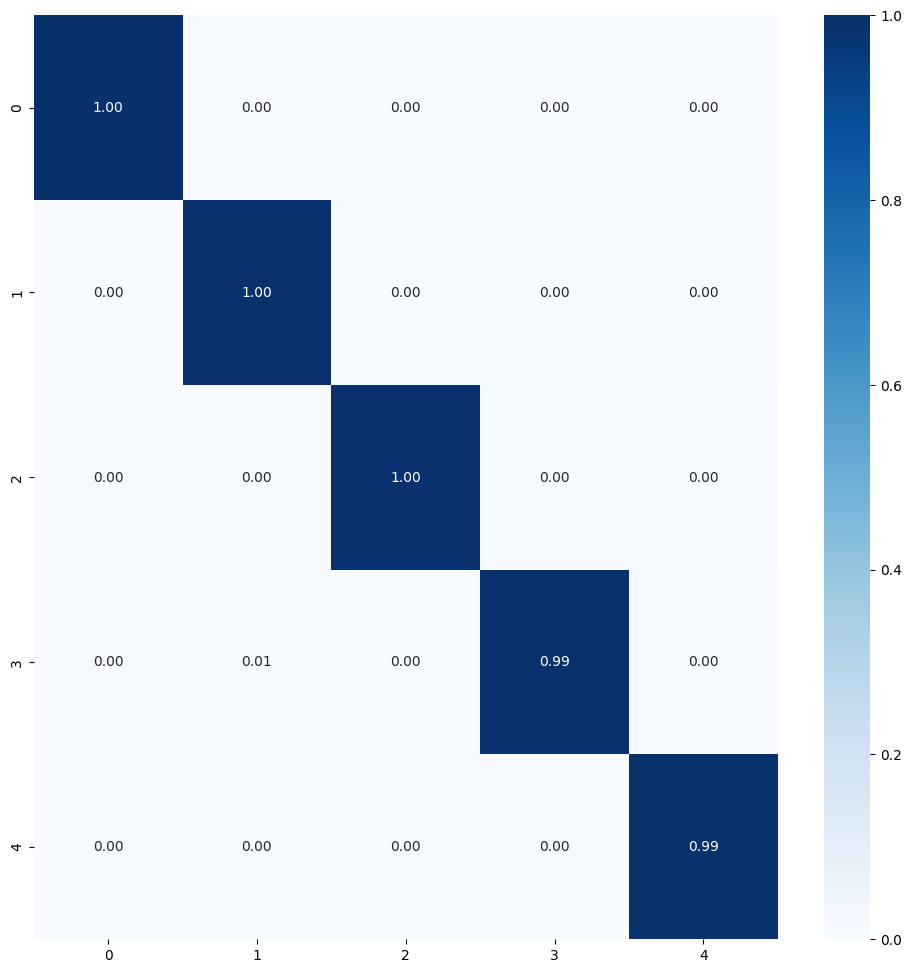


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 44s 209ms/step - loss: 0.1031 - accuracy: 0.9992 - val_loss: 0.1155 - val_accuracy: 0.9955
Epoch 2/50
164/164 [==============================] - 28s 167ms/step - loss: 0.0827 - accuracy: 0.9990 - val_loss: 0.5347 - val_accuracy: 0.9009
Epoch 3/50
164/164 [==============================] - 26s 161ms/step - loss: 0.0783 - accuracy: 0.9971 - val_loss: 0.0946 - val_accuracy: 0.9946
Epoch 4/50
164/164 [==============================] - 26s 159ms/step - loss: 0.0710 - accuracy: 0

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15005_2.pkl
165/165 [==============================] - 21s 127ms/step - loss: 0.0220 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.021998582407832146
36/36 [==============================] - 5s 128ms/step - loss: 0.0453 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.045332081615924835
36/36 [==============================] - 6s 126ms/step - loss: 0.0490 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.04895314946770668
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 224   0   1   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      

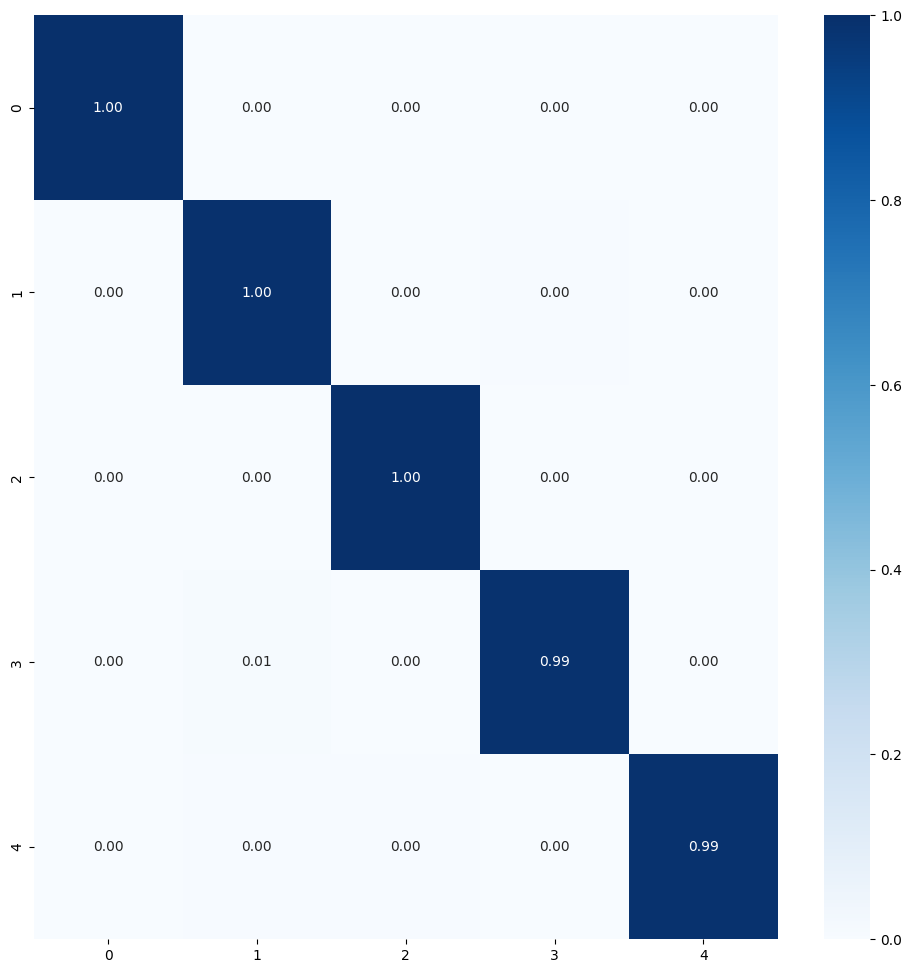


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 39s 174ms/step - loss: 0.1115 - accuracy: 0.9990 - val_loss: 0.1305 - val_accuracy: 0.9946
Epoch 2/50
164/164 [==============================] - 26s 157ms/step - loss: 0.0915 - accuracy: 0.9996 - val_loss: 0.2157 - val_accuracy: 0.9714
Epoch 3/50
164/164 [==============================] - 29s 171ms/step - loss: 0.0849 - accuracy: 0.9985 - val_loss: 0.0995 - val_accuracy: 0.9955
Epoch 4/50
164/164 [==============================] - 29s 176ms/step - loss: 0.0773 - accuracy: 0

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15005_3.pkl
165/165 [==============================] - 22s 125ms/step - loss: 0.0196 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0196011271327734
36/36 [==============================] - 5s 123ms/step - loss: 0.0458 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.04579639434814453
36/36 [==============================] - 5s 128ms/step - loss: 0.0502 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.05020771920681
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   1   0 223]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.00   

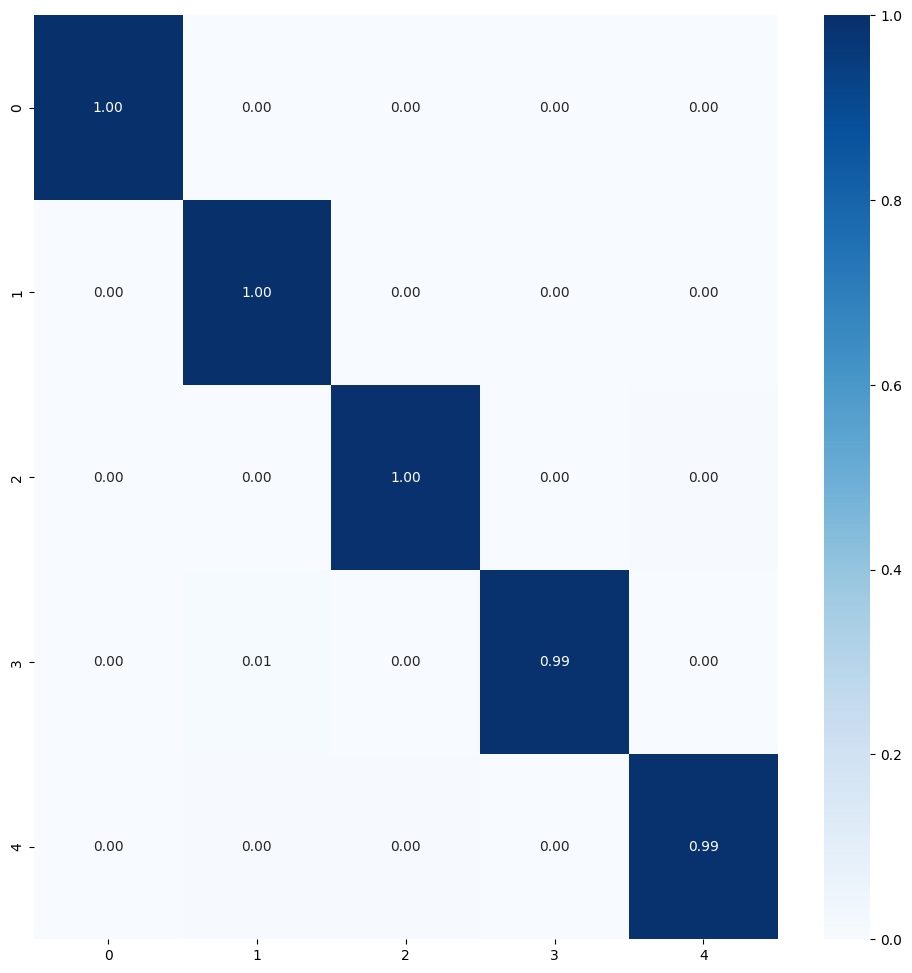


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 37s 166ms/step - loss: 0.1163 - accuracy: 0.9987 - val_loss: 0.1538 - val_accuracy: 0.9821
Epoch 2/50
164/164 [==============================] - 26s 156ms/step - loss: 0.0970 - accuracy: 0.9996 - val_loss: 0.1188 - val_accuracy: 0.9955
Epoch 3/50
164/164 [==============================] - 24s 143ms/step - loss: 0.0942 - accuracy: 0.9971 - val_loss: 0.1130 - val_accuracy: 0.9946
Epoch 4/50
164/164 [==============================] - 25s 153ms/step - loss: 0.0861 - accuracy: 0

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15005_4.pkl
165/165 [==============================] - 23s 136ms/step - loss: 0.0258 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.025790147483348846
36/36 [==============================] - 5s 130ms/step - loss: 0.0566 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.05655305087566376
36/36 [==============================] - 5s 126ms/step - loss: 0.0622 - accuracy: 0.9929
Test Accuracy: 0.992888867855072
Test Log Loss: 0.06221390143036842
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 224   0   1]
 [  0   2   0 223   0]
 [  0   1   4   0 220]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1.

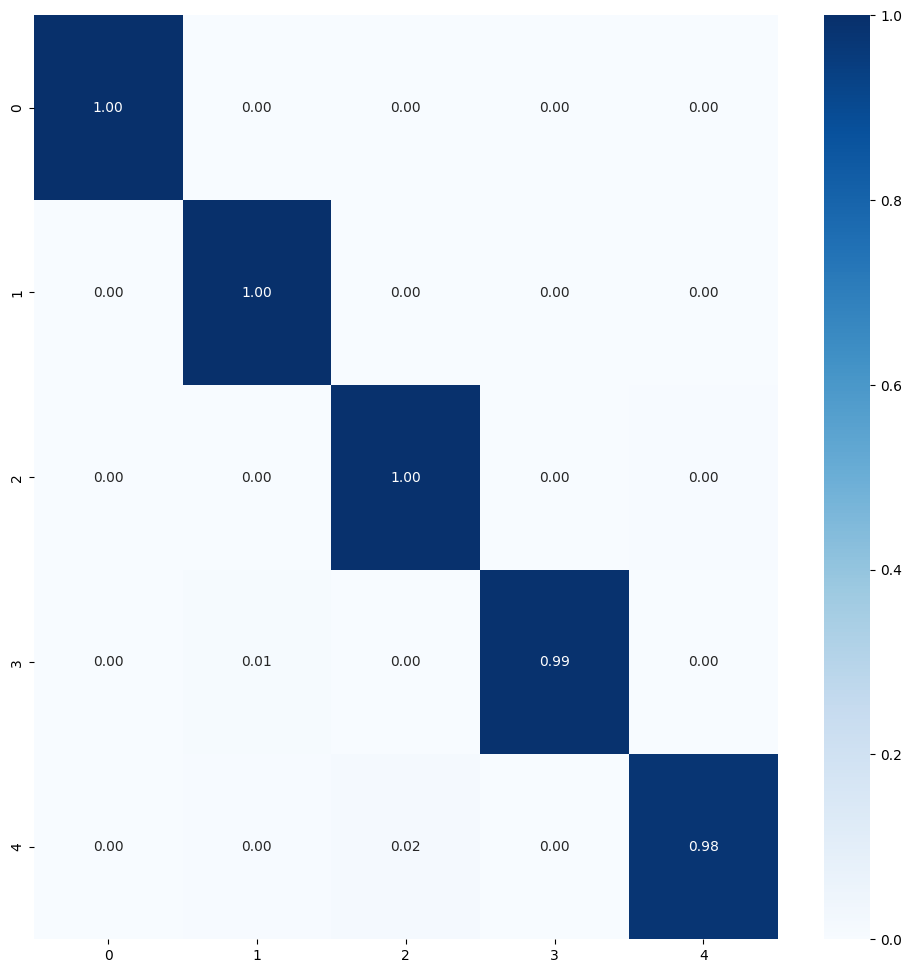


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15005_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
164/164 [==============================] - 39s 179ms/step - loss: 0.1034 - accuracy: 0.9992 - val_loss: 0.1057 - val_accuracy: 0.9946
Epoch 2/50
164/164 [==============================] - 28s 167ms/step - loss: 0.0820 - accuracy: 0.9992 - val_loss: 0.1025 - val_accuracy: 0.9911
Epoch 3/50
164/164 [==============================] - 27s 166ms/step - loss: 0.0732 - accuracy: 0.9989 - val_loss: 0.1023 - val_accuracy: 0.9955
Epoch 4/50
164/164 [==============================] - 28s 164ms/step - loss: 0.0668 - accuracy: 0

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15005_5.pkl
165/165 [==============================] - 24s 135ms/step - loss: 0.0205 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.020506156608462334
36/36 [==============================] - 6s 134ms/step - loss: 0.0550 - accuracy: 0.9947
Validation Accuracy: 0.9946666955947876
Validation Log Loss: 0.05495355278253555
36/36 [==============================] - 5s 130ms/step - loss: 0.0605 - accuracy: 0.9929
Test Accuracy: 0.992888867855072
Test Log Loss: 0.06054318696260452
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [  0 225   0   0   0]
 [  0   0 225   0   0]
 [  0   2   0 223   0]
 [  0   1   5   0 219]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       0.99      1

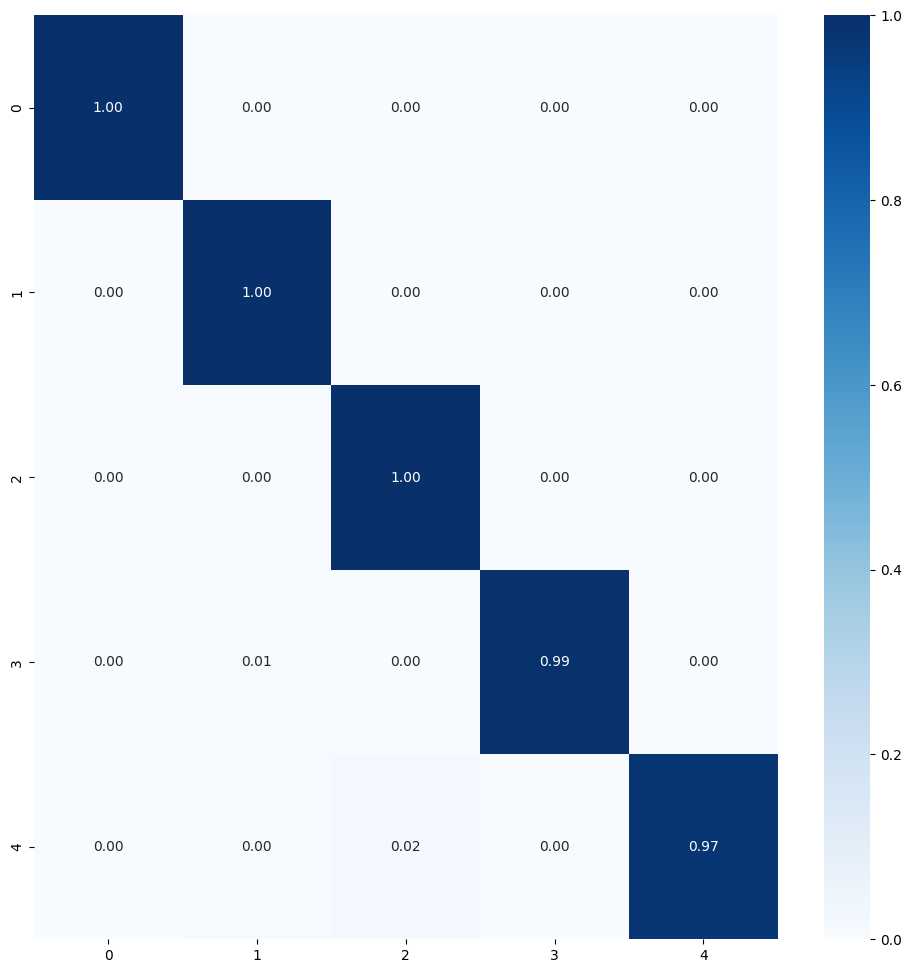


Best fold was 1 with val_accuracy: 0.9973
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9973214268684387

Test Metrics
test_acc_list: [0.9946666955947876, 0.995555579662323, 0.995555579662323, 0.992888867855072, 0.992888867855072]
Average Test Accuracy with 5-fold: 0.9943111181259155
test_loss_list: [0.06086258962750435, 0.04895314946770668, 0.05020771920681, 0.06221390143036842, 0.06054318696260452]
Average Test Log Loss with 5-fold: 0.056556109338998795

Precision List: [0.9946822250192294, 0.9955790152987631, 0.9955866750208855, 0.9929546717472414, 0.9930205949656751]
Average Precision List with 5-fold: 0.9943646364103589
Recall List: [0.9946666666666667, 0.9955555555555555, 0.9955555555555555, 0.9928888888888888, 0.9928888888888888]
Average Recall List with 5-fold: 0.9943111111111111
F1 Score List: [0.9946685938160404, 0.9955574694773508, 0.9955574477616727, 0.9928845510674795, 0.9928821346453798]
Average F1 Score List with 5-fold: 0.9943100393

In [19]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: MobileNet_tf_15006
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 52s 209ms/step - loss: 0.0193 - accuracy: 0.9997 - val_loss: 0.0544 - val_accuracy: 0.9918
Epoch 2/50
196/196 [==============================] - 3

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15006_1.pkl
197/197 [==============================] - 28s 140ms/step - loss: 0.0053 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005283886566758156
43/43 [==============================] - 6s 141ms/step - loss: 0.0320 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.031999487429857254
43/43 [==============================] - 6s 141ms/step - loss: 0.0415 - accuracy: 0.9948
Test Accuracy: 0.9948148131370544
Test Log Loss: 0.04154761880636215
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00  

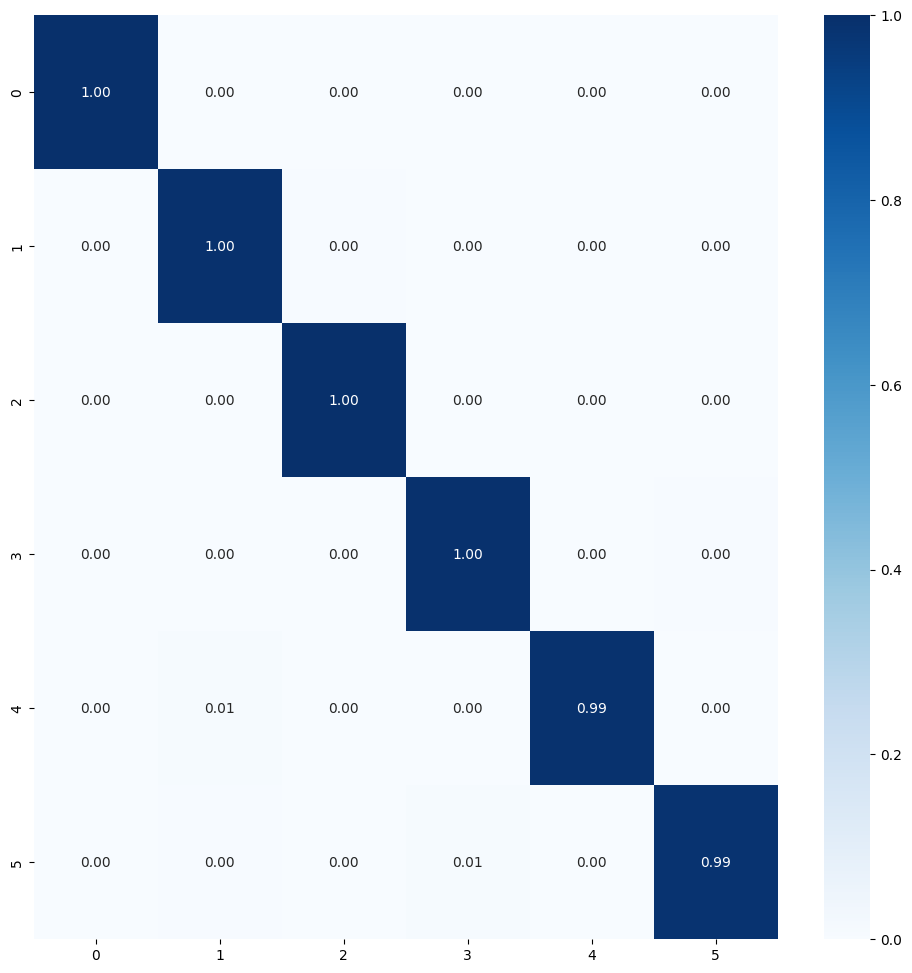


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 47s 182ms/step - loss: 0.0190 - accuracy: 0.9995 - val_loss: 0.0477 - val_accuracy: 0.9948
Epoch 2/50
196/196 [==============================] - 35s 177ms/step - loss: 0.0202 - accuracy: 0.9989 - val_loss: 0.0468 - val_accuracy: 0.9948
Epoch 3/50
196/196 [==============================] - 38s 194ms/step - loss: 0.0165 - accuracy: 0.9995 - val_loss: 0.0526 - val_accuracy: 0.9933
Epoch 4/50
196/196 [==============================] - 35s 176ms/step - loss: 0.0172 - accuracy: 0

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15006_2.pkl
197/197 [==============================] - 30s 147ms/step - loss: 0.0034 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.003444511443376541
43/43 [==============================] - 7s 145ms/step - loss: 0.0409 - accuracy: 0.9926
Validation Accuracy: 0.9925925731658936
Validation Log Loss: 0.04090995714068413
43/43 [==============================] - 6s 136ms/step - loss: 0.0504 - accuracy: 0.9933
Test Accuracy: 0.9933333396911621
Test Log Loss: 0.05044098570942879
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 225   0   0]
 [  0   2   0   0 223   0]
 [  0   1   0   5   0 219]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00  

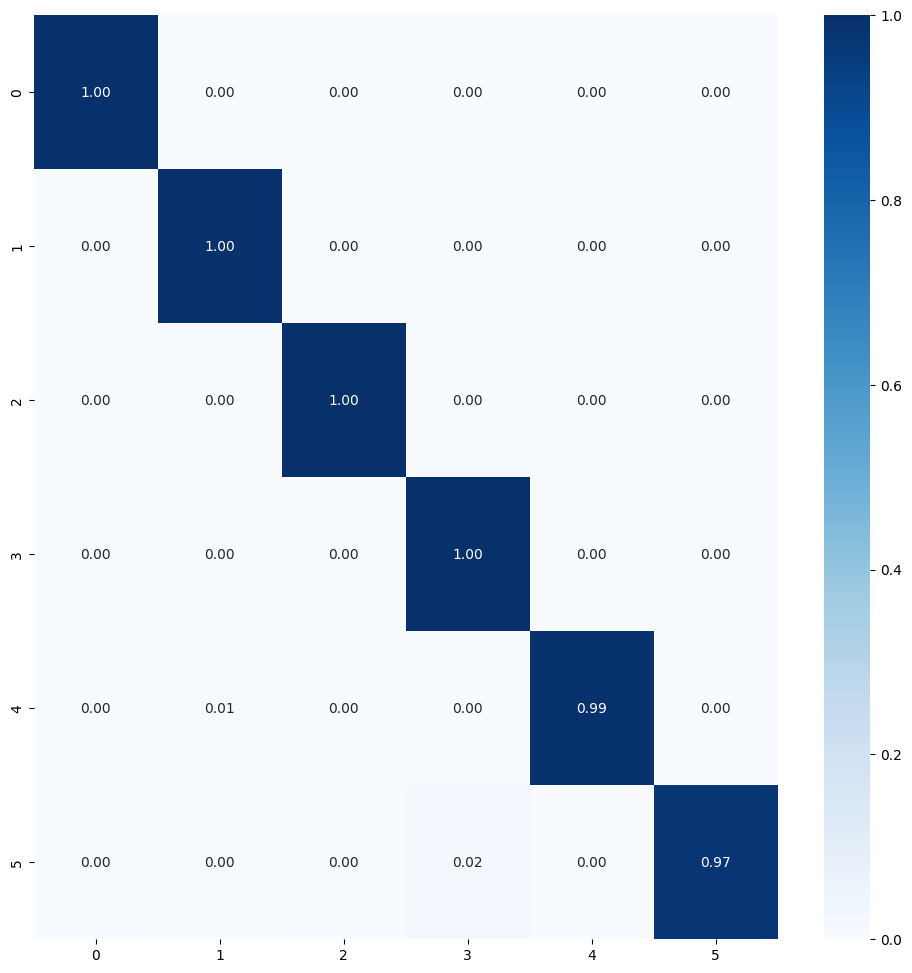


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 50s 200ms/step - loss: 0.0208 - accuracy: 0.9994 - val_loss: 0.0525 - val_accuracy: 0.9948
Epoch 2/50
196/196 [==============================] - 34s 175ms/step - loss: 0.0204 - accuracy: 0.9987 - val_loss: 0.4319 - val_accuracy: 0.9107
Epoch 3/50
196/196 [==============================] - 35s 178ms/step - loss: 0.0162 - accuracy: 0.9998 - val_loss: 0.0476 - val_accuracy: 0.9940
Epoch 4/50
196/196 [==============================] - 34s 175ms/step - loss: 0.0203 - accuracy: 0

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15006_3.pkl
197/197 [==============================] - 27s 134ms/step - loss: 0.0051 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0050730034708976746
43/43 [==============================] - 6s 136ms/step - loss: 0.0383 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.038295723497867584
43/43 [==============================] - 6s 132ms/step - loss: 0.0410 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.040981464087963104
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00

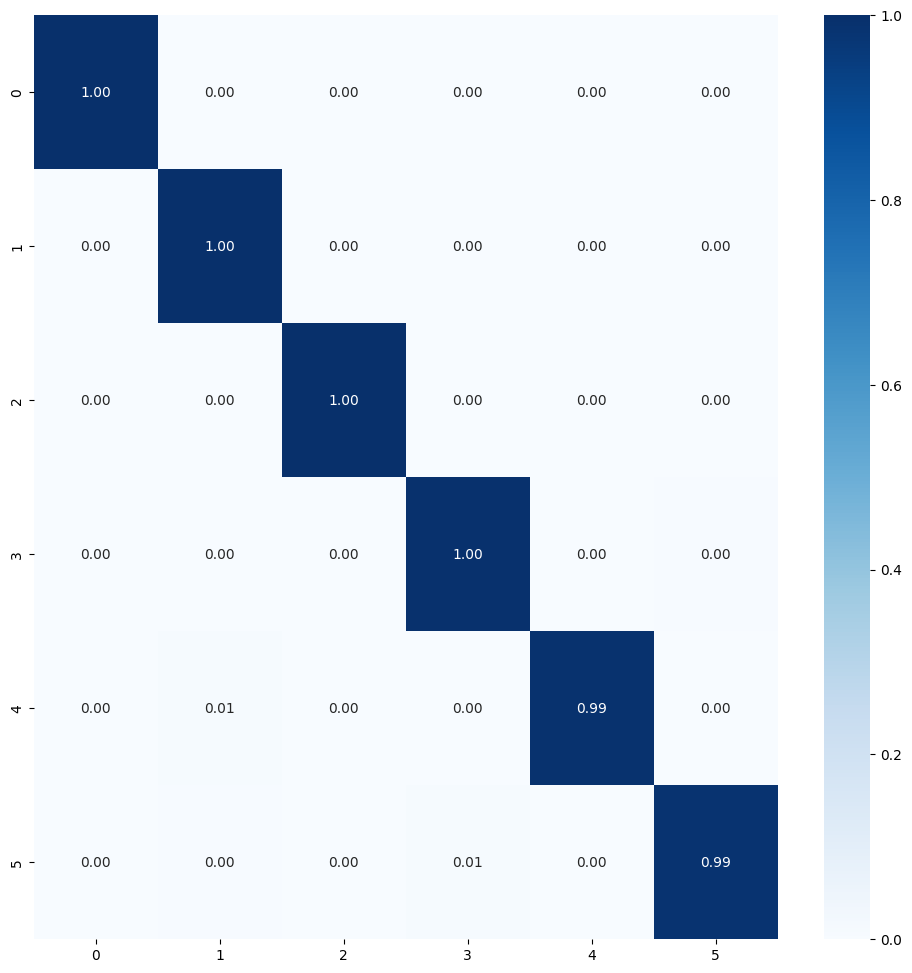


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 47s 189ms/step - loss: 0.0202 - accuracy: 0.9994 - val_loss: 0.0438 - val_accuracy: 0.9955
Epoch 2/50
196/196 [==============================] - 33s 170ms/step - loss: 0.0158 - accuracy: 1.0000 - val_loss: 0.0367 - val_accuracy: 0.9963
Epoch 3/50
196/196 [==============================] - 33s 168ms/step - loss: 0.0158 - accuracy: 0.9994 - val_loss: 0.0942 - val_accuracy: 0.9821
Epoch 4/50
196/196 [==============================] - 34s 172ms/step - loss: 0.0162 - accuracy: 0

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15006_4.pkl
197/197 [==============================] - 27s 136ms/step - loss: 0.0047 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.004707951098680496
43/43 [==============================] - 6s 137ms/step - loss: 0.0350 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.0350145623087883
43/43 [==============================] - 6s 126ms/step - loss: 0.0351 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.03505082428455353
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   2   0 222]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00    

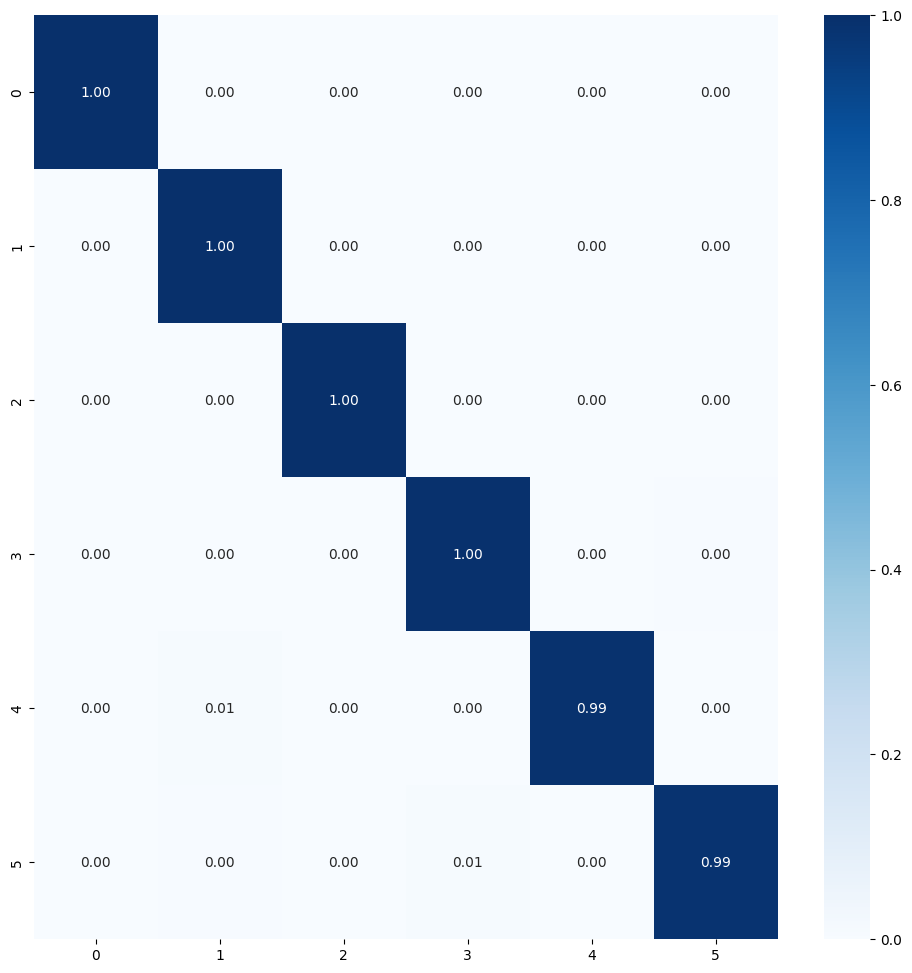


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15006_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_22 - Trainable: True
dropout_44 - Trainable: True
dense_67 - Trainable: True
dropout_45 - Trainable: True
dense_68 - Trainable: True
Epoch 1/50
196/196 [==============================] - 44s 174ms/step - loss: 0.0185 - accuracy: 0.9997 - val_loss: 0.0422 - val_accuracy: 0.9955
Epoch 2/50
196/196 [==============================] - 32s 161ms/step - loss: 0.0142 - accuracy: 0.9998 - val_loss: 0.0423 - val_accuracy: 0.9948
Epoch 3/50
196/196 [==============================] - 31s 159ms/step - loss: 0.0166 - accuracy: 0.9986 - val_loss: 0.0483 - val_accuracy: 0.9933
Epoch 4/50
196/196 [==============================] - 31s 155ms/step - loss: 0.0172 - accuracy: 0

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15006_5.pkl
197/197 [==============================] - 27s 139ms/step - loss: 0.0034 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0033594307024031878
43/43 [==============================] - 6s 139ms/step - loss: 0.0374 - accuracy: 0.9948
Validation Accuracy: 0.9948148131370544
Validation Log Loss: 0.03743261843919754
43/43 [==============================] - 6s 134ms/step - loss: 0.0395 - accuracy: 0.9933
Test Accuracy: 0.9933333396911621
Test Log Loss: 0.039471544325351715
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[225   0   0   0   0   0]
 [  0 224   1   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0   0 224   0   1]
 [  0   2   0   0 223   0]
 [  0   1   0   4   0 220]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       1.00

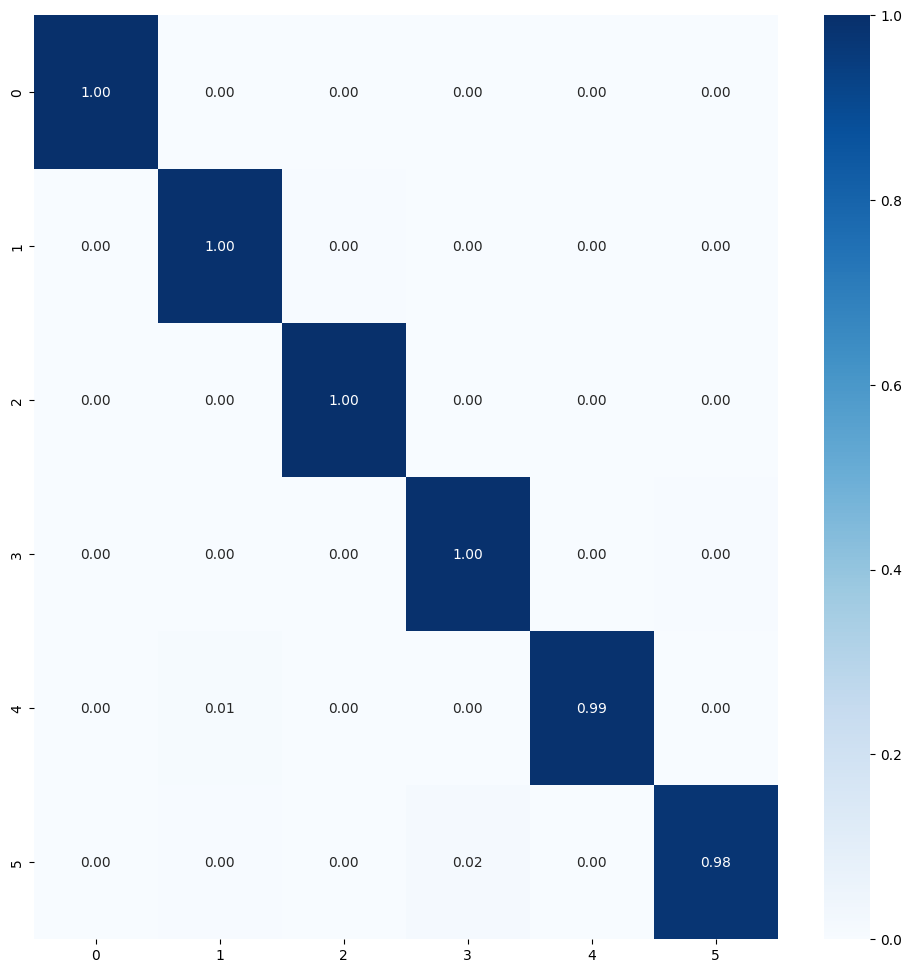


Best fold was 4 with val_accuracy: 0.9970
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.996279776096344

Test Metrics
test_acc_list: [0.9948148131370544, 0.9933333396911621, 0.995555579662323, 0.995555579662323, 0.9933333396911621]
Average Test Accuracy with 5-fold: 0.9945185303688049
test_loss_list: [0.04154761880636215, 0.05044098570942879, 0.040981464087963104, 0.03505082428455353, 0.039471544325351715]
Average Test Log Loss with 5-fold: 0.04149848744273186

Precision List: [0.994837583292207, 0.9934367052955531, 0.9955847071347165, 0.9955847071347165, 0.9933817692801917]
Average Precision List with 5-fold: 0.9945650944274769
Recall List: [0.9948148148148149, 0.9933333333333335, 0.9955555555555556, 0.9955555555555556, 0.9933333333333335]
Average Recall List with 5-fold: 0.9945185185185187
F1 Score List: [0.994814734289022, 0.9933277228934742, 0.9955554569333644, 0.9955554569333644, 0.9933297365785573]
Average F1 Score List with 5-fold: 0.9945166

In [20]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: MobileNet_tf_15007
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 51s 177ms/step - loss: 0.0099 - accuracy: 0.9999 - val_loss: 0.0446 - val_accuracy: 0.9936
Epoch 2/50
229/229 [====================

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15007_1.pkl
230/230 [==============================] - 29s 126ms/step - loss: 0.0056 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0055717285722494125
50/50 [==============================] - 7s 130ms/step - loss: 0.0451 - accuracy: 0.9943
Validation Accuracy: 0.9942857027053833
Validation Log Loss: 0.045065365731716156
50/50 [==============================] - 7s 128ms/step - loss: 0.0451 - accuracy: 0.9949
Test Accuracy: 0.9949206113815308
Test Log Loss: 0.045120447874069214
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   1   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
   

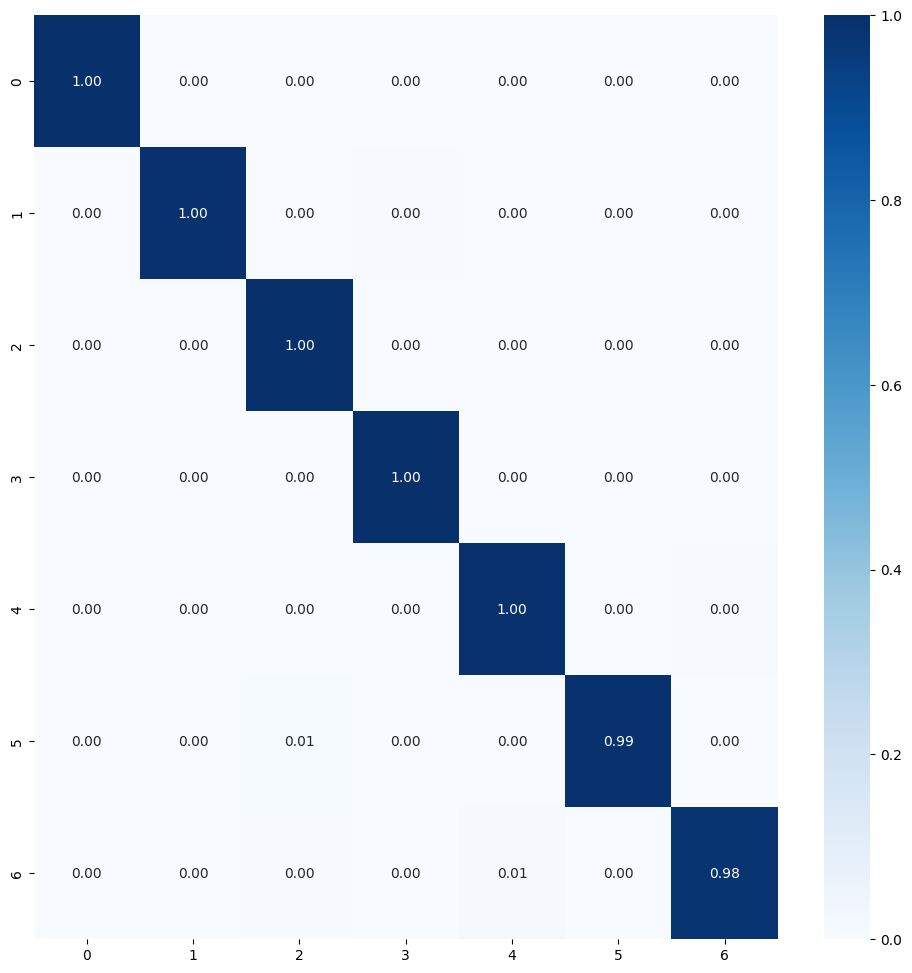


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 47s 163ms/step - loss: 0.0102 - accuracy: 0.9996 - val_loss: 0.0515 - val_accuracy: 0.9923
Epoch 2/50
229/229 [==============================] - 40s 172ms/step - loss: 0.0074 - accuracy: 1.0000 - val_loss: 0.0538 - val_accuracy: 0.9930
Epoch 3/50
229/229 [==============================] - 35s 154ms/step - loss: 0.0062 - accuracy: 1.0000 - val_loss: 0.0468 - val_accuracy: 0.9930
Epoch 4/50
229/229 [==============================] - 36s 158ms/step - loss: 0.0079 - accuracy: 0

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15007_2.pkl
230/230 [==============================] - 25s 106ms/step - loss: 0.0053 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.00531048746779561
50/50 [==============================] - 5s 97ms/step - loss: 0.0434 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.0434146411716938
50/50 [==============================] - 5s 106ms/step - loss: 0.0401 - accuracy: 0.9956
Test Accuracy: 0.995555579662323
Test Log Loss: 0.040084946900606155
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   1   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
          

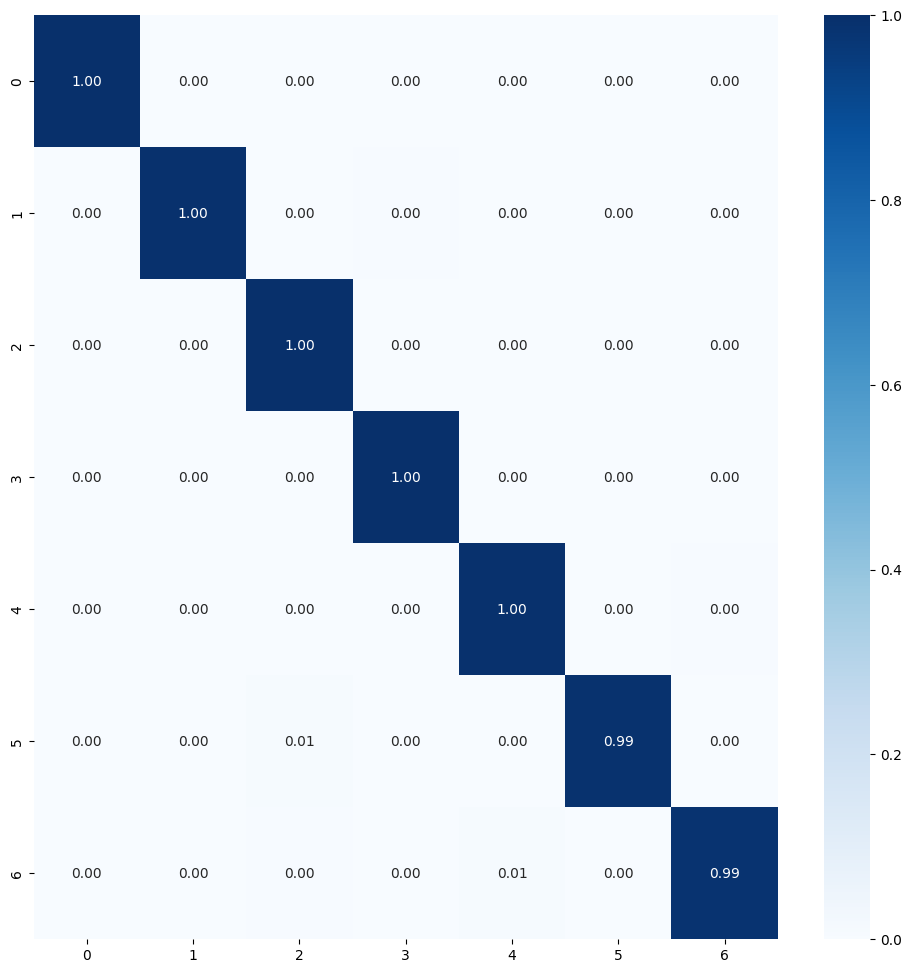


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 49s 177ms/step - loss: 0.0117 - accuracy: 0.9993 - val_loss: 0.0502 - val_accuracy: 0.9936
Epoch 2/50
229/229 [==============================] - 37s 163ms/step - loss: 0.0087 - accuracy: 1.0000 - val_loss: 0.0444 - val_accuracy: 0.9936
Epoch 3/50
229/229 [==============================] - 42s 182ms/step - loss: 0.0112 - accuracy: 0.9993 - val_loss: 0.0486 - val_accuracy: 0.9930
Epoch 4/50
229/229 [==============================] - 39s 170ms/step - loss: 0.0106 - accuracy: 0

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15007_3.pkl
230/230 [==============================] - 32s 132ms/step - loss: 0.0040 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.004042529966682196
50/50 [==============================] - 7s 131ms/step - loss: 0.0449 - accuracy: 0.9943
Validation Accuracy: 0.9942857027053833
Validation Log Loss: 0.044865936040878296
50/50 [==============================] - 7s 135ms/step - loss: 0.0298 - accuracy: 0.9962
Test Accuracy: 0.9961904883384705
Test Log Loss: 0.0297832190990448
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 224   0   1]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   1   0 223]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
      

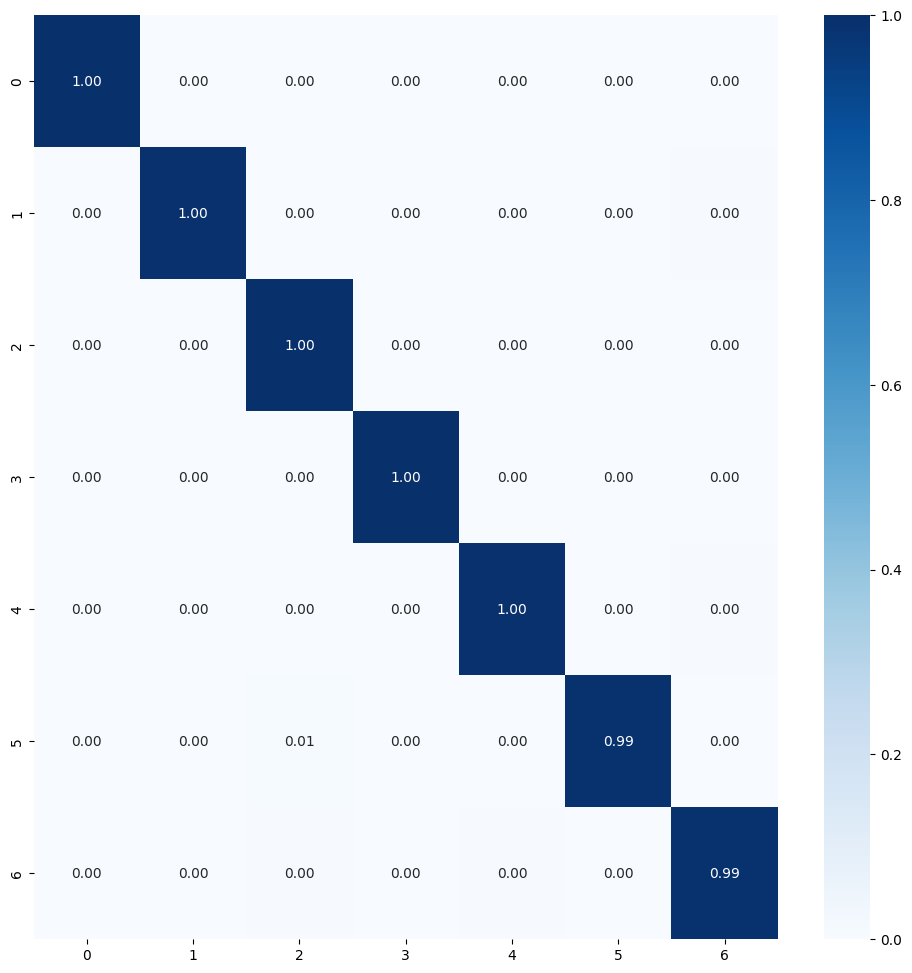


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 51s 178ms/step - loss: 0.0093 - accuracy: 0.9997 - val_loss: 0.0458 - val_accuracy: 0.9936
Epoch 2/50
229/229 [==============================] - 38s 164ms/step - loss: 0.0081 - accuracy: 1.0000 - val_loss: 0.0493 - val_accuracy: 0.9936
Epoch 3/50
229/229 [==============================] - 39s 169ms/step - loss: 0.0108 - accuracy: 0.9986 - val_loss: 0.0573 - val_accuracy: 0.9904
Epoch 4/50
229/229 [==============================] - 39s 171ms/step - loss: 0.0077 - accuracy: 1

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15007_4.pkl
230/230 [==============================] - 31s 135ms/step - loss: 0.0068 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.006773327011615038
50/50 [==============================] - 7s 127ms/step - loss: 0.0470 - accuracy: 0.9949
Validation Accuracy: 0.9949206113815308
Validation Log Loss: 0.04697134718298912
50/50 [==============================] - 7s 136ms/step - loss: 0.0553 - accuracy: 0.9943
Test Accuracy: 0.9942857027053833
Test Log Loss: 0.055259235203266144
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 223   2   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 225   0   0]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   3   0 221]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
     

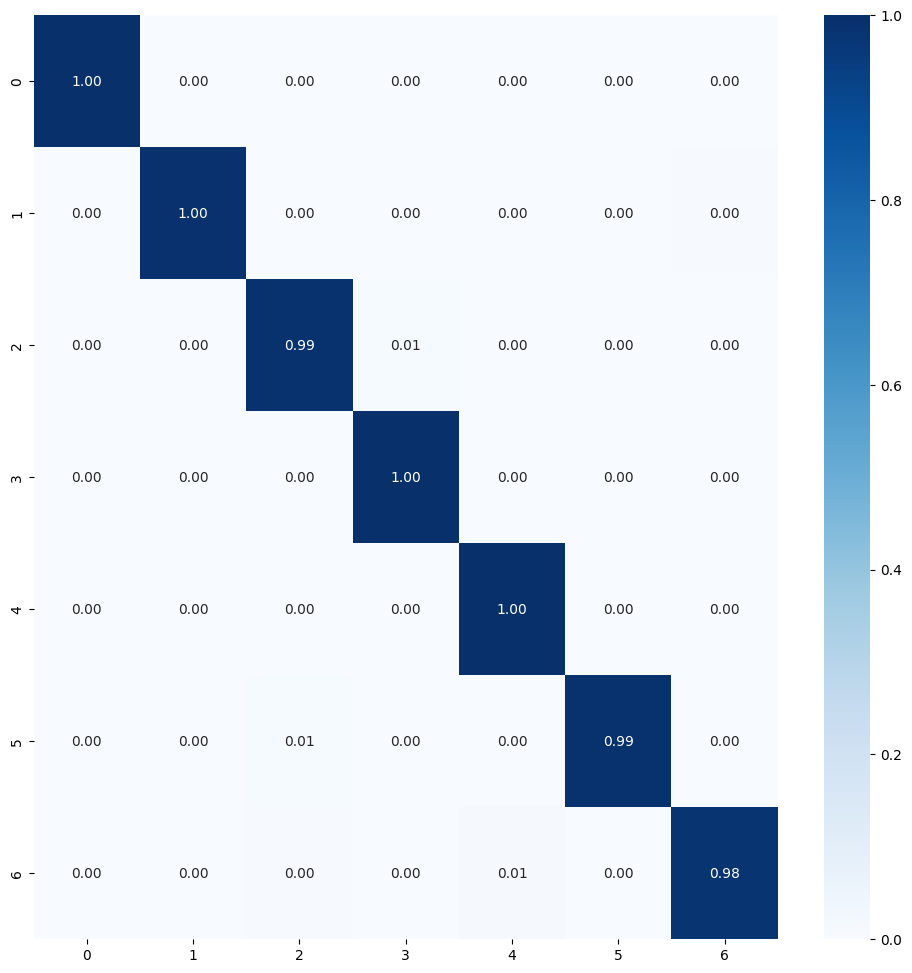


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15007_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_25 - Trainable: True
dropout_50 - Trainable: True
dense_76 - Trainable: True
dropout_51 - Trainable: True
dense_77 - Trainable: True
Epoch 1/50
229/229 [==============================] - 50s 175ms/step - loss: 0.0104 - accuracy: 0.9999 - val_loss: 0.0487 - val_accuracy: 0.9923
Epoch 2/50
229/229 [==============================] - 40s 177ms/step - loss: 0.0087 - accuracy: 1.0000 - val_loss: 0.0512 - val_accuracy: 0.9930
Epoch 3/50
229/229 [==============================] - 36s 151ms/step - loss: 0.0069 - accuracy: 1.0000 - val_loss: 0.0499 - val_accuracy: 0.9936
Epoch 4/50
229/229 [==============================] - 36s 156ms/step - loss: 0.0114 - accuracy: 0

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15007_5.pkl
230/230 [==============================] - 31s 131ms/step - loss: 0.0043 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.004283153917640448
50/50 [==============================] - 7s 139ms/step - loss: 0.0428 - accuracy: 0.9949
Validation Accuracy: 0.9949206113815308
Validation Log Loss: 0.042751092463731766
50/50 [==============================] - 8s 136ms/step - loss: 0.0394 - accuracy: 0.9962
Test Accuracy: 0.9961904883384705
Test Log Loss: 0.039384838193655014
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [  0 224   0   0   0   0   1]
 [  0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0   0 225   0   0]
 [  0   0   2   0   0 223   0]
 [  0   0   1   0   2   0 222]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
    

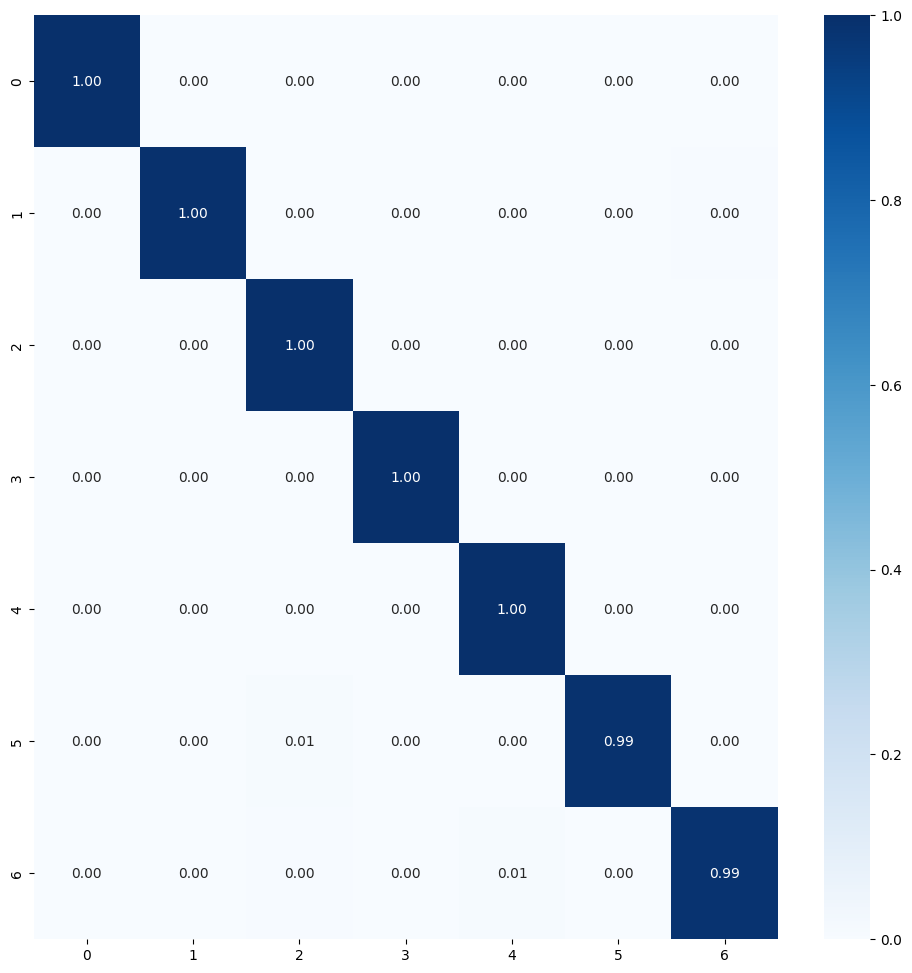


Best fold was 2 with val_accuracy: 0.9955
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9952806234359741

Test Metrics
test_acc_list: [0.9949206113815308, 0.995555579662323, 0.9961904883384705, 0.9942857027053833, 0.9961904883384705]
Average Test Accuracy with 5-fold: 0.9954285740852356
test_loss_list: [0.045120447874069214, 0.040084946900606155, 0.0297832190990448, 0.055259235203266144, 0.039384838193655014]
Average Test Log Loss with 5-fold: 0.04192653745412826

Precision List: [0.9949567089952506, 0.9955833520067481, 0.9962155388471178, 0.994321813112606, 0.9962210325204568]
Average Precision List with 5-fold: 0.9954596890964359
Recall List: [0.994920634920635, 0.9955555555555556, 0.9961904761904764, 0.9942857142857143, 0.9961904761904762]
Average Recall List with 5-fold: 0.9954285714285713
F1 Score List: [0.9949190702126073, 0.9955554678868229, 0.9961932418434122, 0.9942841558069179, 0.9961903822925121]
Average F1 Score List with 5-fold: 0.9954

In [21]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: MobileNet_tf_15008
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 61s 181ms/step - loss: 0.0087 - accuracy: 0.9996 - val_loss: 0.0368 - val_accuracy: 0.9950
Epoch 2/50
262/262 [===========

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15008_1.pkl
263/263 [==============================] - 37s 141ms/step - loss: 0.0061 - accuracy: 0.9999
Train Accuracy: 0.9998809695243835
Train Log Loss: 0.006136121228337288
57/57 [==============================] - 9s 136ms/step - loss: 0.0554 - accuracy: 0.9889
Validation Accuracy: 0.9888888597488403
Validation Log Loss: 0.05541517212986946
57/57 [==============================] - 8s 130ms/step - loss: 0.0513 - accuracy: 0.9928
Test Accuracy: 0.9927777647972107
Test Log Loss: 0.051294438540935516
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   8   0 21

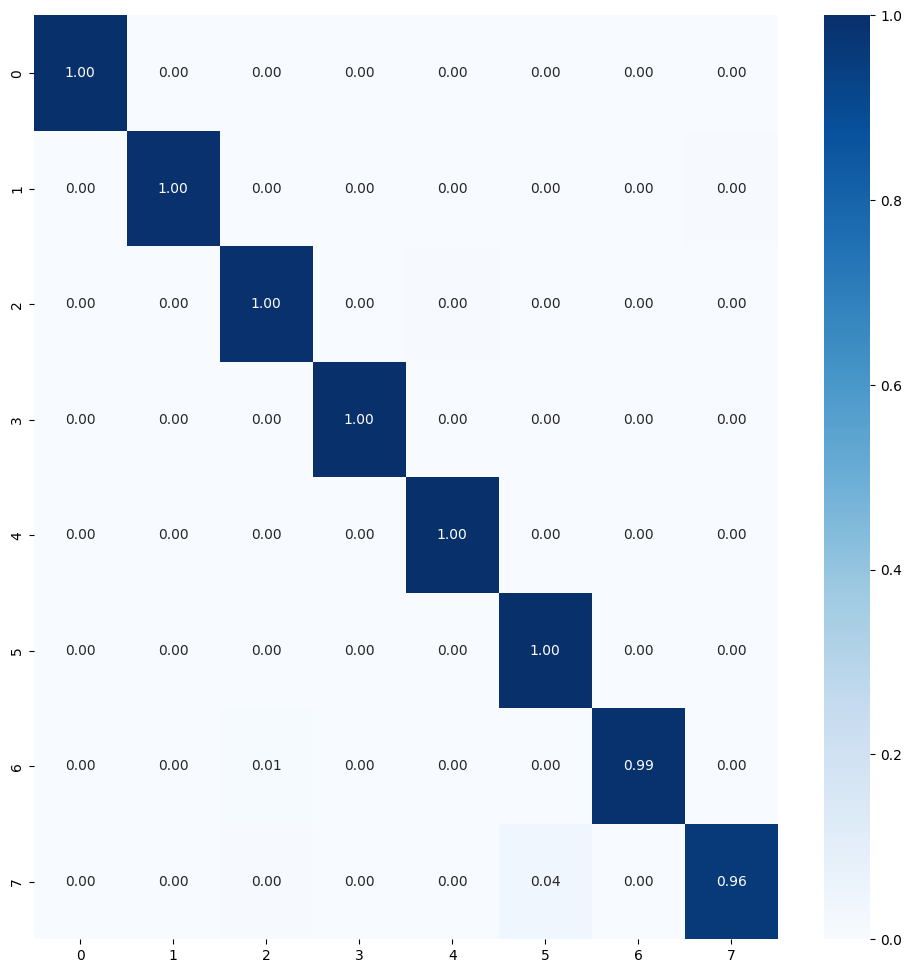


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 56s 171ms/step - loss: 0.0098 - accuracy: 0.9994 - val_loss: 0.0363 - val_accuracy: 0.9939
Epoch 2/50
262/262 [==============================] - 42s 160ms/step - loss: 0.0094 - accuracy: 0.9993 - val_loss: 0.0457 - val_accuracy: 0.9900
Epoch 3/50
262/262 [==============================] - 42s 160ms/step - loss: 0.0100 - accuracy: 0.9994 - val_loss: 0.0476 - val_accuracy: 0.9916
Epoch 4/50
262/262 [==============================] - 44s 164ms/step - loss: 0.0076 - accuracy: 1

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15008_2.pkl
263/263 [==============================] - 21s 80ms/step - loss: 0.0053 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005278761498630047
57/57 [==============================] - 6s 102ms/step - loss: 0.0468 - accuracy: 0.9944
Validation Accuracy: 0.9944444298744202
Validation Log Loss: 0.04676072299480438
57/57 [==============================] - 5s 84ms/step - loss: 0.0468 - accuracy: 0.9944
Test Accuracy: 0.9944444298744202
Test Log Loss: 0.046767186373472214
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   5   0 219]]
True labels: 

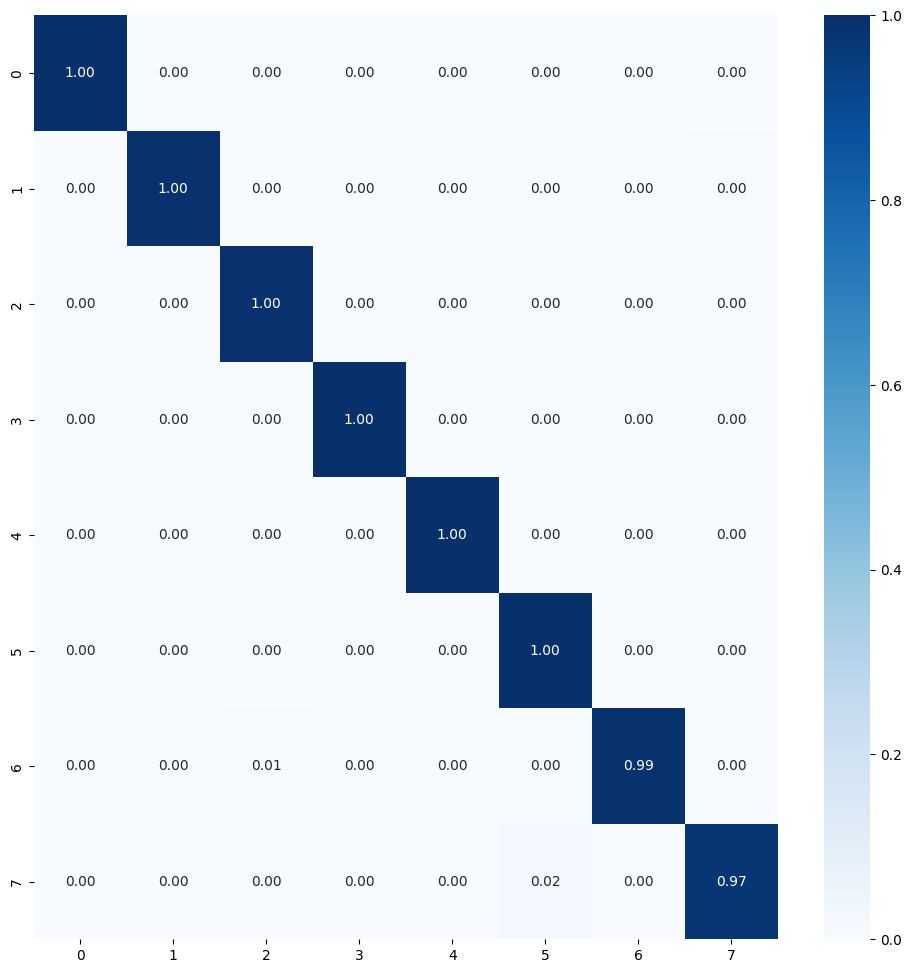


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 32s 103ms/step - loss: 0.0087 - accuracy: 0.9996 - val_loss: 0.0508 - val_accuracy: 0.9877
Epoch 2/50
262/262 [==============================] - 30s 115ms/step - loss: 0.0123 - accuracy: 0.9984 - val_loss: 0.0528 - val_accuracy: 0.9888
Epoch 3/50
262/262 [==============================] - 34s 131ms/step - loss: 0.0081 - accuracy: 1.0000 - val_loss: 0.0366 - val_accuracy: 0.9955
Epoch 4/50
262/262 [==============================] - 34s 131ms/step - loss: 0.0068 - accuracy: 1

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15008_3.pkl
263/263 [==============================] - 42s 159ms/step - loss: 0.0056 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005614614114165306
57/57 [==============================] - 10s 157ms/step - loss: 0.0415 - accuracy: 0.9939
Validation Accuracy: 0.9938889145851135
Validation Log Loss: 0.04153827950358391
57/57 [==============================] - 9s 151ms/step - loss: 0.0359 - accuracy: 0.9961
Test Accuracy: 0.9961110949516296
Test Log Loss: 0.03593074902892113
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   2   0 222]]
True labels

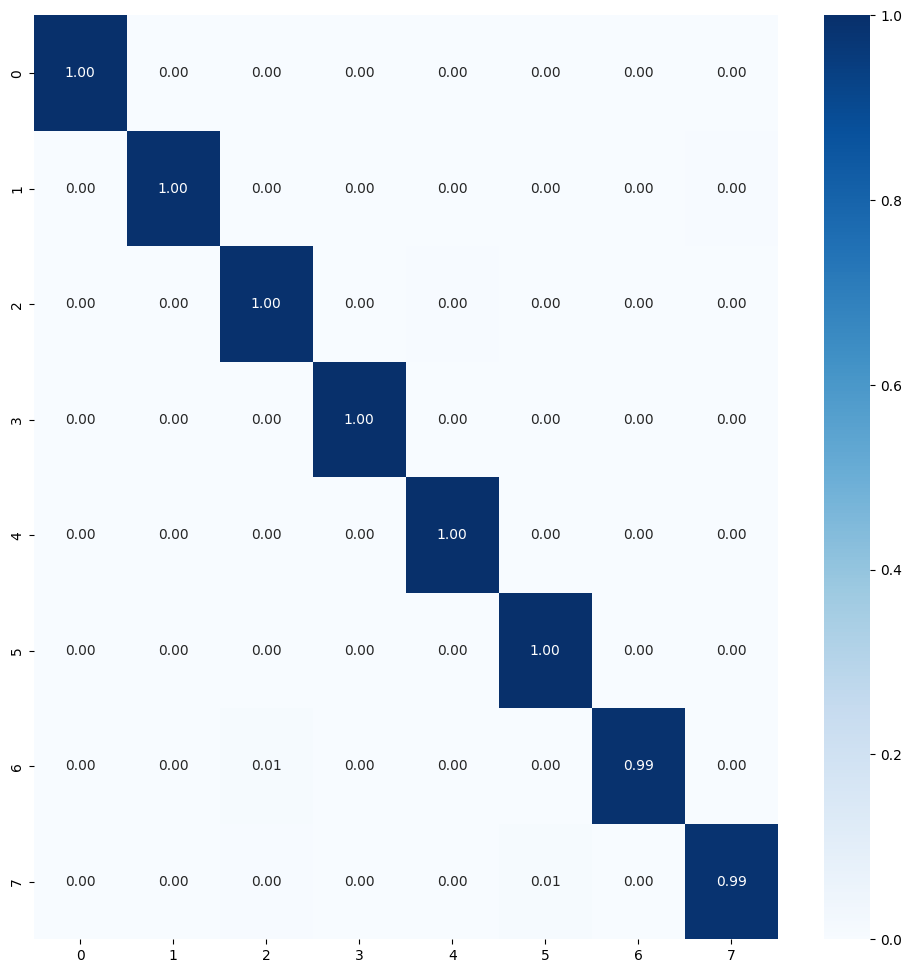


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 61s 189ms/step - loss: 0.0100 - accuracy: 0.9996 - val_loss: 0.0415 - val_accuracy: 0.9927
Epoch 2/50
262/262 [==============================] - 46s 174ms/step - loss: 0.0094 - accuracy: 0.9996 - val_loss: 0.0372 - val_accuracy: 0.9950
Epoch 3/50
262/262 [==============================] - 47s 177ms/step - loss: 0.0093 - accuracy: 0.9994 - val_loss: 0.0371 - val_accuracy: 0.9950
Epoch 4/50
262/262 [==============================] - 47s 178ms/step - loss: 0.0093 - accuracy: 1

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15008_4.pkl
263/263 [==============================] - 34s 127ms/step - loss: 0.0068 - accuracy: 0.9999
Train Accuracy: 0.9998809695243835
Train Log Loss: 0.006806199438869953
57/57 [==============================] - 8s 141ms/step - loss: 0.0484 - accuracy: 0.9928
Validation Accuracy: 0.9927777647972107
Validation Log Loss: 0.04842861741781235
57/57 [==============================] - 8s 126ms/step - loss: 0.0526 - accuracy: 0.9950
Test Accuracy: 0.9950000047683716
Test Log Loss: 0.05257108807563782
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 224   0   1   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   4   0 220

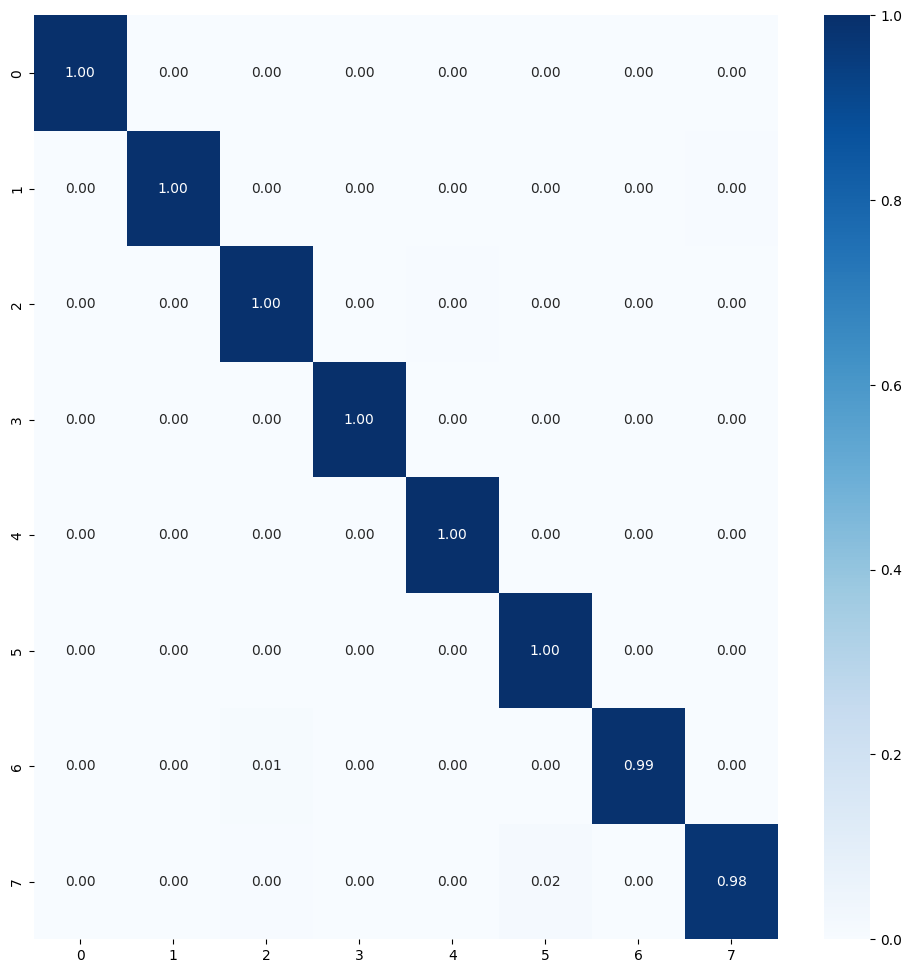


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15008_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_30 - Trainable: True
dropout_60 - Trainable: True
dense_91 - Trainable: True
dropout_61 - Trainable: True
dense_92 - Trainable: True
Epoch 1/50
262/262 [==============================] - 47s 150ms/step - loss: 0.0085 - accuracy: 1.0000 - val_loss: 0.0393 - val_accuracy: 0.9950
Epoch 2/50
262/262 [==============================] - 32s 120ms/step - loss: 0.0075 - accuracy: 0.9996 - val_loss: 0.0441 - val_accuracy: 0.9933
Epoch 3/50
262/262 [==============================] - 42s 157ms/step - loss: 0.0147 - accuracy: 0.9984 - val_loss: 0.0440 - val_accuracy: 0.9944
Epoch 4/50
262/262 [==============================] - 40s 150ms/step - loss: 0.0114 - accuracy: 0

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15008_5.pkl
263/263 [==============================] - 36s 137ms/step - loss: 0.0037 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0036638854071497917
57/57 [==============================] - 8s 138ms/step - loss: 0.0370 - accuracy: 0.9950
Validation Accuracy: 0.9950000047683716
Validation Log Loss: 0.03701705485582352
57/57 [==============================] - 8s 140ms/step - loss: 0.0406 - accuracy: 0.9961
Test Accuracy: 0.9961110949516296
Test Log Loss: 0.040585801005363464
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   1]
 [  0   0 225   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0]
 [  0   0   0   0   0 224   0   1]
 [  0   0   2   0   0   0 223   0]
 [  0   0   1   0   0   2   0 222]]
True label

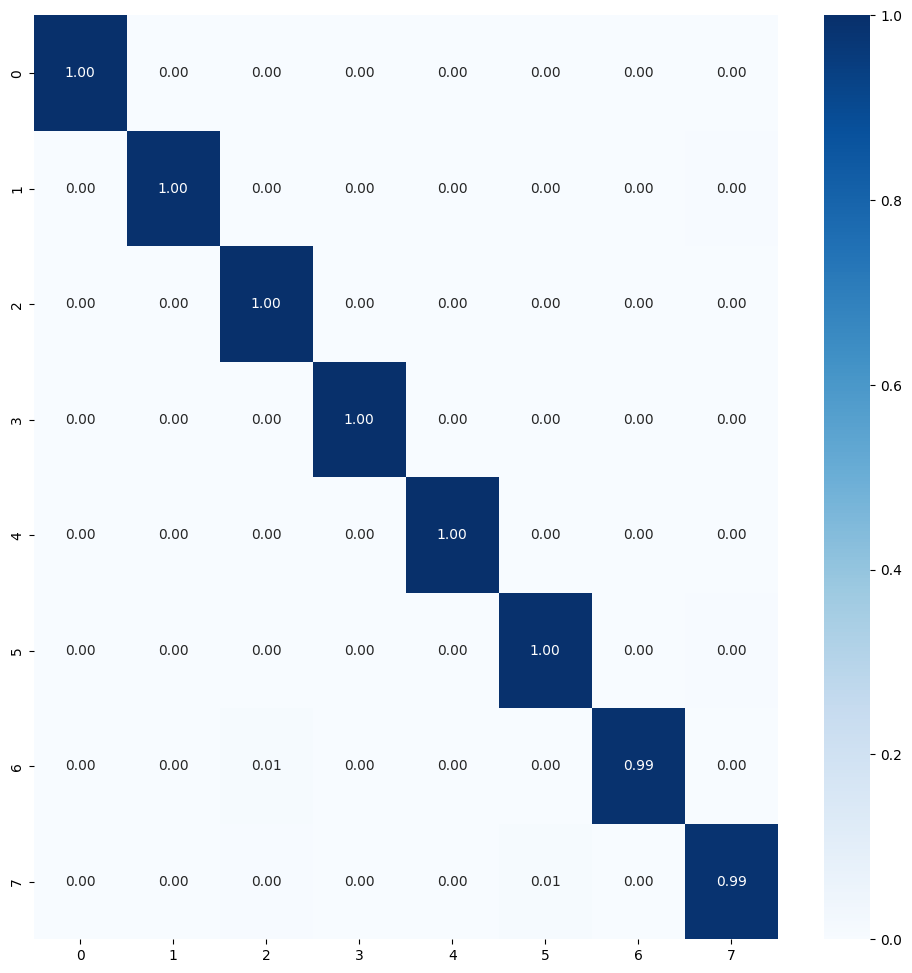


Best fold was 4 with val_accuracy: 0.9961
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9957589387893677

Test Metrics
test_acc_list: [0.9927777647972107, 0.9944444298744202, 0.9961110949516296, 0.9950000047683716, 0.9961110949516296]
Average Test Accuracy with 5-fold: 0.9948888778686523
test_loss_list: [0.051294438540935516, 0.046767186373472214, 0.03593074902892113, 0.05257108807563782, 0.040585801005363464]
Average Test Log Loss with 5-fold: 0.045429852604866025

Precision List: [0.992927037916091, 0.9945093471534829, 0.9961330605735177, 0.995045903302747, 0.9961329970390578]
Average Precision List with 5-fold: 0.9949496691969791
Recall List: [0.9927777777777778, 0.9944444444444445, 0.9961111111111112, 0.995, 0.9961111111111112]
Average Recall List with 5-fold: 0.9948888888888889
F1 Score List: [0.9927687508842158, 0.9944402927879377, 0.9961110425226913, 0.9949972753607166, 0.9961122855094411]
Average F1 Score List with 5-fold: 0.994885929413000

In [22]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: MobileNet_tf_15009
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_38 - Trainable: True
dropout_76 - Trainable: True
dense_115 - Trainable: True
dropout_77 - Trainable: True
dense_116 - Trainable: True
Epoch 1/50
295/295 [==============================] - 64s 174ms/step - loss: 0.0076 - accuracy: 0.9996 - val_loss: 0.0336 - val_accuracy: 0.9936
Epoch 2/50
295/29

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15009_1.pkl
296/296 [==============================] - 43s 144ms/step - loss: 0.0058 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.005849532783031464
64/64 [==============================] - 9s 140ms/step - loss: 0.0478 - accuracy: 0.9931
Validation Accuracy: 0.9930863976478577
Validation Log Loss: 0.0477975457906723
64/64 [==============================] - 10s 141ms/step - loss: 0.0468 - accuracy: 0.9936
Test Accuracy: 0.9935802221298218
Test Log Loss: 0.04679888114333153
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 223   2   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  

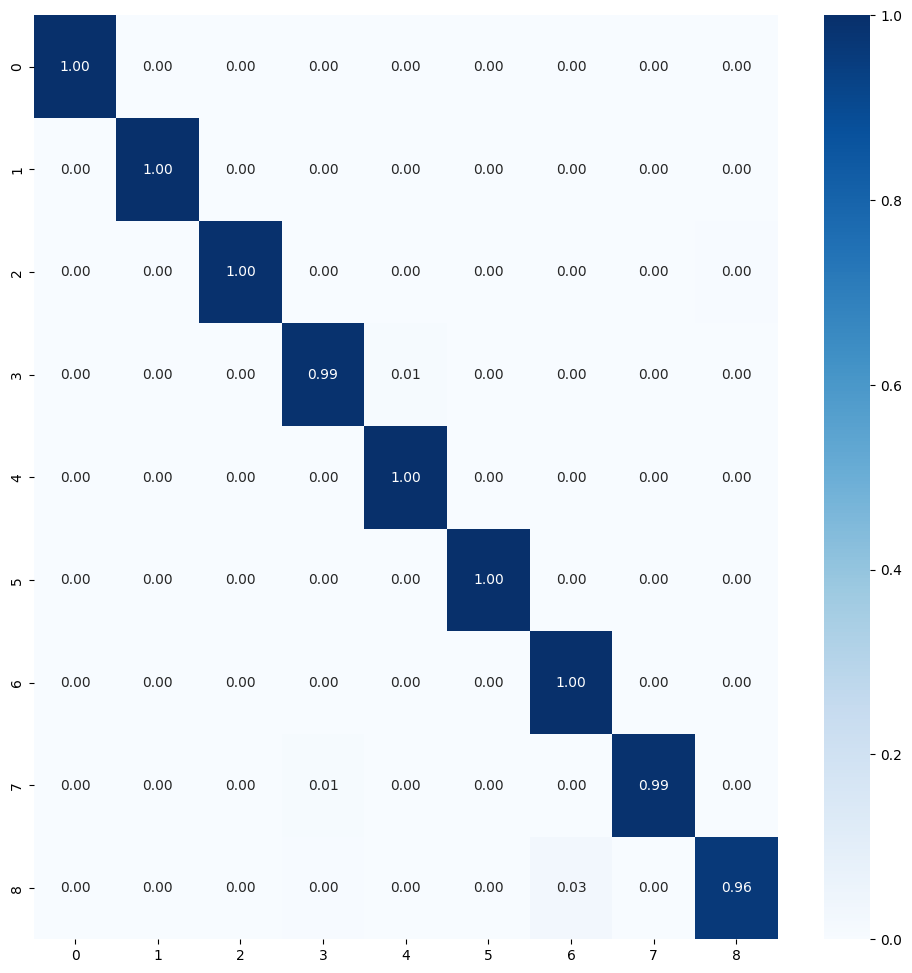


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_38 - Trainable: True
dropout_76 - Trainable: True
dense_115 - Trainable: True
dropout_77 - Trainable: True
dense_116 - Trainable: True
Epoch 1/50
295/295 [==============================] - 65s 183ms/step - loss: 0.0069 - accuracy: 0.9996 - val_loss: 0.0583 - val_accuracy: 0.9871
Epoch 2/50
295/295 [==============================] - 52s 175ms/step - loss: 0.0069 - accuracy: 0.9996 - val_loss: 0.0333 - val_accuracy: 0.9950
Epoch 3/50
295/295 [==============================] - 52s 172ms/step - loss: 0.0057 - accuracy: 1.0000 - val_loss: 0.0294 - val_accuracy: 0.9955
Epoch 4/50
295/295 [==============================] - 48s 163ms/step - loss: 0.0047 - accuracy:

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15009_2.pkl
296/296 [==============================] - 32s 105ms/step - loss: 0.0018 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0018033700762316585
64/64 [==============================] - 4s 56ms/step - loss: 0.0298 - accuracy: 0.9960
Validation Accuracy: 0.9960494041442871
Validation Log Loss: 0.029847532510757446
64/64 [==============================] - 4s 59ms/step - loss: 0.0300 - accuracy: 0.9965
Test Accuracy: 0.9965432286262512
Test Log Loss: 0.029985196888446808
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [ 

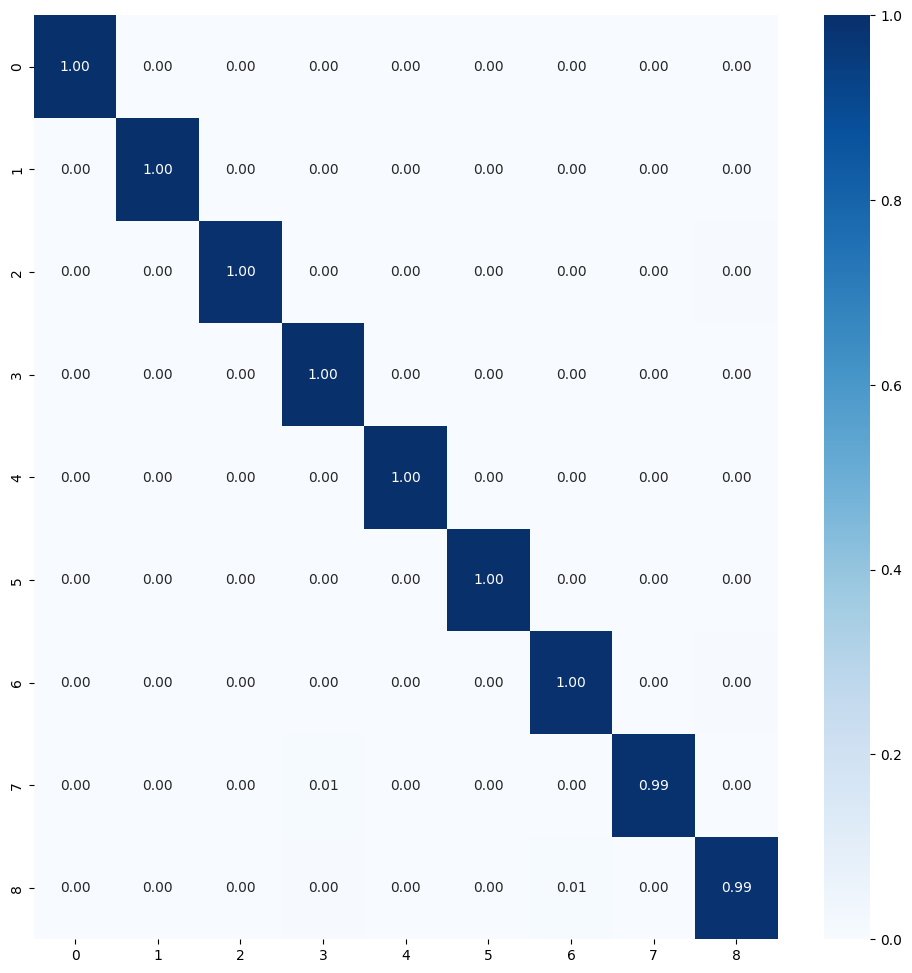


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_38 - Trainable: True
dropout_76 - Trainable: True
dense_115 - Trainable: True
dropout_77 - Trainable: True
dense_116 - Trainable: True
Epoch 1/50
295/295 [==============================] - 25s 75ms/step - loss: 0.0069 - accuracy: 0.9997 - val_loss: 0.0334 - val_accuracy: 0.9955
Epoch 2/50
295/295 [==============================] - 22s 74ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0376 - val_accuracy: 0.9936
Epoch 3/50
295/295 [==============================] - 22s 73ms/step - loss: 0.0044 - accuracy: 1.0000 - val_loss: 0.0335 - val_accuracy: 0.9950
Epoch 4/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0035 - accuracy: 1.0

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15009_3.pkl
296/296 [==============================] - 18s 61ms/step - loss: 0.0028 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0028281158301979303
64/64 [==============================] - 4s 58ms/step - loss: 0.0404 - accuracy: 0.9931
Validation Accuracy: 0.9930863976478577
Validation Log Loss: 0.040356434881687164
64/64 [==============================] - 4s 57ms/step - loss: 0.0256 - accuracy: 0.9951
Test Accuracy: 0.9950617551803589
Test Log Loss: 0.025624603033065796
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 223   2   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  

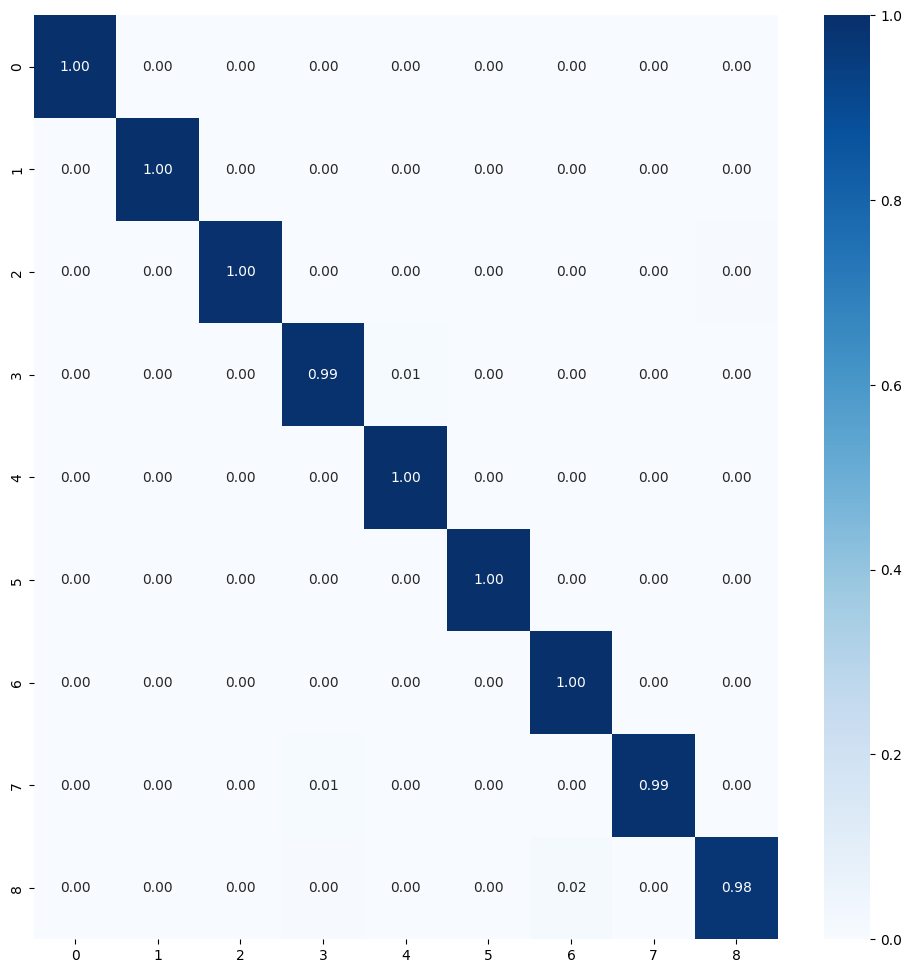


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_38 - Trainable: True
dropout_76 - Trainable: True
dense_115 - Trainable: True
dropout_77 - Trainable: True
dense_116 - Trainable: True
Epoch 1/50
295/295 [==============================] - 27s 76ms/step - loss: 0.0063 - accuracy: 1.0000 - val_loss: 0.0311 - val_accuracy: 0.9955
Epoch 2/50
295/295 [==============================] - 22s 75ms/step - loss: 0.0046 - accuracy: 1.0000 - val_loss: 0.0298 - val_accuracy: 0.9955
Epoch 3/50
295/295 [==============================] - 21s 70ms/step - loss: 0.0111 - accuracy: 0.9988 - val_loss: 0.0330 - val_accuracy: 0.9945
Epoch 4/50
295/295 [==============================] - 22s 74ms/step - loss: 0.0083 - accuracy: 0.9

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15009_4.pkl
296/296 [==============================] - 18s 60ms/step - loss: 0.0034 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0034067772794514894
64/64 [==============================] - 4s 59ms/step - loss: 0.0291 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.029062550514936447
64/64 [==============================] - 4s 59ms/step - loss: 0.0274 - accuracy: 0.9965
Test Accuracy: 0.9965432286262512
Test Log Loss: 0.027376389130949974
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 224   0   1]
 [  0

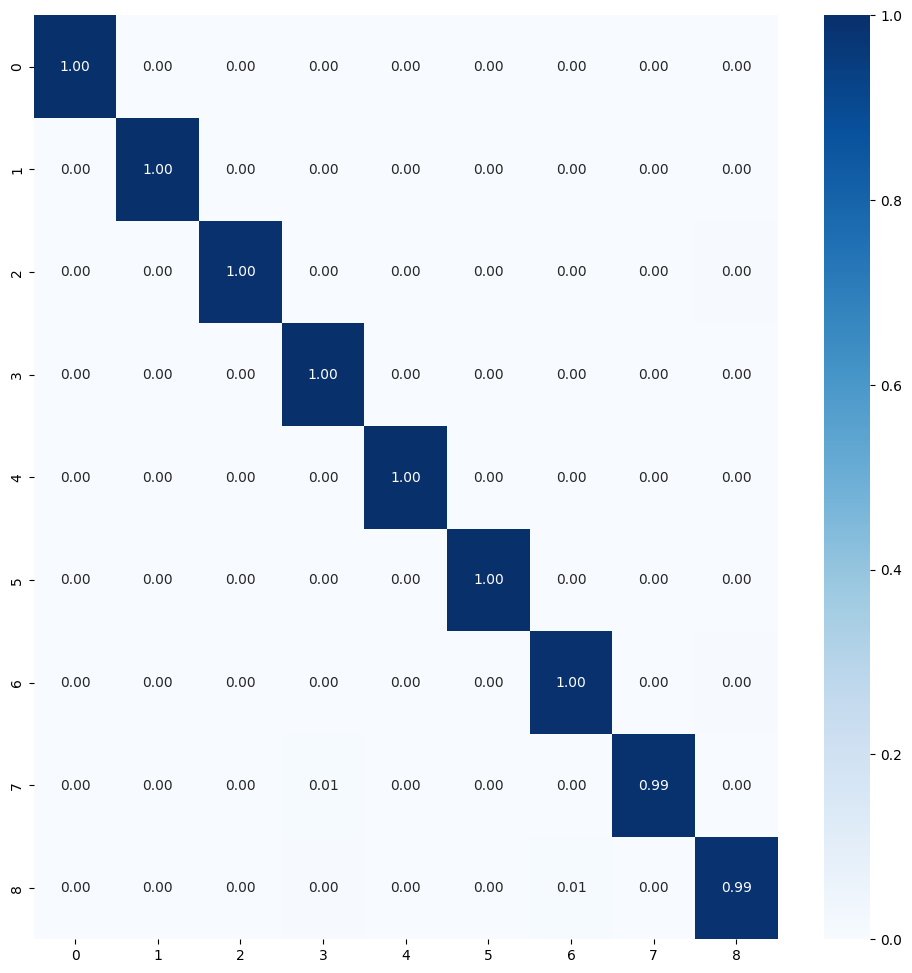


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_15009_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_38 - Trainable: True
dropout_76 - Trainable: True
dense_115 - Trainable: True
dropout_77 - Trainable: True
dense_116 - Trainable: True
Epoch 1/50
295/295 [==============================] - 26s 77ms/step - loss: 0.0067 - accuracy: 0.9998 - val_loss: 0.0720 - val_accuracy: 0.9866
Epoch 2/50
295/295 [==============================] - 21s 73ms/step - loss: 0.0087 - accuracy: 0.9995 - val_loss: 0.0362 - val_accuracy: 0.9945
Epoch 3/50
295/295 [==============================] - 21s 72ms/step - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.0365 - val_accuracy: 0.9945
Epoch 4/50
295/295 [==============================] - 22s 73ms/step - loss: 0.0067 - accuracy: 0.9

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_15009_5.pkl
296/296 [==============================] - 18s 60ms/step - loss: 0.0019 - accuracy: 1.0000
Train Accuracy: 1.0
Train Log Loss: 0.0019141884986311197
64/64 [==============================] - 4s 60ms/step - loss: 0.0292 - accuracy: 0.9956
Validation Accuracy: 0.995555579662323
Validation Log Loss: 0.029200447723269463
64/64 [==============================] - 4s 60ms/step - loss: 0.0278 - accuracy: 0.9965
Test Accuracy: 0.9965432286262512
Test Log Loss: 0.027841534465551376
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1]
 [  0   0   0 225   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 225   0   0]
 [  0

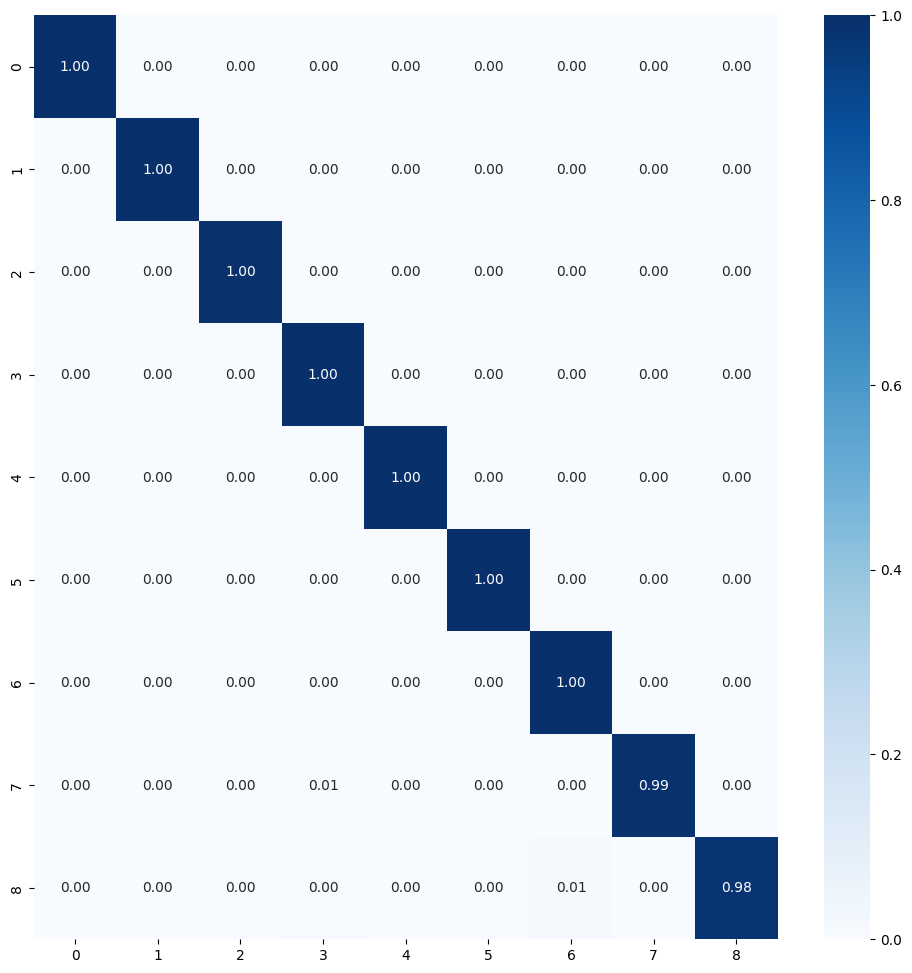


Best fold was 1 with val_accuracy: 0.9975
Average training accuracy in 5-fold: 1.0
Average validation precision in 5-fold: 0.9968254089355468

Test Metrics
test_acc_list: [0.9935802221298218, 0.9965432286262512, 0.9950617551803589, 0.9965432286262512, 0.9965432286262512]
Average Test Accuracy with 5-fold: 0.9956543326377869
test_loss_list: [0.04679888114333153, 0.029985196888446808, 0.025624603033065796, 0.027376389130949974, 0.027841534465551376]
Average Test Log Loss with 5-fold: 0.0315253209322691

Precision List: [0.9936839468081313, 0.996562664034718, 0.9951025505826071, 0.996562664034718, 0.9965755228913125]
Average Precision List with 5-fold: 0.9956974696702974
Recall List: [0.9935802469135803, 0.9965432098765432, 0.9950617283950618, 0.9965432098765432, 0.9965432098765432]
Average Recall List with 5-fold: 0.9956543209876543
F1 Score List: [0.9935737750879137, 0.9965442537861698, 0.9950593113384342, 0.9965442537861698, 0.996541980817145]
Average F1 Score List with 5-fold: 0.9956

In [23]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: MobileNet_tf_150010
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 29s 77ms/step - loss: 0.0457 - accuracy: 0.9966 - val_loss: 0.2219 - val_accuracy: 0.9688
Epoch 2/50


History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150010_1.pkl
329/329 [==============================] - 20s 61ms/step - loss: 0.0117 - accuracy: 0.9998
Train Accuracy: 0.9998095035552979
Train Log Loss: 0.011734480038285255
71/71 [==============================] - 4s 60ms/step - loss: 0.1777 - accuracy: 0.9702
Validation Accuracy: 0.9702222347259521
Validation Log Loss: 0.1777195930480957
71/71 [==============================] - 5s 63ms/step - loss: 0.1583 - accuracy: 0.9724
Test Accuracy: 0.9724444150924683
Test Log Loss: 0.1582566797733307
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[224   0   0   0   0   0   0   0   0   1]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 222   0   0   1   0   0   2]
 [  0   0   0   0 214   0   0   0   0  11]
 [  0   0   0   0   0 225   0   0   0

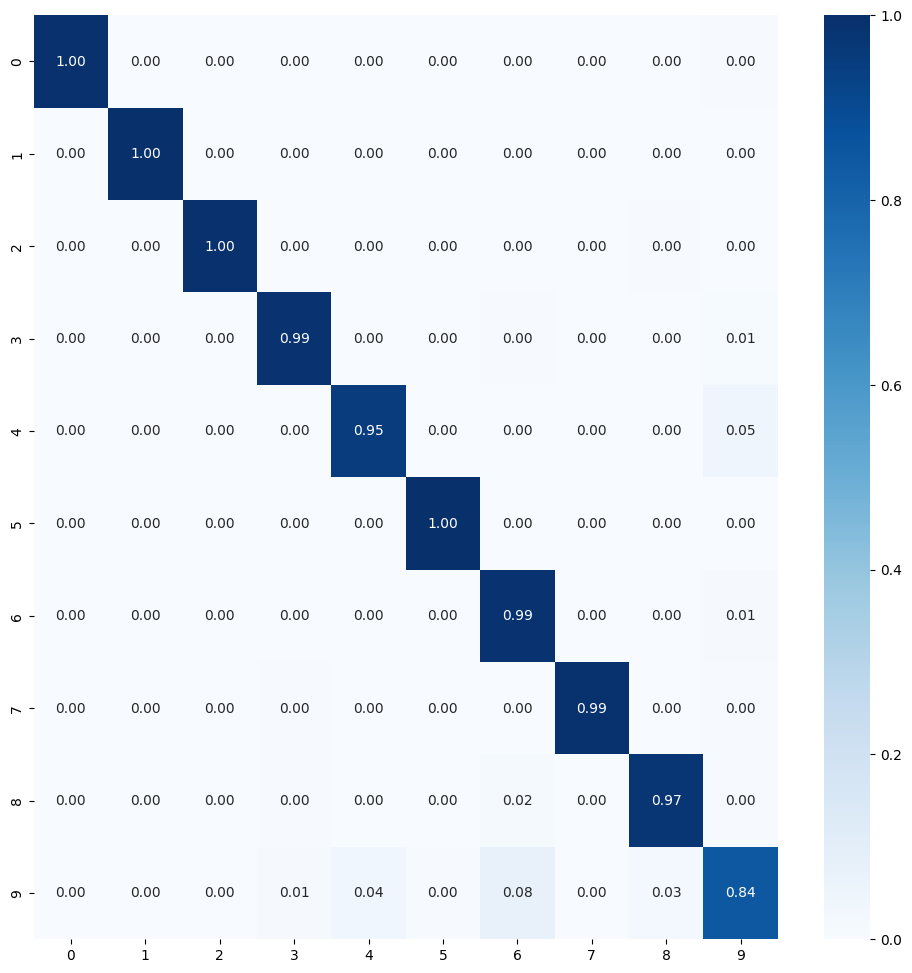


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 28s 75ms/step - loss: 0.0430 - accuracy: 0.9968 - val_loss: 0.3358 - val_accuracy: 0.9621
Epoch 2/50
328/328 [==============================] - 24s 73ms/step - loss: 0.0408 - accuracy: 0.9973 - val_loss: 0.2537 - val_accuracy: 0.9674
Epoch 3/50
328/328 [==============================] - 25s 73ms/step - loss: 0.0381 - accuracy: 0.9978 - val_loss: 0.1823 - val_accuracy: 0.9696
Epoch 4/50
328/328 [==============================] - 25s 76ms/step - loss: 0.0348 - accuracy: 0.9983 - val

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150010_2.pkl
329/329 [==============================] - 20s 60ms/step - loss: 0.0128 - accuracy: 0.9995
Train Accuracy: 0.9995238184928894
Train Log Loss: 0.012838746421039104
71/71 [==============================] - 5s 61ms/step - loss: 0.1809 - accuracy: 0.9684
Validation Accuracy: 0.9684444665908813
Validation Log Loss: 0.1808958351612091
71/71 [==============================] - 4s 61ms/step - loss: 0.1610 - accuracy: 0.9707
Test Accuracy: 0.9706666469573975
Test Log Loss: 0.1610097587108612
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 219   0   0   0   0   6]
 [  0   0   0   0   0 225   0   0   0

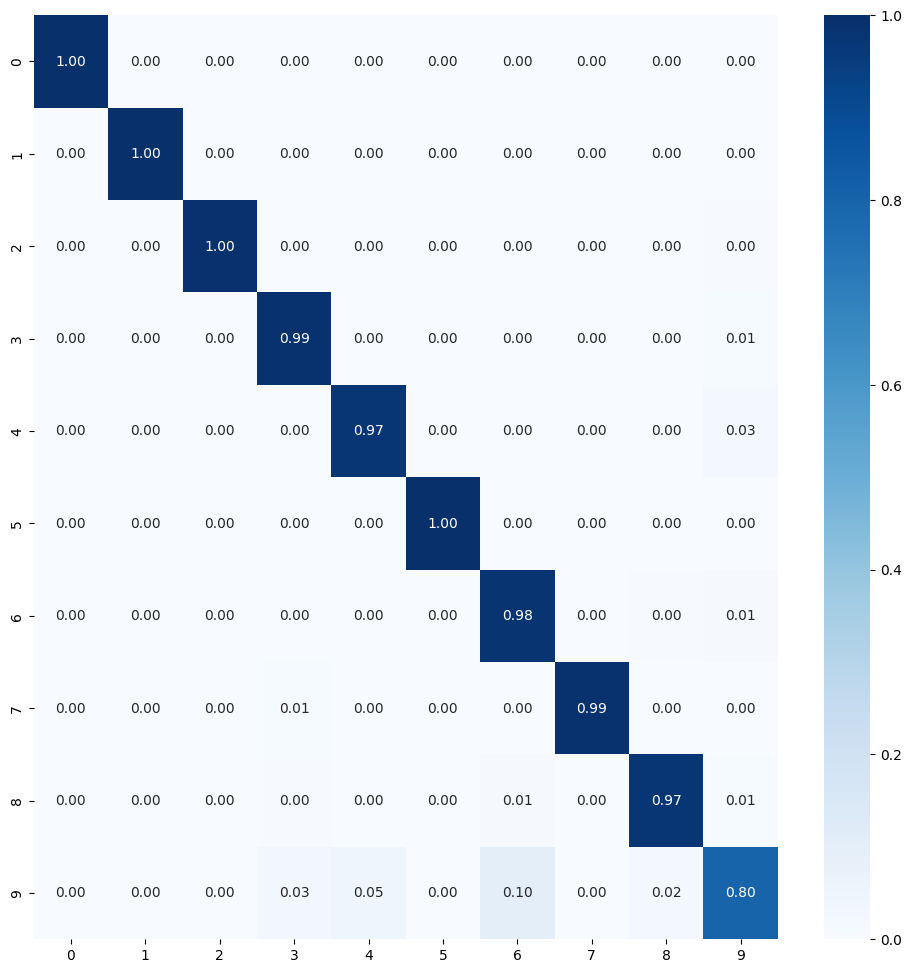


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 29s 77ms/step - loss: 0.0454 - accuracy: 0.9966 - val_loss: 0.2204 - val_accuracy: 0.9638
Epoch 2/50
328/328 [==============================] - 24s 74ms/step - loss: 0.0394 - accuracy: 0.9982 - val_loss: 0.2276 - val_accuracy: 0.9571
Epoch 3/50
328/328 [==============================] - 25s 74ms/step - loss: 0.0413 - accuracy: 0.9971 - val_loss: 0.1958 - val_accuracy: 0.9656
Epoch 4/50
328/328 [==============================] - 24s 74ms/step - loss: 0.0368 - accuracy: 0.9978 - val

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150010_3.pkl
329/329 [==============================] - 20s 61ms/step - loss: 0.0244 - accuracy: 0.9945
Train Accuracy: 0.9944761991500854
Train Log Loss: 0.024417933076620102
71/71 [==============================] - 4s 59ms/step - loss: 0.2215 - accuracy: 0.9667
Validation Accuracy: 0.9666666388511658
Validation Log Loss: 0.2214612066745758
71/71 [==============================] - 4s 61ms/step - loss: 0.2306 - accuracy: 0.9684
Test Accuracy: 0.9684444665908813
Test Log Loss: 0.2305552363395691
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 221   0   1   0   0   0   3]
 [  0   0   0   0 215   0   0   0   0  10]
 [  0   0   0   0   0 225   0   0   0

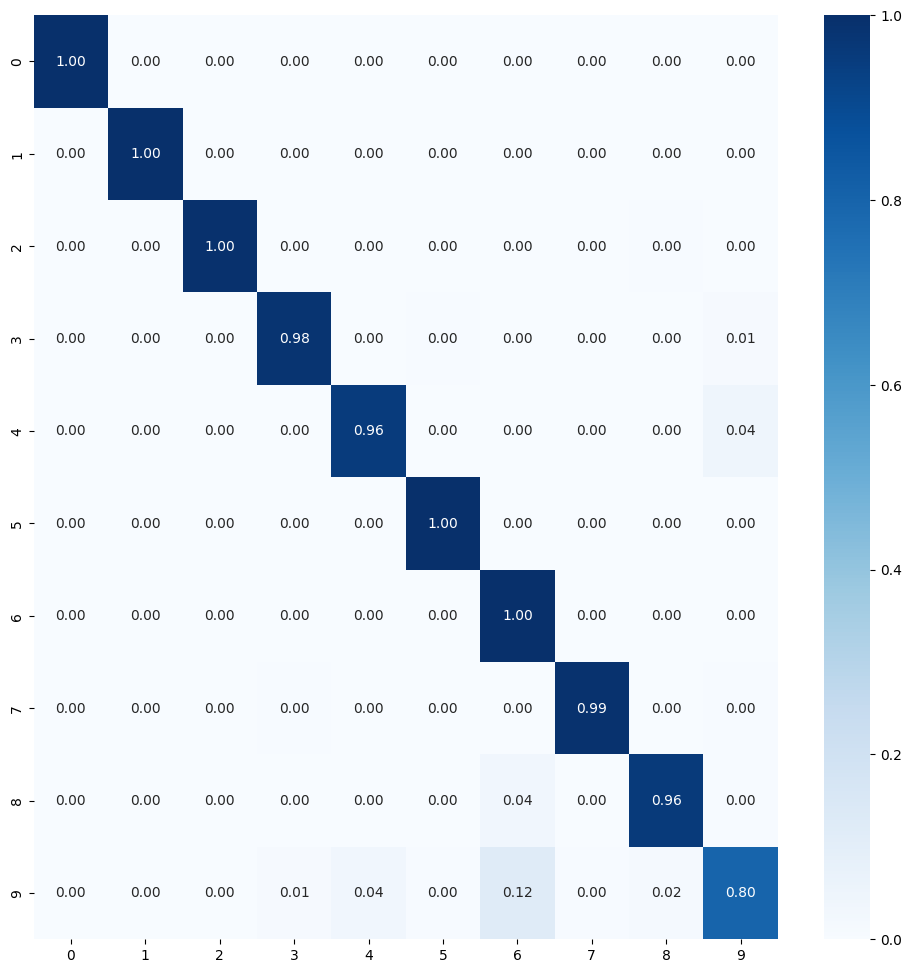


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 29s 78ms/step - loss: 0.0433 - accuracy: 0.9969 - val_loss: 0.1958 - val_accuracy: 0.9670
Epoch 2/50
328/328 [==============================] - 24s 73ms/step - loss: 0.0397 - accuracy: 0.9972 - val_loss: 0.2387 - val_accuracy: 0.9594
Epoch 3/50
328/328 [==============================] - 24s 73ms/step - loss: 0.0428 - accuracy: 0.9964 - val_loss: 0.1751 - val_accuracy: 0.9683
Epoch 4/50
328/328 [==============================] - 25s 74ms/step - loss: 0.0331 - accuracy: 0.9989 - val

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150010_4.pkl
329/329 [==============================] - 20s 61ms/step - loss: 0.0105 - accuracy: 0.9999
Train Accuracy: 0.9999047517776489
Train Log Loss: 0.010525812394917011
71/71 [==============================] - 4s 61ms/step - loss: 0.1839 - accuracy: 0.9720
Validation Accuracy: 0.972000002861023
Validation Log Loss: 0.18385550379753113
71/71 [==============================] - 4s 58ms/step - loss: 0.1670 - accuracy: 0.9711
Test Accuracy: 0.9711111187934875
Test Log Loss: 0.16696380078792572
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 217   0   0   0   0   8]
 [  0   0   0   0   0 224   0   0   

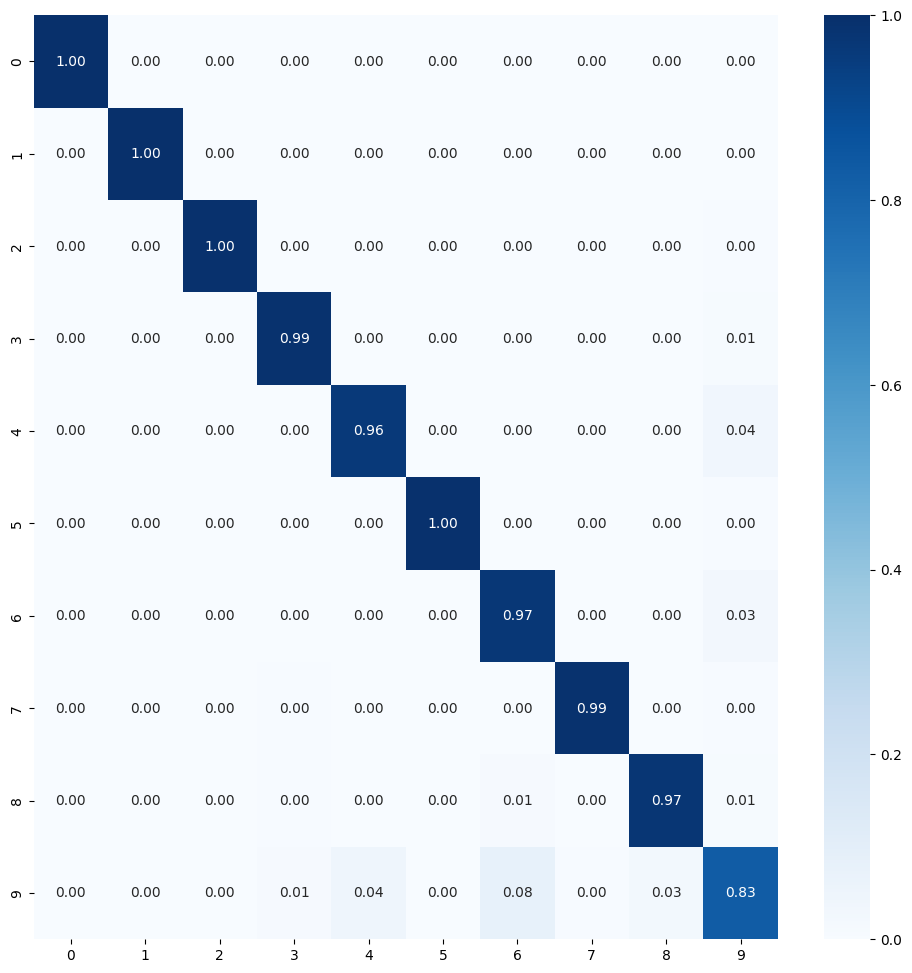


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150010_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True
dropout_1 - Trainable: True
dense_2 - Trainable: True
Epoch 1/50
328/328 [==============================] - 27s 74ms/step - loss: 0.0423 - accuracy: 0.9978 - val_loss: 0.1891 - val_accuracy: 0.9701
Epoch 2/50
328/328 [==============================] - 24s 73ms/step - loss: 0.0423 - accuracy: 0.9970 - val_loss: 0.1990 - val_accuracy: 0.9661
Epoch 3/50
328/328 [==============================] - 25s 77ms/step - loss: 0.0367 - accuracy: 0.9985 - val_loss: 0.1728 - val_accuracy: 0.9714
Epoch 4/50
328/328 [==============================] - 25s 75ms/step - loss: 0.0358 - accuracy: 0.9980 - val

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150010_5.pkl
329/329 [==============================] - 20s 58ms/step - loss: 0.0152 - accuracy: 0.9990
Train Accuracy: 0.9990476369857788
Train Log Loss: 0.01520236674696207
71/71 [==============================] - 4s 60ms/step - loss: 0.1762 - accuracy: 0.9729
Validation Accuracy: 0.9728888869285583
Validation Log Loss: 0.17620766162872314
71/71 [==============================] - 4s 54ms/step - loss: 0.1851 - accuracy: 0.9724
Test Accuracy: 0.9724444150924683
Test Log Loss: 0.18509867787361145
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[224   0   0   0   0   0   0   0   0   1]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   1   0]
 [  0   0   0 223   0   0   0   0   0   2]
 [  0   0   0   0 217   0   0   0   0   8]
 [  0   0   0   0   0 223   0   0   

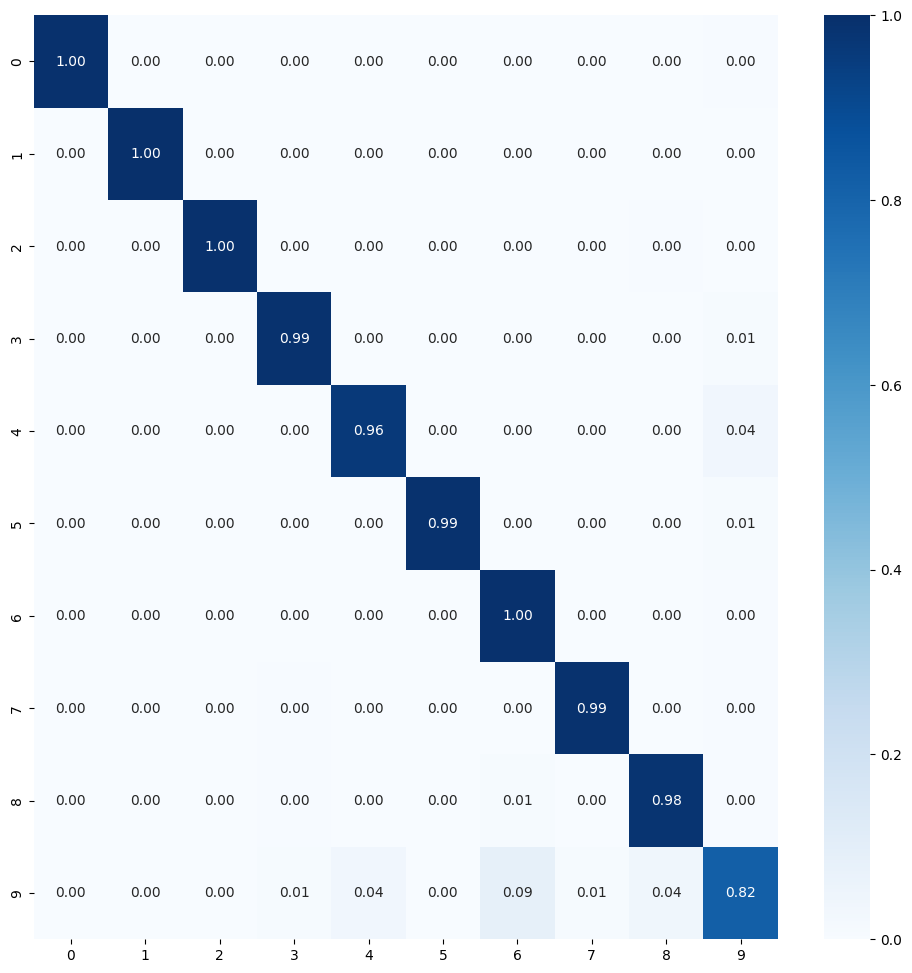


Best fold was 1 with val_accuracy: 0.9754
Average training accuracy in 5-fold: 0.999847149848938
Average validation precision in 5-fold: 0.9743749976158143

Test Metrics
test_acc_list: [0.9724444150924683, 0.9706666469573975, 0.9684444665908813, 0.9711111187934875, 0.9724444150924683]
Average Test Accuracy with 5-fold: 0.9710222125053406
test_loss_list: [0.1582566797733307, 0.1610097587108612, 0.2305552363395691, 0.16696380078792572, 0.18509867787361145]
Average Test Log Loss with 5-fold: 0.18037683069705962

Precision List: [0.9725466276822086, 0.9708797826727418, 0.9695594378563852, 0.9709757092940174, 0.9725213472582119]
Average Precision List with 5-fold: 0.971296580952713
Recall List: [0.9724444444444444, 0.9706666666666667, 0.9684444444444444, 0.971111111111111, 0.9724444444444446]
Average Recall List with 5-fold: 0.9710222222222221
F1 Score List: [0.9722105667627975, 0.9700695784289112, 0.9680388834603404, 0.9708328252878932, 0.9719710917366677]
Average F1 Score List with 5-fol

In [24]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: MobileNet_tf_150011
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 30s 73ms/step - loss: 0.0691 - accuracy: 0.9917 - val_loss: 0.4277 - val_accuracy: 0

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150011_1.pkl
361/361 [==============================] - 22s 61ms/step - loss: 0.0200 - accuracy: 0.9971
Train Accuracy: 0.9970563054084778
Train Log Loss: 0.020005956292152405
78/78 [==============================] - 5s 62ms/step - loss: 0.3223 - accuracy: 0.9467
Validation Accuracy: 0.9466666579246521
Validation Log Loss: 0.3223150074481964
78/78 [==============================] - 5s 62ms/step - loss: 0.2878 - accuracy: 0.9499
Test Accuracy: 0.9498990178108215
Test Log Loss: 0.2877728044986725
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   1   0   0   0   1]
 [  0   0   0   0 200   9   0   0   0   0  16]
 [ 

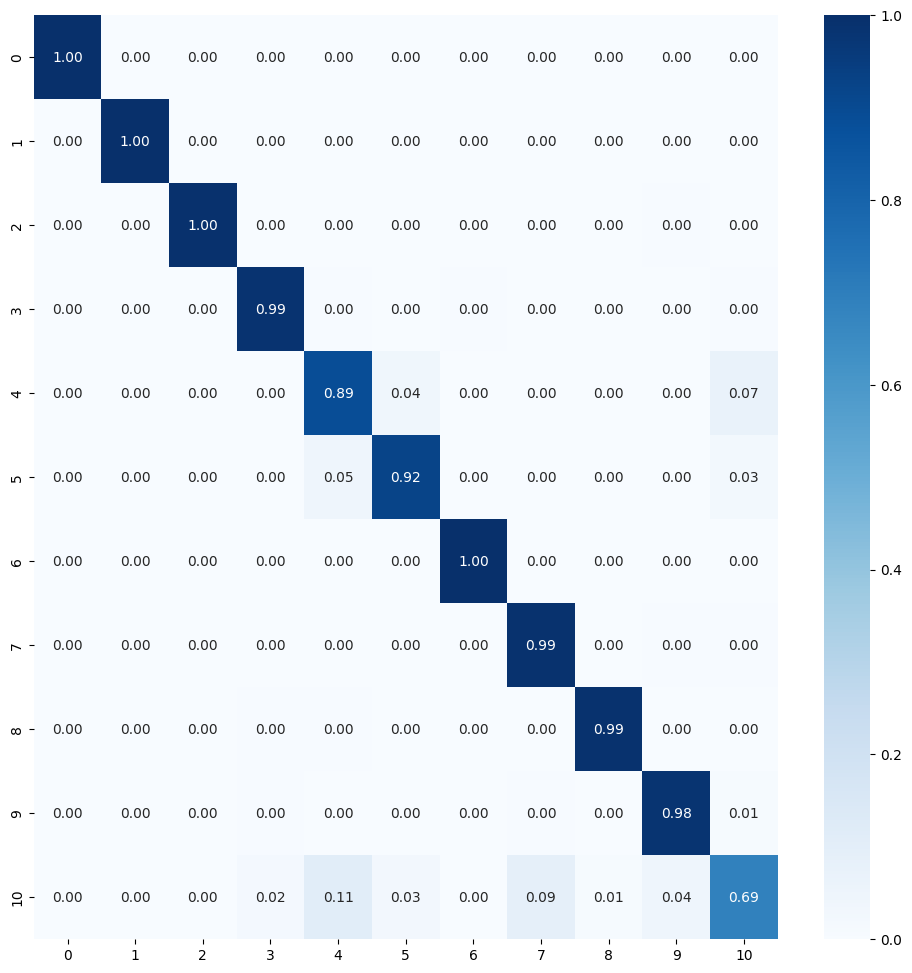


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 30s 76ms/step - loss: 0.0692 - accuracy: 0.9915 - val_loss: 0.3600 - val_accuracy: 0.9302
Epoch 2/50
360/360 [==============================] - 27s 75ms/step - loss: 0.0602 - accuracy: 0.9943 - val_loss: 0.3419 - val_accuracy: 0.9448
Epoch 3/50
360/360 [==============================] - 26s 73ms/step - loss: 0.0624 - accuracy: 0.9922 - val_loss: 0.3340 - val_accuracy: 0.9440
Epoch 4/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0583 - accuracy: 0.99

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150011_2.pkl
361/361 [==============================] - 22s 62ms/step - loss: 0.0389 - accuracy: 0.9911
Train Accuracy: 0.9910822510719299
Train Log Loss: 0.038932666182518005
78/78 [==============================] - 5s 61ms/step - loss: 0.3617 - accuracy: 0.9337
Validation Accuracy: 0.9337373971939087
Validation Log Loss: 0.3616655766963959
78/78 [==============================] - 5s 58ms/step - loss: 0.2883 - accuracy: 0.9426
Test Accuracy: 0.9426262378692627
Test Log Loss: 0.28826382756233215
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 217   0   1   0   0   0   0   7]
 [  0   0   0   0 167  10   0   0   0   0  48]
 [

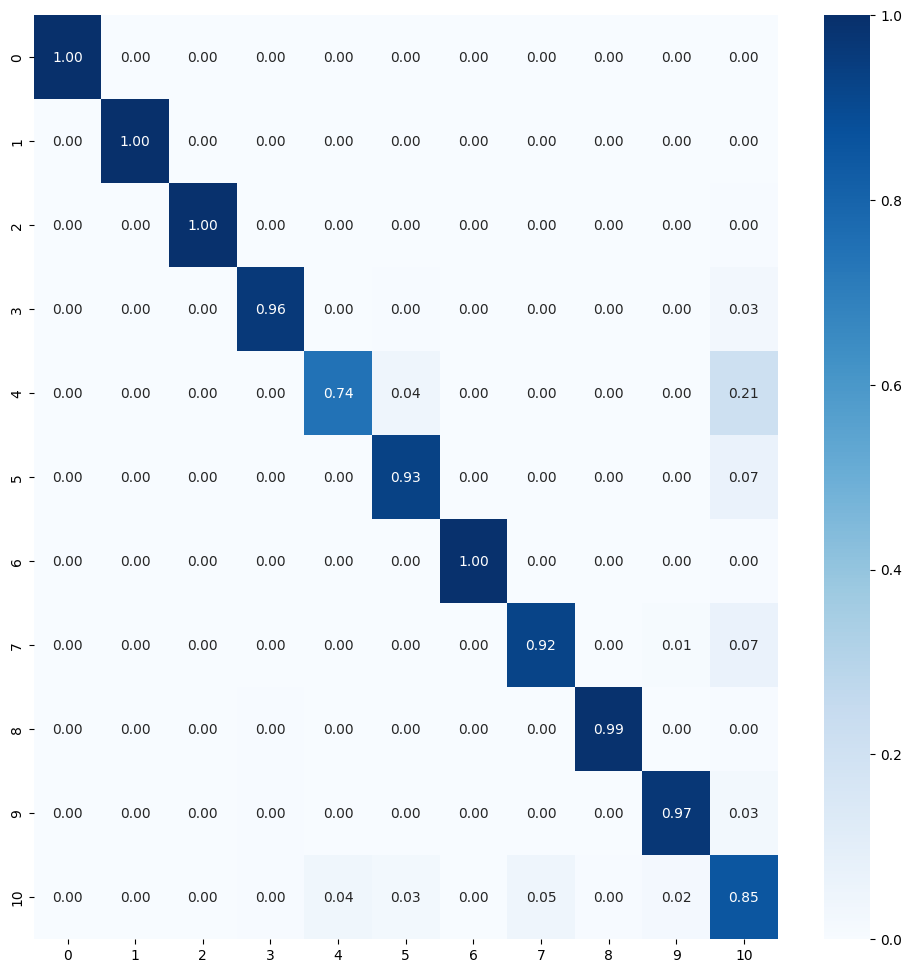


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 33s 78ms/step - loss: 0.0660 - accuracy: 0.9927 - val_loss: 0.3211 - val_accuracy: 0.9456
Epoch 2/50
360/360 [==============================] - 27s 75ms/step - loss: 0.0610 - accuracy: 0.9930 - val_loss: 0.3351 - val_accuracy: 0.9444
Epoch 3/50
360/360 [==============================] - 28s 77ms/step - loss: 0.0596 - accuracy: 0.9934 - val_loss: 0.3199 - val_accuracy: 0.9436
Epoch 4/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0612 - accuracy: 0.99

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150011_3.pkl
361/361 [==============================] - 21s 59ms/step - loss: 0.0193 - accuracy: 0.9971
Train Accuracy: 0.9970563054084778
Train Log Loss: 0.01929847151041031
78/78 [==============================] - 5s 59ms/step - loss: 0.2982 - accuracy: 0.9503
Validation Accuracy: 0.9503030180931091
Validation Log Loss: 0.29820090532302856
78/78 [==============================] - 5s 61ms/step - loss: 0.2628 - accuracy: 0.9503
Test Accuracy: 0.9503030180931091
Test Log Loss: 0.26279115676879883
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 220   1   0   1   1   0   0   2]
 [  0   0   0   0 206   7   0   0   0   0  12]
 [

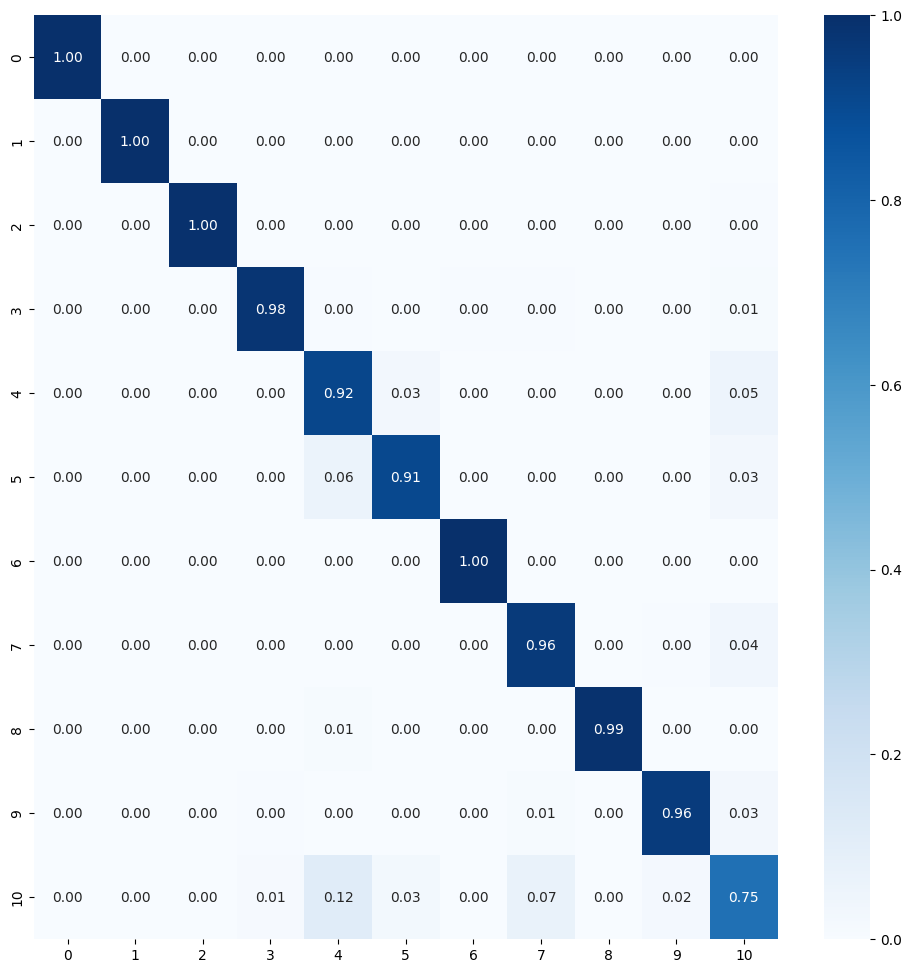


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 28s 69ms/step - loss: 0.0689 - accuracy: 0.9921 - val_loss: 0.3167 - val_accuracy: 0.9383
Epoch 2/50
360/360 [==============================] - 25s 69ms/step - loss: 0.0624 - accuracy: 0.9931 - val_loss: 0.3661 - val_accuracy: 0.9391
Epoch 3/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0625 - accuracy: 0.9925 - val_loss: 0.3018 - val_accuracy: 0.9460
Epoch 4/50
360/360 [==============================] - 27s 75ms/step - loss: 0.0617 - accuracy: 0.99

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150011_4.pkl
361/361 [==============================] - 22s 61ms/step - loss: 0.0189 - accuracy: 0.9975
Train Accuracy: 0.9974891543388367
Train Log Loss: 0.018928980454802513
78/78 [==============================] - 5s 62ms/step - loss: 0.2842 - accuracy: 0.9446
Validation Accuracy: 0.9446464776992798
Validation Log Loss: 0.2841719090938568
78/78 [==============================] - 5s 62ms/step - loss: 0.2487 - accuracy: 0.9487
Test Accuracy: 0.9486868977546692
Test Log Loss: 0.2486937791109085
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   1   0]
 [  0   0   0 221   0   0   1   1   0   0   2]
 [  0   0   0   0 195  12   0   0   0   0  18]
 [ 

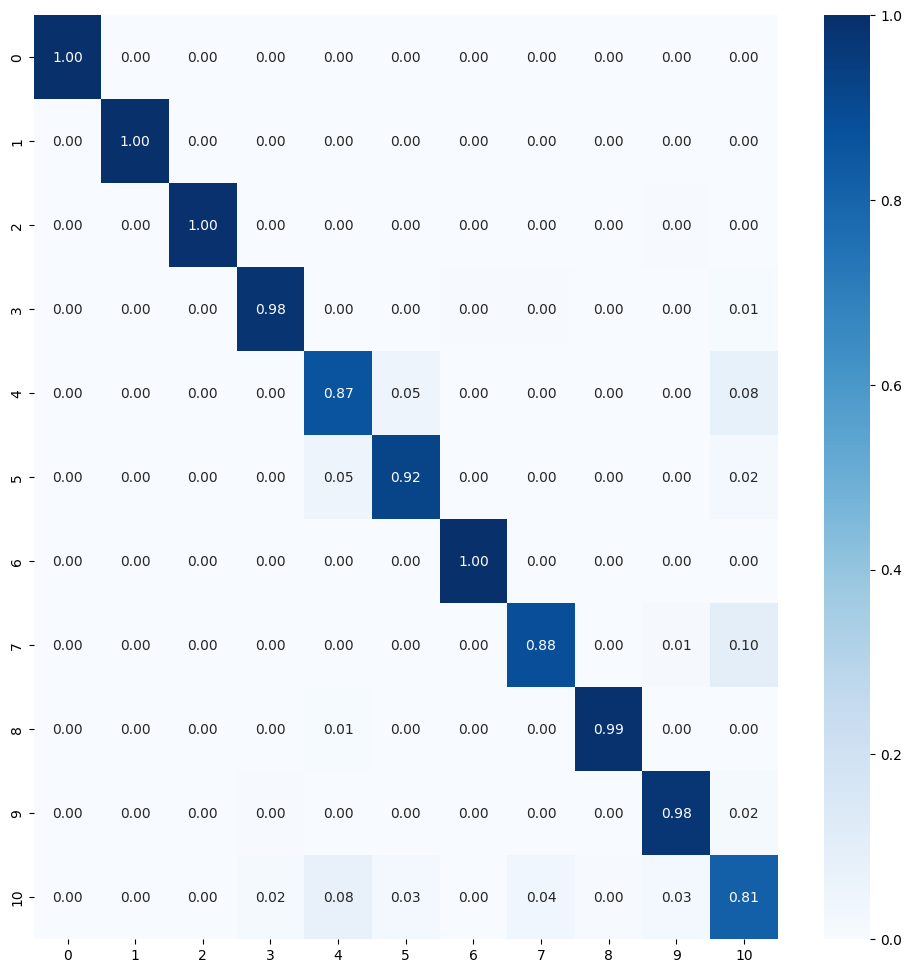


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150011_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_7 - Trainable: True
dropout_14 - Trainable: True
dense_22 - Trainable: True
dropout_15 - Trainable: True
dense_23 - Trainable: True
Epoch 1/50
360/360 [==============================] - 31s 77ms/step - loss: 0.0666 - accuracy: 0.9928 - val_loss: 0.2982 - val_accuracy: 0.9452
Epoch 2/50
360/360 [==============================] - 26s 72ms/step - loss: 0.0643 - accuracy: 0.9919 - val_loss: 0.3059 - val_accuracy: 0.9440
Epoch 3/50
360/360 [==============================] - 27s 75ms/step - loss: 0.0622 - accuracy: 0.9924 - val_loss: 0.3474 - val_accuracy: 0.9448
Epoch 4/50
360/360 [==============================] - 27s 74ms/step - loss: 0.0615 - accuracy: 0.99

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150011_5.pkl
361/361 [==============================] - 21s 57ms/step - loss: 0.0207 - accuracy: 0.9969
Train Accuracy: 0.9968830943107605
Train Log Loss: 0.02073890157043934
78/78 [==============================] - 5s 63ms/step - loss: 0.3055 - accuracy: 0.9451
Validation Accuracy: 0.9450504779815674
Validation Log Loss: 0.3055407702922821
78/78 [==============================] - 5s 59ms/step - loss: 0.2590 - accuracy: 0.9507
Test Accuracy: 0.9507070779800415
Test Log Loss: 0.2589738070964813
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   0   0   0   1]
 [  0   0 224   0   0   0   0   0   0   0   1]
 [  0   0   0 221   0   0   1   1   0   0   2]
 [  0   0   0   0 190   8   0   0   0   0  27]
 [  

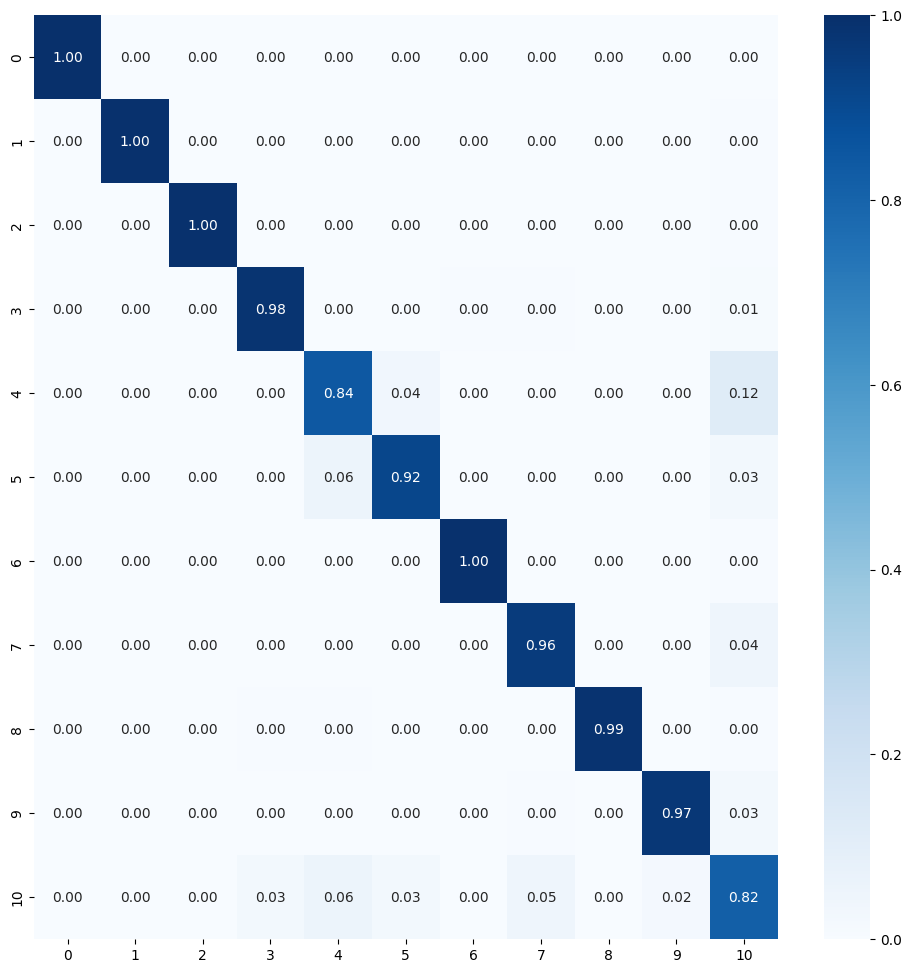


Best fold was 3 with val_accuracy: 0.9509
Average training accuracy in 5-fold: 0.9969091653823853
Average validation precision in 5-fold: 0.9504058480262756

Test Metrics
test_acc_list: [0.9498990178108215, 0.9426262378692627, 0.9503030180931091, 0.9486868977546692, 0.9507070779800415]
Average Test Accuracy with 5-fold: 0.9484444499015808
test_loss_list: [0.2877728044986725, 0.28826382756233215, 0.26279115676879883, 0.2486937791109085, 0.2589738070964813]
Average Test Log Loss with 5-fold: 0.26929907500743866

Precision List: [0.949098339695988, 0.9496238517169868, 0.9506824950587283, 0.9494680722767118, 0.9515662620785189]
Average Precision List with 5-fold: 0.9500878041653869
Recall List: [0.9498989898989898, 0.9426262626262627, 0.9503030303030303, 0.9486868686868686, 0.9507070707070707]
Average Recall List with 5-fold: 0.9484444444444444
F1 Score List: [0.9484202645193407, 0.9439599839246996, 0.9500727884469456, 0.9489010715252459, 0.9510203229948996]
Average F1 Score List with 5-f

In [25]:
%%time

num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: MobileNet_tf_150012
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 34s 78ms/step - loss: 0.0552 - accuracy: 0.9932 - val_loss: 0.3264 - val

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150012_1.pkl
394/394 [==============================] - 25s 62ms/step - loss: 0.0309 - accuracy: 0.9933
Train Accuracy: 0.9933333396911621
Train Log Loss: 0.03086579404771328
85/85 [==============================] - 5s 64ms/step - loss: 0.3165 - accuracy: 0.9496
Validation Accuracy: 0.9496296048164368
Validation Log Loss: 0.31654080748558044
85/85 [==============================] - 6s 61ms/step - loss: 0.3124 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.31236952543258667
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   1   0   0   0   2   0   1   0]
 [  0   0   0   0

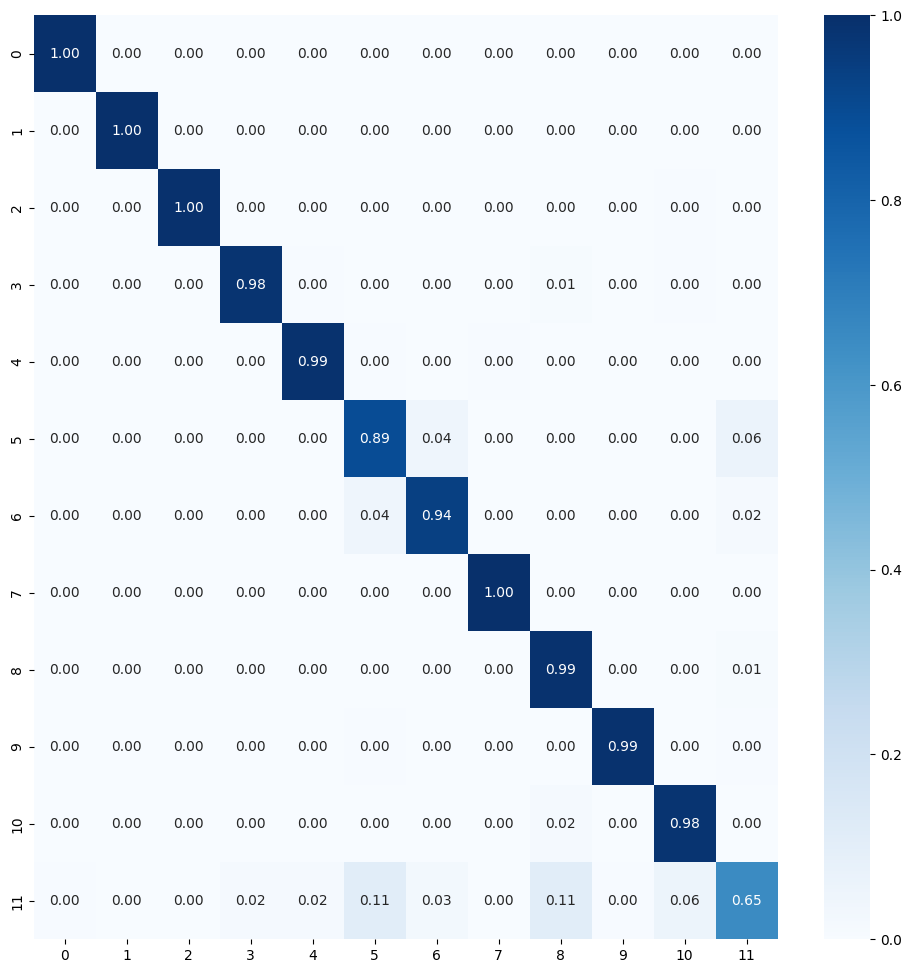


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 33s 76ms/step - loss: 0.0582 - accuracy: 0.9924 - val_loss: 0.2924 - val_accuracy: 0.9505
Epoch 2/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0579 - accuracy: 0.9922 - val_loss: 0.3962 - val_accuracy: 0.9278
Epoch 3/50
393/393 [==============================] - 30s 76ms/step - loss: 0.0531 - accuracy: 0.9932 - val_loss: 0.3840 - val_accuracy: 0.9382
Epoch 4/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0504 - accuracy: 0.9

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150012_2.pkl
394/394 [==============================] - 24s 61ms/step - loss: 0.0191 - accuracy: 0.9979
Train Accuracy: 0.997936487197876
Train Log Loss: 0.019052118062973022
85/85 [==============================] - 5s 62ms/step - loss: 0.3076 - accuracy: 0.9481
Validation Accuracy: 0.9481481313705444
Validation Log Loss: 0.3075762391090393
85/85 [==============================] - 6s 62ms/step - loss: 0.2798 - accuracy: 0.9526
Test Accuracy: 0.9525926113128662
Test Log Loss: 0.27977454662323
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0 224   0   0   0   0   0   0   0   0   1]
 [  0   0   0 220   2   1   0   0   0   0   0   2]
 [  0   0   0   0 220

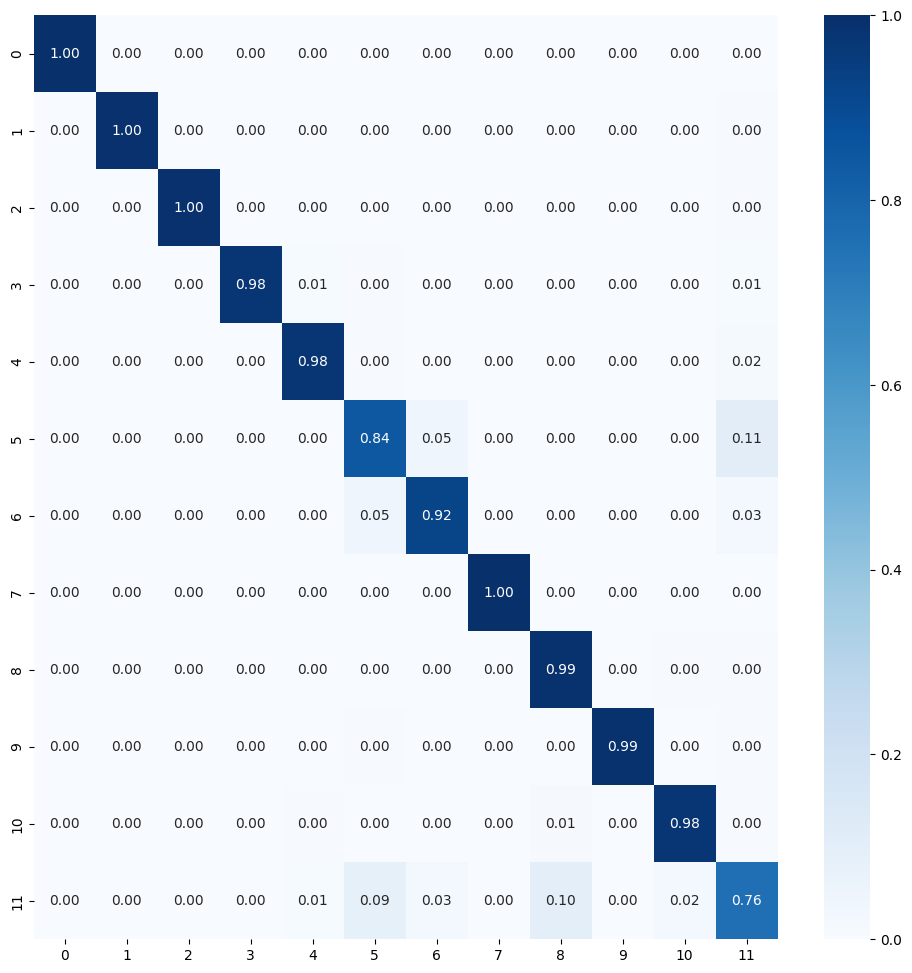


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 33s 76ms/step - loss: 0.0608 - accuracy: 0.9919 - val_loss: 0.4309 - val_accuracy: 0.9368
Epoch 2/50
393/393 [==============================] - 30s 75ms/step - loss: 0.0525 - accuracy: 0.9934 - val_loss: 0.2886 - val_accuracy: 0.9472
Epoch 3/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0532 - accuracy: 0.9922 - val_loss: 0.2903 - val_accuracy: 0.9412
Epoch 4/50
393/393 [==============================] - 29s 75ms/step - loss: 0.0530 - accuracy: 0.9

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150012_3.pkl
394/394 [==============================] - 24s 61ms/step - loss: 0.0222 - accuracy: 0.9961
Train Accuracy: 0.9961110949516296
Train Log Loss: 0.022199973464012146
85/85 [==============================] - 5s 62ms/step - loss: 0.3211 - accuracy: 0.9441
Validation Accuracy: 0.9440740942955017
Validation Log Loss: 0.3211382031440735
85/85 [==============================] - 5s 63ms/step - loss: 0.2684 - accuracy: 0.9519
Test Accuracy: 0.9518518447875977
Test Log Loss: 0.2683861255645752
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1]
 [  0   0   0 221   2   0   0   0   1   0   0   1]
 [  0   0   0   0 

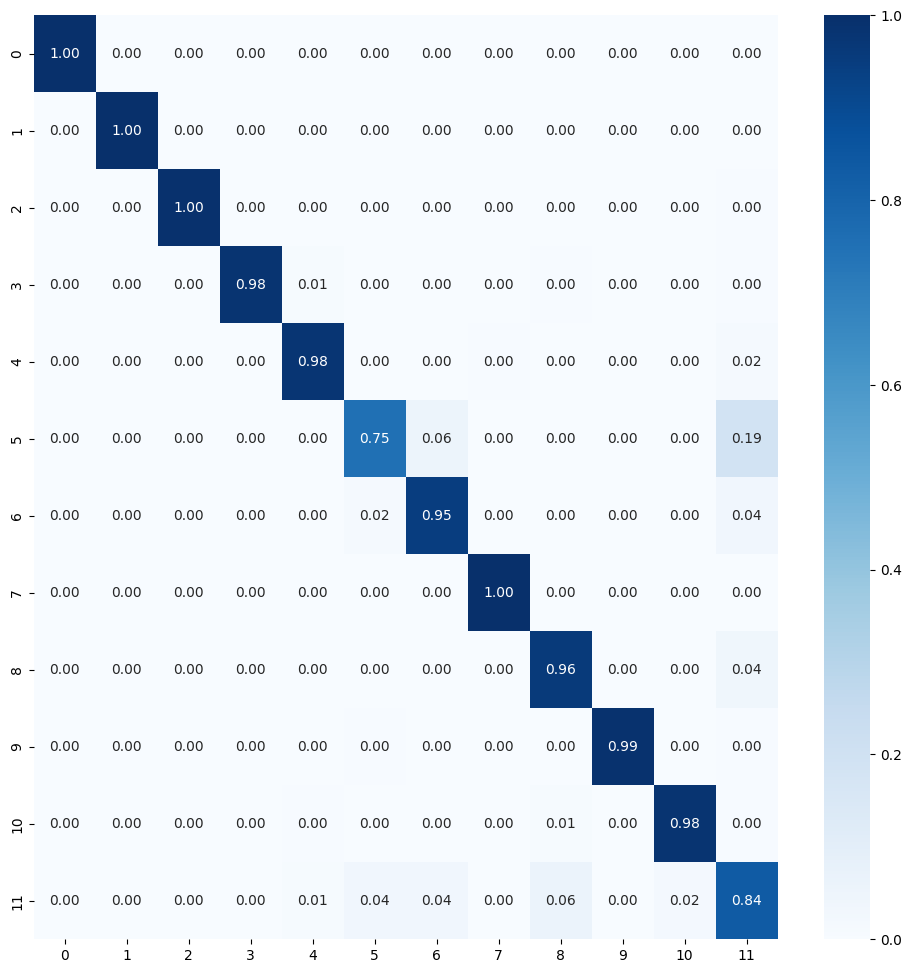


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 34s 76ms/step - loss: 0.0564 - accuracy: 0.9936 - val_loss: 0.2883 - val_accuracy: 0.9435
Epoch 2/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0544 - accuracy: 0.9930 - val_loss: 0.2885 - val_accuracy: 0.9449
Epoch 3/50
393/393 [==============================] - 30s 75ms/step - loss: 0.0522 - accuracy: 0.9933 - val_loss: 0.2831 - val_accuracy: 0.9509
Epoch 4/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0526 - accuracy: 0.9

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150012_4.pkl
394/394 [==============================] - 24s 62ms/step - loss: 0.0206 - accuracy: 0.9970
Train Accuracy: 0.9969841241836548
Train Log Loss: 0.020572753623127937
85/85 [==============================] - 5s 61ms/step - loss: 0.3125 - accuracy: 0.9444
Validation Accuracy: 0.9444444179534912
Validation Log Loss: 0.31249484419822693
85/85 [==============================] - 5s 61ms/step - loss: 0.2733 - accuracy: 0.9478
Test Accuracy: 0.9477777481079102
Test Log Loss: 0.2733025550842285
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   1   0   0   0   0   1   0]
 [  0   0   0   1

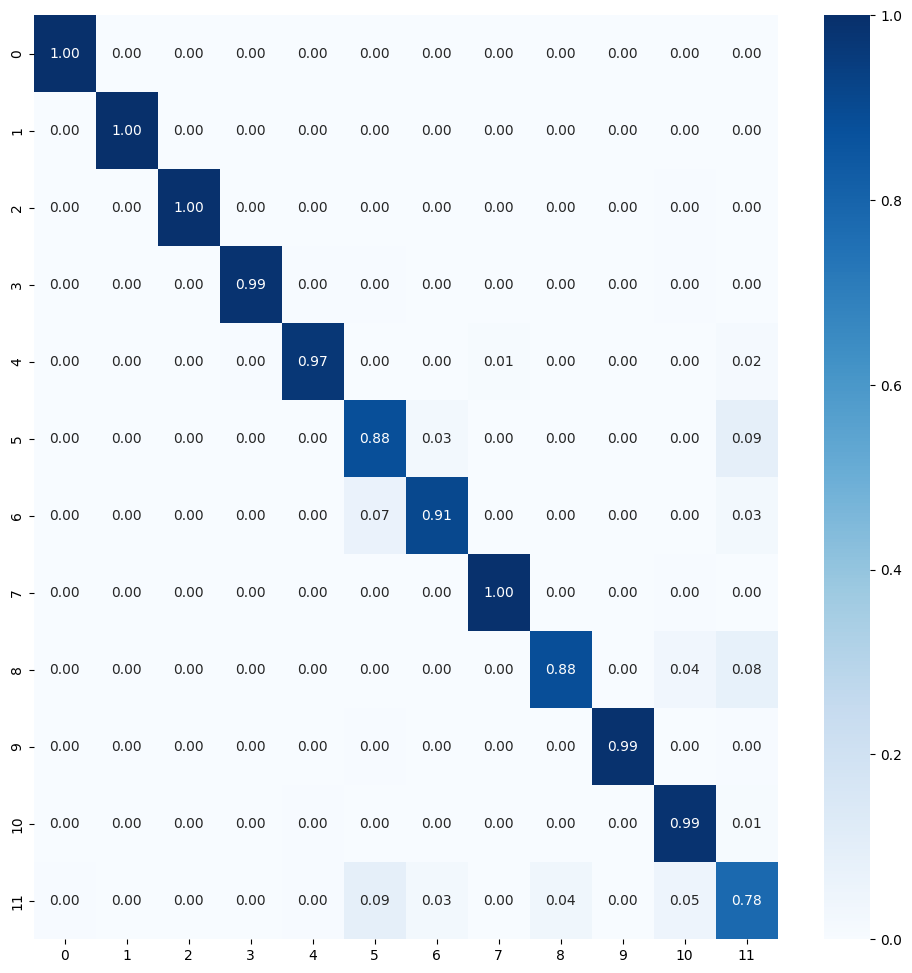


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150012_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_13 - Trainable: True
dropout_26 - Trainable: True
dense_40 - Trainable: True
dropout_27 - Trainable: True
dense_41 - Trainable: True
Epoch 1/50
393/393 [==============================] - 33s 75ms/step - loss: 0.0566 - accuracy: 0.9930 - val_loss: 0.3057 - val_accuracy: 0.9513
Epoch 2/50
393/393 [==============================] - 29s 73ms/step - loss: 0.0542 - accuracy: 0.9927 - val_loss: 0.4853 - val_accuracy: 0.9342
Epoch 3/50
393/393 [==============================] - 28s 70ms/step - loss: 0.0534 - accuracy: 0.9927 - val_loss: 0.3385 - val_accuracy: 0.9304
Epoch 4/50
393/393 [==============================] - 29s 74ms/step - loss: 0.0517 - accuracy: 0.9

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150012_5.pkl
394/394 [==============================] - 24s 62ms/step - loss: 0.0182 - accuracy: 0.9978
Train Accuracy: 0.9977777600288391
Train Log Loss: 0.018229888752102852
85/85 [==============================] - 5s 62ms/step - loss: 0.2931 - accuracy: 0.9533
Validation Accuracy: 0.95333331823349
Validation Log Loss: 0.29311132431030273
85/85 [==============================] - 5s 61ms/step - loss: 0.2773 - accuracy: 0.9522
Test Accuracy: 0.9522222280502319
Test Log Loss: 0.27728068828582764
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   2   0   0   0   2   0   0   1]
 [  0   0   0   0 

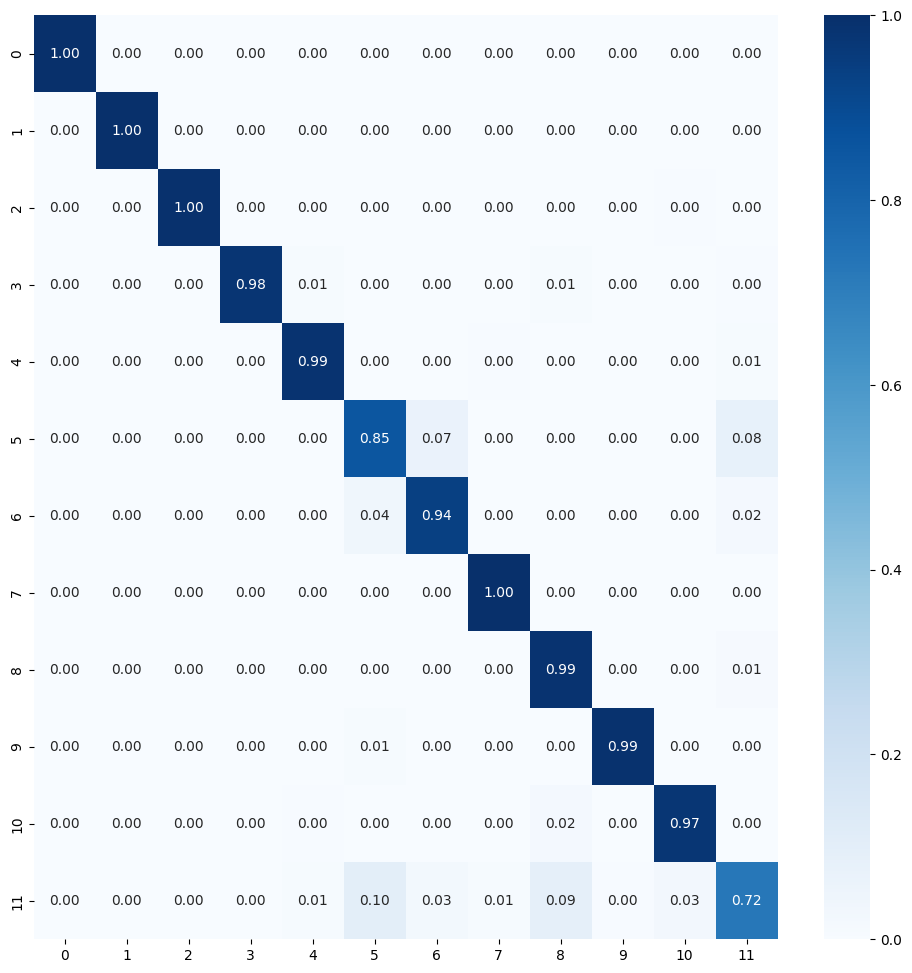


Best fold was 1 with val_accuracy: 0.9546
Average training accuracy in 5-fold: 0.996658182144165
Average validation precision in 5-fold: 0.9540178537368774

Test Metrics
test_acc_list: [0.9511111378669739, 0.9525926113128662, 0.9518518447875977, 0.9477777481079102, 0.9522222280502319]
Average Test Accuracy with 5-fold: 0.951111114025116
test_loss_list: [0.31236952543258667, 0.27977454662323, 0.2683861255645752, 0.2733025550842285, 0.27728068828582764]
Average Test Log Loss with 5-fold: 0.2822226881980896

Precision List: [0.9508063932441885, 0.9523973822957251, 0.9542892142207239, 0.9488227101487512, 0.9517589759299857]
Average Precision List with 5-fold: 0.9516149351678749
Recall List: [0.9511111111111114, 0.9525925925925925, 0.9518518518518521, 0.9477777777777777, 0.9522222222222222]
Average Recall List with 5-fold: 0.9511111111111111
F1 Score List: [0.9491745789016788, 0.9522280519110788, 0.9519543658405537, 0.9479539358165558, 0.9513272089093978]
Average F1 Score List with 5-fold:

In [26]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: MobileNet_tf_150013
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 37s 79ms/step - loss: 0.0538 - accuracy: 0.9924 - val_loss: 0.3

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150013_1.pkl
427/427 [==============================] - 26s 61ms/step - loss: 0.0205 - accuracy: 0.9977
Train Accuracy: 0.9976556897163391
Train Log Loss: 0.02049930952489376
92/92 [==============================] - 6s 62ms/step - loss: 0.2580 - accuracy: 0.9525
Validation Accuracy: 0.9524786472320557
Validation Log Loss: 0.25803419947624207
92/92 [==============================] - 6s 64ms/step - loss: 0.2342 - accuracy: 0.9562
Test Accuracy: 0.9562393426895142
Test Log Loss: 0.23416495323181152
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 220   1   0   0   0   0   1 

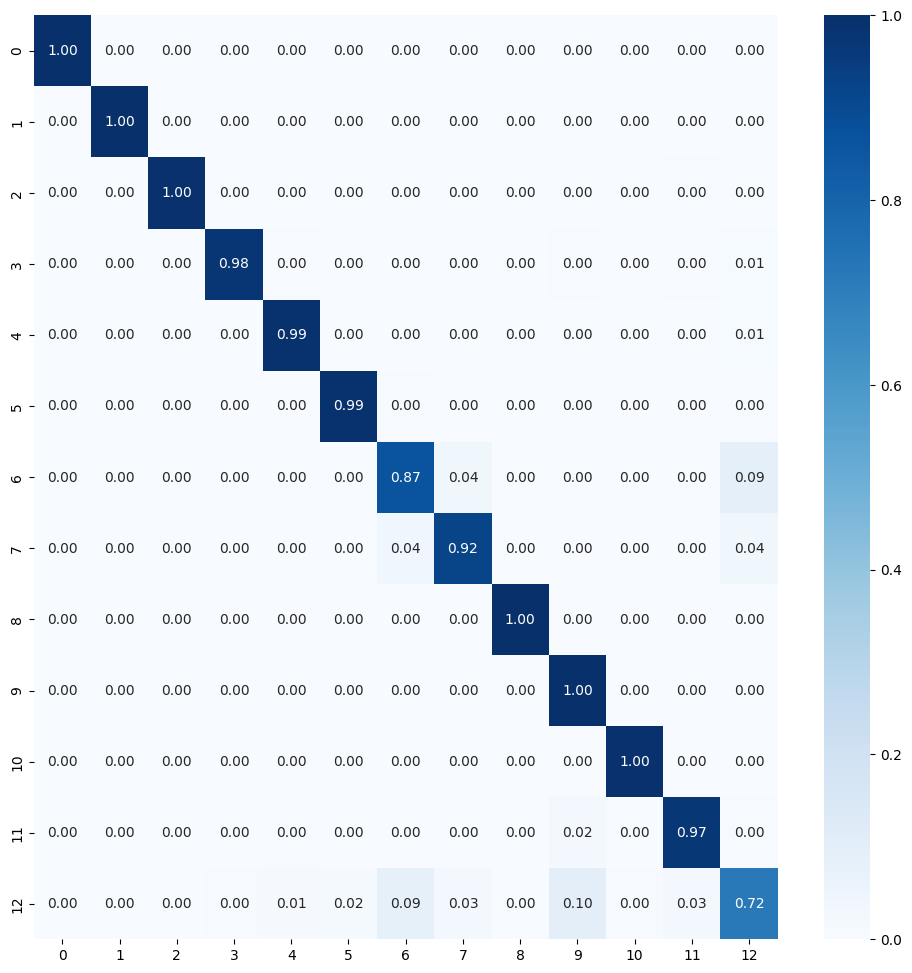


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 36s 76ms/step - loss: 0.0532 - accuracy: 0.9929 - val_loss: 0.2532 - val_accuracy: 0.9533
Epoch 2/50
426/426 [==============================] - 31s 74ms/step - loss: 0.0479 - accuracy: 0.9944 - val_loss: 0.2605 - val_accuracy: 0.9512
Epoch 3/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0455 - accuracy: 0.9945 - val_loss: 0.2837 - val_accuracy: 0.9468
Epoch 4/50
426/426 [==============================] - 32s 76ms/step - loss: 0.0474 - accuracy: 0.9

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150013_2.pkl
427/427 [==============================] - 26s 61ms/step - loss: 0.0168 - accuracy: 0.9982
Train Accuracy: 0.9981684684753418
Train Log Loss: 0.0168206375092268
92/92 [==============================] - 6s 63ms/step - loss: 0.2763 - accuracy: 0.9566
Validation Accuracy: 0.956581175327301
Validation Log Loss: 0.2763292193412781
92/92 [==============================] - 6s 62ms/step - loss: 0.2636 - accuracy: 0.9562
Test Accuracy: 0.9562393426895142
Test Log Loss: 0.26363587379455566
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 222   1   0   0   0   0   1   0

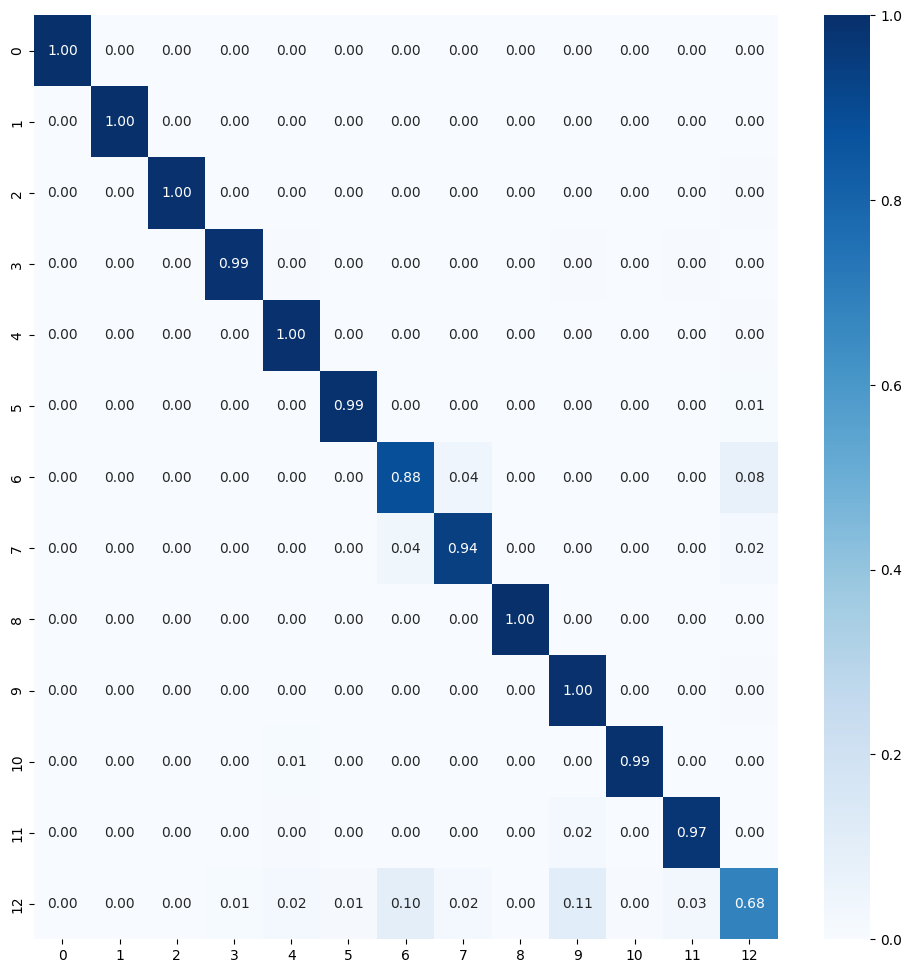


TRAINING AND EVALUATING FOLD 3/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 35s 75ms/step - loss: 0.0530 - accuracy: 0.9928 - val_loss: 0.2758 - val_accuracy: 0.9485
Epoch 2/50
426/426 [==============================] - 34s 79ms/step - loss: 0.0477 - accuracy: 0.9941 - val_loss: 0.2750 - val_accuracy: 0.9530
Epoch 3/50
426/426 [==============================] - 64s 149ms/step - loss: 0.0452 - accuracy: 0.9943 - val_loss: 0.2756 - val_accuracy: 0.9492
Epoch 4/50
426/426 [==============================] - 64s 150ms/step - loss: 0.0488 - accuracy: 0

History for fold 3 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150013_3.pkl
427/427 [==============================] - 25s 59ms/step - loss: 0.0207 - accuracy: 0.9974
Train Accuracy: 0.9973626136779785
Train Log Loss: 0.020672598853707314
92/92 [==============================] - 6s 61ms/step - loss: 0.3007 - accuracy: 0.9456
Validation Accuracy: 0.945641040802002
Validation Log Loss: 0.3006570041179657
92/92 [==============================] - 6s 60ms/step - loss: 0.2657 - accuracy: 0.9470
Test Accuracy: 0.9470085501670837
Test Log Loss: 0.2656855881214142
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0 221   1   0   0   0   0   1   

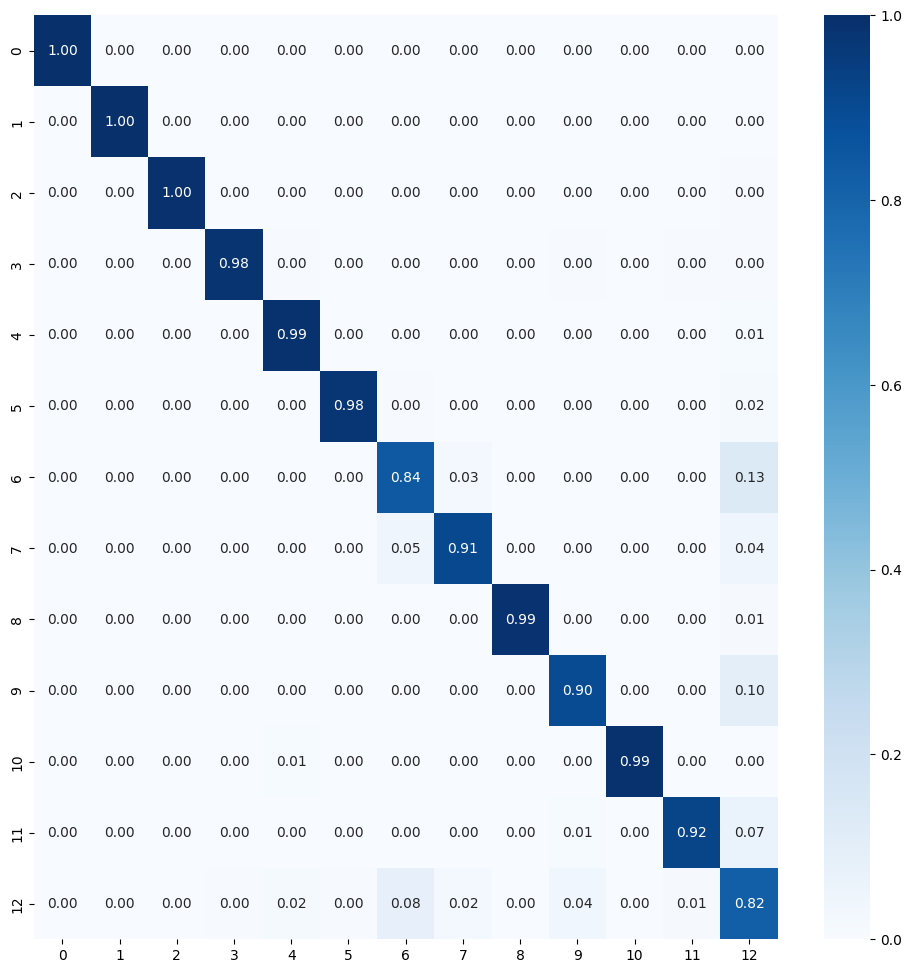


TRAINING AND EVALUATING FOLD 4/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 37s 74ms/step - loss: 0.0550 - accuracy: 0.9927 - val_loss: 0.2585 - val_accuracy: 0.9547
Epoch 2/50
426/426 [==============================] - 32s 75ms/step - loss: 0.0492 - accuracy: 0.9938 - val_loss: 0.2630 - val_accuracy: 0.9519
Epoch 3/50
426/426 [==============================] - 32s 75ms/step - loss: 0.0449 - accuracy: 0.9951 - val_loss: 0.2662 - val_accuracy: 0.9526
Epoch 4/50
426/426 [==============================] - 32s 75ms/step - loss: 0.0470 - accuracy: 0.9

History for fold 4 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150013_4.pkl
427/427 [==============================] - 26s 61ms/step - loss: 0.0174 - accuracy: 0.9977
Train Accuracy: 0.9976556897163391
Train Log Loss: 0.017391448840498924
92/92 [==============================] - 6s 61ms/step - loss: 0.2841 - accuracy: 0.9545
Validation Accuracy: 0.9545299410820007
Validation Log Loss: 0.2840535342693329
92/92 [==============================] - 6s 57ms/step - loss: 0.2608 - accuracy: 0.9576
Test Accuracy: 0.957606852054596
Test Log Loss: 0.26079288125038147
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 221   2   0   0   0   0   1  

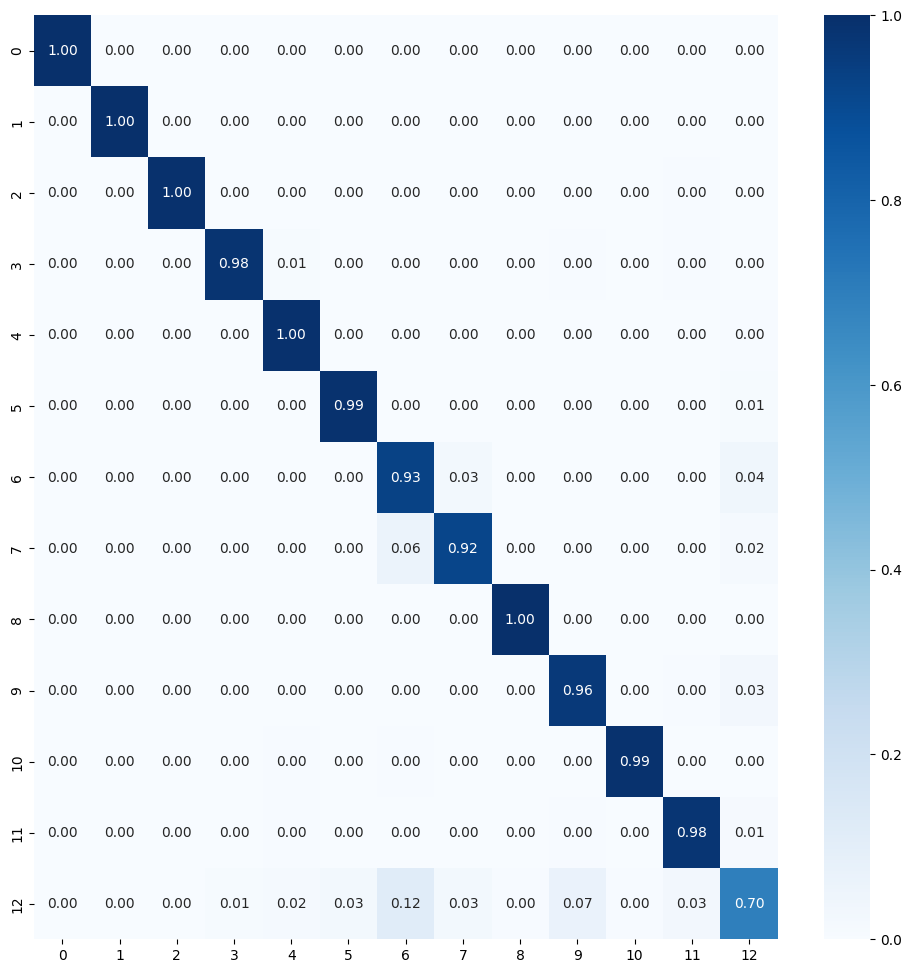


TRAINING AND EVALUATING FOLD 5/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150013_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_15 - Trainable: True
dropout_30 - Trainable: True
dense_46 - Trainable: True
dropout_31 - Trainable: True
dense_47 - Trainable: True
Epoch 1/50
426/426 [==============================] - 36s 76ms/step - loss: 0.0538 - accuracy: 0.9924 - val_loss: 0.2619 - val_accuracy: 0.9488
Epoch 2/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0480 - accuracy: 0.9935 - val_loss: 0.3369 - val_accuracy: 0.9481
Epoch 3/50
426/426 [==============================] - 32s 76ms/step - loss: 0.0497 - accuracy: 0.9922 - val_loss: 0.2971 - val_accuracy: 0.9440
Epoch 4/50
426/426 [==============================] - 31s 73ms/step - loss: 0.0501 - accuracy: 0.9

History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150013_5.pkl
427/427 [==============================] - 63s 146ms/step - loss: 0.0205 - accuracy: 0.9977
Train Accuracy: 0.9977289438247681
Train Log Loss: 0.02045653760433197
92/92 [==============================] - 13s 143ms/step - loss: 0.2838 - accuracy: 0.9511
Validation Accuracy: 0.9511111378669739
Validation Log Loss: 0.28379788994789124
92/92 [==============================] - 14s 144ms/step - loss: 0.2637 - accuracy: 0.9511
Test Accuracy: 0.9511111378669739
Test Log Loss: 0.2637244462966919
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0 222   1   0   0   1   0 

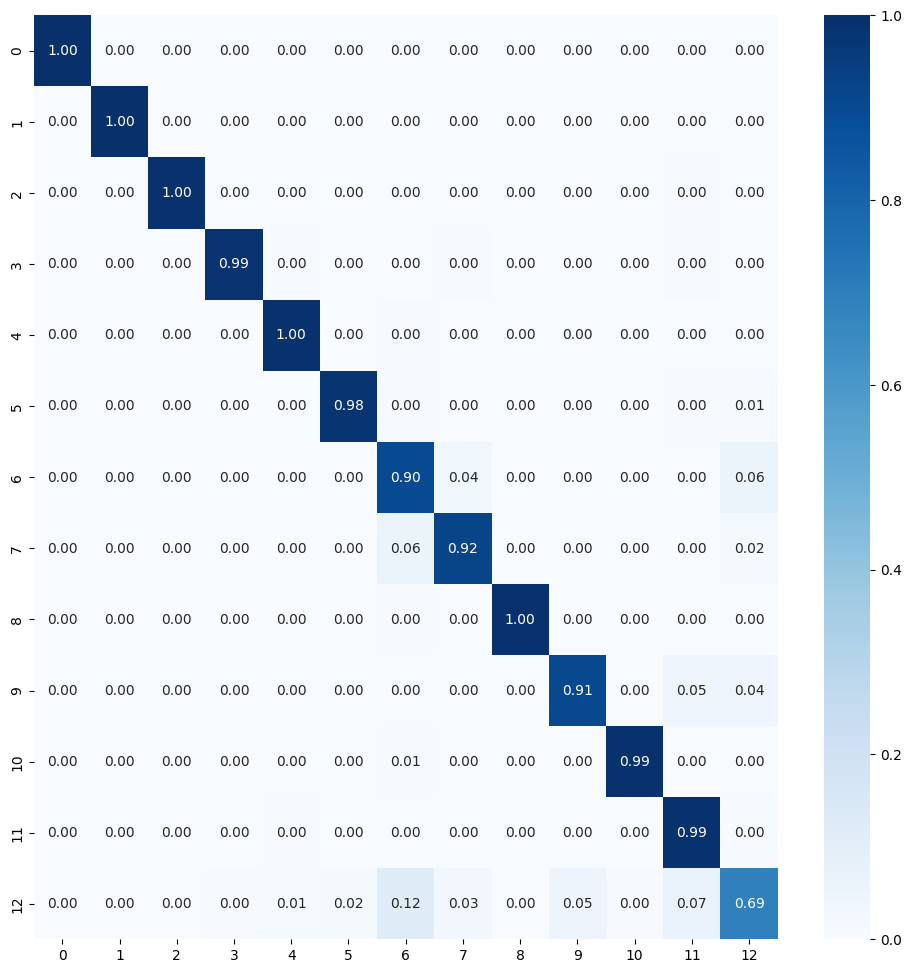


Best fold was 1 with val_accuracy: 0.9581
Average training accuracy in 5-fold: 0.9971801996231079
Average validation precision in 5-fold: 0.9574862480163574

Test Metrics
test_acc_list: [0.9562393426895142, 0.9562393426895142, 0.9470085501670837, 0.957606852054596, 0.9511111378669739]
Average Test Accuracy with 5-fold: 0.9536410450935364
test_loss_list: [0.23416495323181152, 0.26363587379455566, 0.2656855881214142, 0.26079288125038147, 0.2637244462966919]
Average Test Log Loss with 5-fold: 0.25760074853897097

Precision List: [0.9555839570438418, 0.9556324532319421, 0.9516881154906398, 0.9573164017946851, 0.9512921046347483]
Average Precision List with 5-fold: 0.9543026064391714
Recall List: [0.9562393162393162, 0.9562393162393162, 0.9470085470085471, 0.9576068376068376, 0.9511111111111111]
Average Recall List with 5-fold: 0.9536410256410257
F1 Score List: [0.9554053011989456, 0.9549264316013838, 0.9486280445092967, 0.9565481780914614, 0.9502477153350927]
Average F1 Score List with 5-

In [27]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: MobileNet_tf_150014
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 87s 165ms/step - loss: 0.1207 - accuracy: 0.9605 - val_

History for fold 1 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150014_1.pkl
460/460 [==============================] - 59s 125ms/step - loss: 0.0718 - accuracy: 0.9742
Train Accuracy: 0.9742177128791809
Train Log Loss: 0.07175416499376297
99/99 [==============================] - 13s 132ms/step - loss: 0.3351 - accuracy: 0.9175
Validation Accuracy: 0.9174603223800659
Validation Log Loss: 0.33509311079978943
99/99 [==============================] - 15s 136ms/step - loss: 0.2866 - accuracy: 0.9314
Test Accuracy: 0.9314285516738892
Test Log Loss: 0.28656888008117676
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   

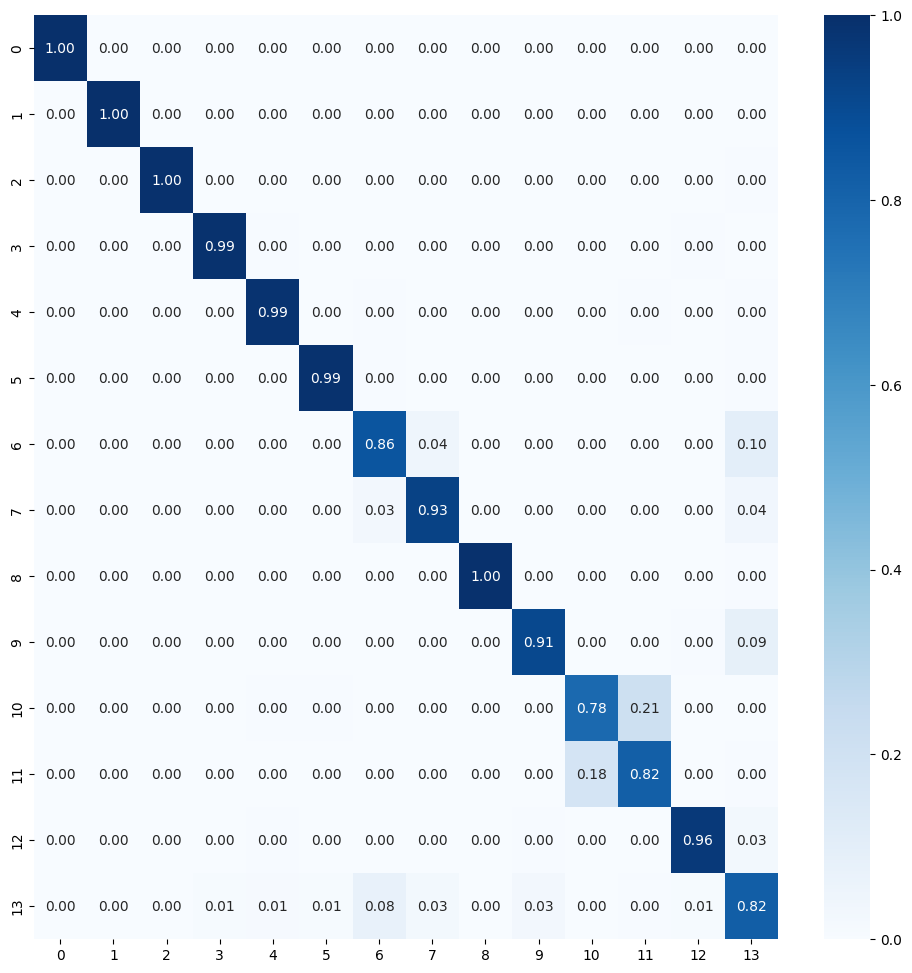


TRAINING AND EVALUATING FOLD 2/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150014_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_23 - Trainable: True
dropout_46 - Trainable: True
dense_70 - Trainable: True
dropout_47 - Trainable: True
dense_71 - Trainable: True
Epoch 1/50
459/459 [==============================] - 83s 161ms/step - loss: 0.1182 - accuracy: 0.9623 - val_loss: 0.3594 - val_accuracy: 0.9002
Epoch 2/50
459/459 [==============================] - 70s 153ms/step - loss: 0.1132 - accuracy: 0.9633 - val_loss: 0.3344 - val_accuracy: 0.9050
Epoch 3/50
459/459 [==============================] - 68s 148ms/step - loss: 0.1156 - accuracy: 0.9614 - val_loss: 0.3542 - val_accuracy: 0.9216
Epoch 4/50
459/459 [==============================] - 64s 140ms/step - loss: 0.1144 - accuracy:

History for fold 2 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150014_2.pkl
459/459 [==============================] - 82s 157ms/step - loss: 0.1200 - accuracy: 0.9622 - val_loss: 0.3663 - val_accuracy: 0.9107
Epoch 2/50
459/459 [==============================] - 70s 151ms/step - loss: 0.1131 - accuracy: 0.9613 - val_loss: 0.3091 - val_accuracy: 0.9200
Epoch 3/50
459/459 [==============================] - 63s 136ms/step - loss: 0.1150 - accuracy: 0.9618 - val_loss: 0.3575 - val_accuracy: 0.9155
Epoch 4/50
459/459 [==============================] - 68s 147ms/step - loss: 0.1139 - accuracy: 0.9621 - val_loss: 0.3329 - val_accuracy: 0.9094
Epoch 5/50
459/459 [==============================] - 71s 155ms/step - loss: 0.1088 - accuracy: 0.9633 - val_loss: 0.3671 - val_accuracy: 0.9027
Epoch 6/50
459/459 [==============================] - 68s 147ms/step - loss: 0.1129 - accuracy: 0.9607 - val_loss: 0.3431 - val_accuracy: 0.9047
Epoch 7/50
419/459 [==========================>...] - ETA

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



459/459 [==============================] - 73s 156ms/step - loss: 0.0994 - accuracy: 0.9645 - val_loss: 0.3440 - val_accuracy: 0.9196
Epoch 17/50
389/459 [========================>.....] - ETA: 8s - loss: 0.0993 - accuracy: 0.9641

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



459/459 [==============================] - 73s 158ms/step - loss: 0.0895 - accuracy: 0.9666 - val_loss: 0.3104 - val_accuracy: 0.9174
Epoch 33/50
211/459 [============>.................] - ETA: 33s - loss: 0.0905 - accuracy: 0.9665

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



459/459 [==============================] - 72s 158ms/step - loss: 0.0794 - accuracy: 0.9707 - val_loss: 0.3300 - val_accuracy: 0.9190
Epoch 49/50
459/459 [==============================] - 72s 158ms/step - loss: 0.0793 - accuracy: 0.9701 - val_loss: 0.3364 - val_accuracy: 0.9050
Epoch 50/50
459/459 [==============================] - 72s 155ms/step - loss: 0.0803 - accuracy: 0.9693 - val_loss: 0.3478 - val_accuracy: 0.9267


History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150014_5.pkl
460/460 [==============================] - 55s 118ms/step - loss: 0.0709 - accuracy: 0.9739
Train Accuracy: 0.9739455580711365
Train Log Loss: 0.07091660797595978
99/99 [==============================] - 12s 114ms/step - loss: 0.3471 - accuracy: 0.9263
Validation Accuracy: 0.9263492226600647
Validation Log Loss: 0.34709838032722473
99/99 [==============================] - 13s 132ms/step - loss: 0.3091 - accuracy: 0.9308
Test Accuracy: 0.9307936429977417
Test Log Loss: 0.3090820014476776
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 224   0   0   0   0   0   0   0   0   0   1   0]
 [  0   0   0

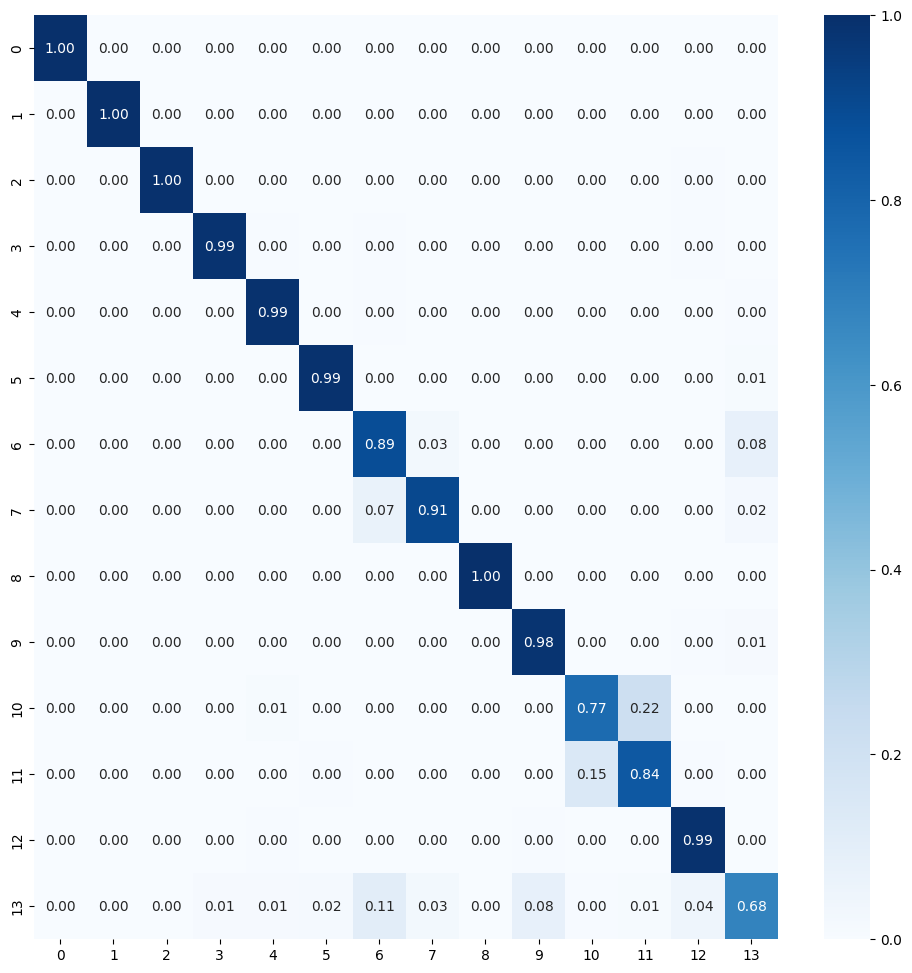


Best fold was 3 with val_accuracy: 0.9298
Average training accuracy in 5-fold: 0.9703572273254395
Average validation precision in 5-fold: 0.928316330909729

Test Metrics
test_acc_list: [0.9314285516738892, 0.9320635199546814, 0.9323809742927551, 0.9273015856742859, 0.9307936429977417]
Average Test Accuracy with 5-fold: 0.9307936549186706
test_loss_list: [0.28656888008117676, 0.2975371181964874, 0.29838240146636963, 0.3033146262168884, 0.3090820014476776]
Average Test Log Loss with 5-fold: 0.29897700548171996

Precision List: [0.9327484616031573, 0.93164289132926, 0.9327112872067699, 0.9321930758220535, 0.9302942343682333]
Average Precision List with 5-fold: 0.9319179900658948
Recall List: [0.9314285714285715, 0.9320634920634921, 0.9323809523809523, 0.9273015873015874, 0.9307936507936508]
Average Recall List with 5-fold: 0.9307936507936508
F1 Score List: [0.9318449059499745, 0.930964271610598, 0.9315245061467132, 0.9282315581228434, 0.9295656762412969]
Average F1 Score List with 5-fold

In [28]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

In [29]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: MobileNet_tf_150015
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

TRAINING AND EVALUATING FOLD 1/5...

model_path: /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Loading pre-trained model from /notebooks/train3/layer_contribution/MobileNet_tf_optimized/MobileNet_tf_150015_best.h5
Model loaded successfully.

Trainable layers after loading:
batch_normalization_28 - Trainable: True
dropout_56 - Trainable: True
dense_85 - Trainable: True
dropout_57 - Trainable: True
dense_86 - Trainable: True
Epoch 1/50
492/492 [==============================] - 98s 177ms/step - loss: 0.1152 - accuracy: 0.96

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



492/492 [==============================] - 82s 168ms/step - loss: 0.1087 - accuracy: 0.9641 - val_loss: 0.3304 - val_accuracy: 0.9244
Epoch 6/50
492/492 [==============================] - 72s 147ms/step - loss: 0.1071 - accuracy: 0.9641 - val_loss: 0.3241 - val_accuracy: 0.9190
Epoch 7/50
492/492 [==============================] - 73s 149ms/step - loss: 0.1039 - accuracy: 0.9653 - val_loss: 0.3671 - val_accuracy: 0.9057
Epoch 8/50
228/492 [============>.................] - ETA: 31s - loss: 0.1012 - accuracy: 0.9656

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



492/492 [==============================] - 84s 170ms/step - loss: 0.0926 - accuracy: 0.9655 - val_loss: 0.3486 - val_accuracy: 0.9271
Epoch 20/50
492/492 [==============================] - 85s 173ms/step - loss: 0.0941 - accuracy: 0.9669 - val_loss: 0.3195 - val_accuracy: 0.9271
Epoch 21/50
492/492 [==============================] - 84s 171ms/step - loss: 0.0918 - accuracy: 0.9676 - val_loss: 0.3958 - val_accuracy: 0.9116
Epoch 22/50
269/492 [===============>..............] - ETA: 30s - loss: 0.0933 - accuracy: 0.9667

...

492/492 [==============================] - 76s 153ms/step - loss: 0.0792 - accuracy: 0.9715 - val_loss: 0.3497 - val_accuracy: 0.9170
Epoch 46/50
492/492 [==============================] - 72s 146ms/step - loss: 0.0799 - accuracy: 0.9705 - val_loss: 0.3512 - val_accuracy: 0.9182
Epoch 47/50
340/492 [===================>..........] - ETA: 18s - loss: 0.0838 - accuracy: 0.9685

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



492/492 [==============================] - 75s 153ms/step - loss: 0.0809 - accuracy: 0.9702 - val_loss: 0.3718 - val_accuracy: 0.9134
Epoch 46/50
492/492 [==============================] - 74s 150ms/step - loss: 0.0798 - accuracy: 0.9697 - val_loss: 0.3674 - val_accuracy: 0.9247
Epoch 47/50
492/492 [==============================] - 75s 151ms/step - loss: 0.0813 - accuracy: 0.9709 - val_loss: 0.3481 - val_accuracy: 0.9238
Epoch 48/50
492/492 [==============================] - 75s 152ms/step - loss: 0.0808 - accuracy: 0.9698 - val_loss: 0.3327 - val_accuracy: 0.9193
Epoch 49/50
492/492 [==============================] - 70s 142ms/step - loss: 0.0777 - accuracy: 0.9705 - val_loss: 0.3194 - val_accuracy: 0.9185
Epoch 50/50
492/492 [==============================] - 75s 152ms/step - loss: 0.0794 - accuracy: 0.9713 - val_loss: 0.3764 - val_accuracy: 0.9024


History for fold 5 saved as c6_base_pickle_plus_50_epochs_MobileNet_tf_150015_5.pkl
148/493 [========>.....................] - ETA: 44s - loss: 0.0955 - accuracy: 0.9563

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [30]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [1.0, 1.0, 0.9975555419921875, 0.9943111181259155, 0.9945185303688049, 0.9954285740852356, 0.9948888778686523, 0.9956543326377869, 0.9710222125053406, 0.9484444499015808, 0.951111114025116, 0.9536410450935364, 0.9307936549186706, 0.921481478214264]
test_loss_list_all = [0.0007332224398851394, 0.0014619436697103083, 0.0250771913677454, 0.056556109338998795, 0.04149848744273186, 0.04192653745412826, 0.045429852604866025, 0.0315253209322691, 0.18037683069705962, 0.26929907500743866, 0.2822226881980896, 0.25760074853897097, 0.29897700548171996, 0.3108055114746094]
precision_list_all = [1.0, 1.0, 0.9975721933007347, 0.9943646364103589, 0.9945650944274769, 0.9954596890964359, 0.9949496691969791, 0.9956974696702974, 0.971296580952713, 0.9500878041653869, 0.9516149351678749, 0.9543026064391714, 0.9319179900658948, 0.928052238017109]
recall_list_all = [1.0, 1.0, 0.9975555555555555, 0.9943111111111111, 0.9945185185185187, 0.9954285714285713, 0.9948888888888889, 0.995654320987

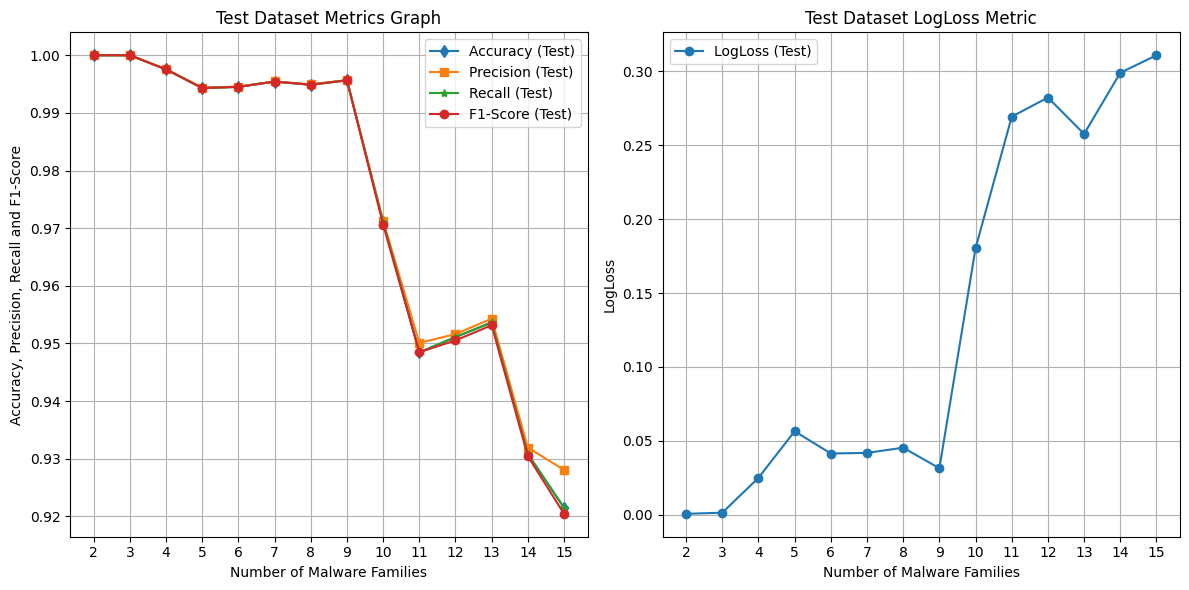

In [31]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = [str(i) for i in range(2, len(test_acc_list_all) + 2)]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
